# Dose of Reality
### Ingredient overlap and Tolerable Upper Intake Level exceedance in U.S. dietary supplement use, 1999–2023

**Didem Arslan** · [GitHub](https://github.com/didemmrsln/dose-of-reality) · Data: NHANES (CDC) + IOM/NAS Dietary Reference Intakes

---

## The question

If you take a multivitamin *and* a separate vitamin D capsule *and* a magnesium tablet, you are taking
vitamin D three times. Nothing on any of those labels tells you that. So: **how often does that happen,
and how often does it push someone past the Tolerable Upper Intake Level (UL) — the daily ceiling above
which intake is no longer considered safe?**

This project answers that at population scale, using 24 years of CDC survey data.

## Headline findings

| | |
|---|---|
| **39.8%** | of supplement users take the same vitamin or mineral from **two or more different products** *(2021–2023, survey-weighted)* |
| **33.3%** | exceed the UL for at least one ingredient *(2021–2023, survey-weighted)* |
| **64.2%** | of all UL exceedance is **overlap-driven** rather than caused by a single product — significantly more than a 50/50 split *(t = 21.4, p < 0.0001, 24-year sample)* |
| **+6.2 pts** | vitamin D exceedance in 2021–2023 above what the 1999–2020 trend predicted; zinc **+5.5 pts** from a two-decade flat line |
| **−20.9 pts** | overall supplement use in 2021–2023 below the pre-pandemic trend forecast |

**The finding that changes the advice:** "overlap" and "exceedance" are *not* the same risk, and the mix
differs by ingredient. Vitamin D exceedance is almost entirely driven by people stacking multiple products.
Iron exceedance is driven by the dose printed on a *single* label. A public-health message that only says
"watch out for taking too many supplements" would be right about vitamin D and wrong about iron.

## What this notebook demonstrates

- **ELT on real, messy public data** — 30 raw SAS transport files across 10 survey cycles, loaded to BigQuery, modelled in dbt (staging → intermediate → marts)
- **Reading the documentation instead of guessing** — a product-ID system change in 2017 that silently returns 0% join match, solved via an official crosswalk column
- **Survey methodology done properly** — NHANES complex sampling weights, the official multi-cycle combining rule, and design-based significance tests (not naive chi-square)
- **Reporting failures as findings** — a 4× duplication bug caught by cross-validating two independent implementations, and a hypothesis that the data could not support

**Scope boundaries.** This is a descriptive population-level study. It does not model drug–supplement
interactions, does not produce individual dosing advice, and does not use paid clinical databases.
Nothing here is medical advice.

## Contents

**Part I — Building the dataset**
1. [Data sources and how to reproduce this](#part1)
2. [Loading the NHANES files](#loading)
3. [Decoding the NHANES codebook](#codebook)
4. [The join chain: person → product → ingredient](#join)

**Part II — The core method (2021–2023)**
5. [Finding 1: how common is ingredient overlap?](#overlap)
6. [Overlap is not exceedance — and why that distinction matters](#not-the-same)
7. [The UL reference table](#ul-table)
8. [Pipeline architecture: BigQuery + dbt](#pipeline)
9. [Data quality: the 4× duplication bug](#dupes)
10. [Finding 2: UL exceedance and the 2×2 table](#exceedance)
11. [Which ingredients actually matter](#scope)

**Part III — Extending to 24 years**
12. [The product-ID discontinuity](#id-break)
13. [Survey weighting: getting it right](#weights)
14. [Trend: overall supplement use](#trend-usage)
15. [Trend: ingredient overlap](#trend-overlap)
16. [Trend: UL exceedance](#trend-ul)
17. [Where exceedance comes from](#source)

**Part IV — Who is affected**
18. [Sex](#sex) · 19. [Age](#age) · 20. [Iron and vitamin D: a targeted deep dive](#iron-deep) · 21. [Race and ethnicity](#ethnicity)

**Part V — Testing and quantifying**
22. [Design-based significance testing](#stats)
23. [A test that failed, and why that is worth showing](#failed-test)
24. [Counterfactual: sizing the pandemic effect](#counterfactual)

**Part VI — Closing**
25. [How the scope evolved](#phases) · 26. [Limitations](#limitations) · 27. [What I would do next](#next)

<a id="part1"></a>
# Part I — Building the dataset

## 1. Data sources and how to reproduce this

### Sources

| Source | What it provides | Files |
|---|---|---|
| **NHANES Dietary Supplement Use** (CDC) | 30-day supplement use, one row per person per product | `DSQIDS` / `DSQTOT` (or `DSQ1`/`DSQ2` in early cycles), 10 cycles |
| **NHANES Demographics** (CDC) | Age, sex, race/ethnicity, survey weights, strata, PSU | `DEMO`, 10 cycles |
| **NHANES Dietary Supplement Database** (CDC) | Product reference, ingredient composition, blend components | `DSPI`, `DSII`, `DSBI` (shared across all cycles) |
| **IOM / NAS Dietary Reference Intakes** | Tolerable Upper Intake Levels | Hand-built reference table, sourced below |

All CDC files are public and free: <https://wwwn.cdc.gov/nchs/nhanes/>
UL values: [DRI: Applications in Dietary Assessment (2000)](https://www.ncbi.nlm.nih.gov/books/NBK222881/) and
[DRI: Guiding Principles for Nutrition Labeling and Fortification (2003), Tables C-6 and C-7](https://www.ncbi.nlm.nih.gov/books/NBK208874/).

### Coverage

Ten NHANES cycle blocks, 1999 to August 2023:

`1999–2002` · `2003–2004` · `2005–2006` · `2007–2008` · `2009–2010` · `2011–2012` · `2013–2014` · `2015–2016` · `2017–2020` · `2021–2023`

1999–2000 and 2001–2002 are analysed as one block because CDC publishes a dedicated four-year weight
(`WTINT4YR`) for exactly that combination. 2017–2020 is CDC's non-standard 3.2-year "pre-pandemic" block.

### Stack

**BigQuery** (warehouse) · **dbt** (transformation) · **Python** — pandas, matplotlib, `svy` (design-based survey statistics) · **Looker Studio** (dashboard)

### Running this notebook

```bash
pip install pandas matplotlib google-cloud-bigquery db-dtypes svy polars
```

1. Download the NHANES `.xpt` files listed above into a folder (`base_path` in the next cell).
2. Load them to BigQuery as `nhanes_raw.*` — see [§8](#pipeline).
3. `dbt run` to build `nhanes_dbt.*`.
4. Run this notebook top to bottom. Sections 1–7 run on pandas alone; from §11 onward, cells query BigQuery.

Replace `dose-of-reality-506713` with your own GCP project id.

<a id="loading"></a>
## 2. Loading the NHANES files

NHANES ships as `.xpt` (SAS transport). `pandas.read_sas` reads it directly. Seven files for the
2021–2023 cycle: person-level supplement use, per-person totals, demographics, and the three shared
product/ingredient reference tables.

In [ ]:
# Environment setup - run once per session.
#
# In Colab this mounts Drive (where the NHANES .xpt files live) and authenticates
# BigQuery, which every cell from Section 11 onward needs.
# Running locally instead: install the packages below and configure Application
# Default Credentials with `gcloud auth application-default login`.
#
#   pip install pandas matplotlib google-cloud-bigquery db-dtypes svy polars

try:
    from google.colab import drive, auth
    drive.mount('/content/drive')
    auth.authenticate_user()
    print("Colab environment ready.")
except ImportError:
    print("Not running in Colab.")
    print("Point `base_path` (next cell) at your .xpt files and make sure")
    print("Application Default Credentials are configured for BigQuery.")


In [ ]:
# Read the raw NHANES files
import pandas as pd

# Folder holding the downloaded NHANES .xpt files
base_path = '/content/drive/MyDrive/Dose of Reality - Supplement Project/nhanes_2021_2023/'

# Read every file
df_dsqids = pd.read_sas(base_path + 'DSQIDS_L.xpt', format='xport')
df_dsqtot = pd.read_sas(base_path + 'DSQTOT_L.xpt', format='xport')
df_demo   = pd.read_sas(base_path + 'DEMO_L.xpt',   format='xport')
df_dspi   = pd.read_sas(base_path + 'DSPI.xpt',     format='xport')
df_dsii   = pd.read_sas(base_path + 'DSII.xpt',     format='xport')
df_dsbi   = pd.read_sas(base_path + 'DSBI.xpt',     format='xport')
df_food   = pd.read_sas(base_path + 'DRXFCD_L.xpt', format='xport')

# Quick check: shape of each file
print("DSQIDS_L:", df_dsqids.shape)
print("DSQTOT_L:", df_dsqtot.shape)
print("DEMO_L:  ", df_demo.shape)
print("DSPI:    ", df_dspi.shape)
print("DSII:    ", df_dsii.shape)
print("DSBI:    ", df_dsbi.shape)
print("DRXFCD_L:", df_food.shape)

DSQIDS_L: (11375, 45)
DSQTOT_L: (8860, 40)
DEMO_L:   (11933, 27)
DSPI:     (20235, 18)
DSII:     (188552, 10)
DSBI:     (37061, 6)
DRXFCD_L: (5432, 3)


In [ ]:
# Inspect the columns of each file
print("DSQIDS_L columns:", list(df_dsqids.columns))
print("\nDSQTOT_L columns:", list(df_dsqtot.columns))
print("\nDEMO_L columns:", list(df_demo.columns))
print("\nDSPI columns:", list(df_dspi.columns))
print("\nDSII columns:", list(df_dsii.columns))
print("\nDSBI columns:", list(df_dsbi.columns))
print("\nDRXFCD_L columns:", list(df_food.columns))

DSQIDS_L sütunları: ['SEQN', 'WTDRD1', 'DSDPID', 'DSDSUPP', 'DSDANTA', 'DSD070', 'DSDMTCH', 'DSD103', 'DSD122Q', 'DSD122U', 'DSDACTSS', 'DSQIKCAL', 'DSQIPROT', 'DSQICARB', 'DSQISUGR', 'DSQIFIBE', 'DSQITFAT', 'DSQISFAT', 'DSQIMFAT', 'DSQIPFAT', 'DSQICHOL', 'DSQILYCO', 'DSQILZ', 'DSQIVB1', 'DSQIVB2', 'DSQINIAC', 'DSQIVB6', 'DSQIFA', 'DSQIFDFE', 'DSQICHL', 'DSQIVB12', 'DSQIVC', 'DSQIVK', 'DSQIVD', 'DSQICALC', 'DSQIPHOS', 'DSQIMAGN', 'DSQIIRON', 'DSQIZINC', 'DSQICOPP', 'DSQISODI', 'DSQIPOTA', 'DSQISELE', 'DSQICAFF', 'DSQIIODI']

DSQTOT_L sütunları: ['SEQN', 'WTDRD1', 'DSDCOUNT', 'DSDANCNT', 'DSD010', 'DSD010AN', 'DSQTKCAL', 'DSQTPROT', 'DSQTCARB', 'DSQTSUGR', 'DSQTFIBE', 'DSQTTFAT', 'DSQTSFAT', 'DSQTMFAT', 'DSQTPFAT', 'DSQTCHOL', 'DSQTLYCO', 'DSQTLZ', 'DSQTVB1', 'DSQTVB2', 'DSQTNIAC', 'DSQTVB6', 'DSQTFA', 'DSQTFDFE', 'DSQTCHL', 'DSQTVB12', 'DSQTVC', 'DSQTVK', 'DSQTVD', 'DSQTCALC', 'DSQTPHOS', 'DSQTMAGN', 'DSQTIRON', 'DSQTZINC', 'DSQTCOPP', 'DSQTSODI', 'DSQTPOTA', 'DSQTSELE', 'DSQTCAFF', 'D

### One quirk worth knowing about

`read_sas` returns every character column as **byte strings** (`b'VITAMIN D'`, padded with trailing
spaces), not Python strings. Skip this step and `nunique()` silently over-counts, because
`b'VITAMIN D'` and `b'VITAMIN D '` are different objects. Decode and strip everything up front.

In [ ]:
# read_sas returns character columns as byte strings - decode and strip them all
def decode_bytes(df):
    for col in df.select_dtypes(include=['object']).columns:
        try:
            df[col] = df[col].str.decode('utf-8').str.strip()
        except (AttributeError, UnicodeDecodeError):
            pass
    return df

df_dsqids = decode_bytes(df_dsqids)
df_dsqtot = decode_bytes(df_dsqtot)
df_demo   = decode_bytes(df_demo)
df_dspi   = decode_bytes(df_dspi)
df_dsii   = decode_bytes(df_dsii)
df_dsbi   = decode_bytes(df_dsbi)

In [ ]:
print("Distinct ingredients by name:", df_dsii['DSDINGR'].nunique())
print("Distinct ingredients by id:  ", df_dsii['DSDINGID'].nunique())
print("\n20 most frequent ingredients:")
print(df_dsii['DSDINGR'].value_counts().head(20))

Farklı ingredient sayısı (isim bazlı): 10662
Farklı ingredient sayısı (ID bazlı): 8056

En sık geçen 20 ingredient:
DSDINGR
VITAMIN C             6712
CALCIUM               6000
VITAMIN D             5858
VITAMIN B-6           5787
VITAMIN B-12          5570
VITAMIN E             5481
CALORIES              5278
FOLIC ACID            5209
NIACIN                5090
VITAMIN A             5022
ZINC                  5010
RIBOFLAVIN            4817
THIAMIN               4769
PANTOTHENIC ACID      4489
MAGNESIUM             4441
BIOTIN                4269
TOTAL CARBOHYDRATE    3793
COPPER                3408
MANGANESE             3301
IODINE                3108
Name: count, dtype: int64


### What each table looks like

A quick look at all seven tables before joining anything — row grain matters here. `DEMO` is one row per
person, `DSQIDS` is one row per person *per product*, and `DSII` is one row per product *per ingredient*.

In [ ]:
# A first look at every table
import pandas as pd
pd.set_option('display.max_columns', None)  # show every column

print("=== DEMO_L - demographics, one row per person ===")
display(df_demo.head())

print("\n=== DSQIDS_L - one row per person per product ===")
display(df_dsqids.head())

print("\n=== DSQTOT_L - one row per person, totals ===")
display(df_dsqtot.head())

print("\n=== DSPI - product reference ===")
display(df_dspi.head())

print("\n=== DSII - product to ingredient ===")
display(df_dsii.head())

print("\n=== DSBI - blend sub-components ===")
display(df_dsbi.head())

print("\n=== DRXFCD_L - food codes (supporting, not in the main chain) ===")
display(df_food.head())

=== DEMO_L (kişi demografik bilgisi) ===


,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,RIDEXAGM,DMQMILIZ,DMDBORN4,DMDYRUSR,DMDEDUC2,DMDMARTZ,RIDEXPRG,DMDHHSIZ,DMDHRGND,DMDHRAGZ,DMDHREDZ,DMDHRMAZ,DMDHSEDZ,WTINT2YR,WTMEC2YR,SDMVSTRA,SDMVPSU,INDFMPIR
0,130378.0,12.0,2.0,1.0,43.0,NaN,5.0,6.0,2.0,NaN,2.0,2.0,6.0,5.0,1.0,NaN,4.0,NaN,NaN,NaN,NaN,NaN,50055.450807,54374.463898,173.0,2.0,5.00
1,130379.0,12.0,2.0,1.0,66.0,NaN,3.0,3.0,2.0,NaN,2.0,1.0,NaN,5.0,1.0,NaN,2.0,NaN,NaN,NaN,NaN,NaN,29087.450605,34084.721548,173.0,2.0,5.00
2,130380.0,12.0,2.0,2.0,44.0,NaN,2.0,2.0,1.0,NaN,2.0,2.0,6.0,3.0,1.0,2.0,7.0,NaN,NaN,NaN,NaN,NaN,80062.674301,81196.277992,174.0,1.0,1.41
3,130381.0,12.0,2.0,2.0,5.0,NaN,5.0,7.0,1.0,71.0,NaN,1.0,NaN,NaN,NaN,NaN,2.0,2.0,2.0,2.0,3.0,NaN,38807.268902,55698.607106,182.0,2.0,1.53
4,130382.0,12.0,2.0,1.0,2.0,NaN,3.0,3.0,2.0,34.0,NaN,1.0,NaN,NaN,NaN,NaN,4.0,2.0,2.0,3.0,1.0,2.0,30607.519774,36434.146346,182.0,2.0,3.60



=== DSQIDS_L (kişi bazlı, her supplement için ayrı satır) ===


,SEQN,WTDRD1,DSDPID,DSDSUPP,DSDANTA,DSD070,DSDMTCH,DSD103,DSD122Q,DSD122U,DSDACTSS,DSQIKCAL,DSQIPROT,DSQICARB,DSQISUGR,DSQIFIBE,DSQITFAT,DSQISFAT,DSQIMFAT,DSQIPFAT,DSQICHOL,DSQILYCO,DSQILZ,DSQIVB1,DSQIVB2,DSQINIAC,DSQIVB6,DSQIFA,DSQIFDFE,DSQICHL,DSQIVB12,DSQIVC,DSQIVK,DSQIVD,DSQICALC,DSQIPHOS,DSQIMAGN,DSQIIRON,DSQIZINC,DSQICOPP,DSQISODI,DSQIPOTA,DSQISELE,DSQICAFF,DSQIIODI
0,130380.0,84728.261560,20969.0,DEFAULT FIBER POWDER,5.397605e-79,2.0,5.0,1.0,1.0,12.0,1.0,20.0,NaN,7.0,4.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.4,NaN,NaN,5.0,30.0,NaN,NaN,NaN
1,130381.0,61737.133446,20951.0,DEFAULT CHILDREN'S MULTIVITAMIN / MULTIMINERAL,5.397605e-79,1.0,5.0,24.0,1.0,1.0,1.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.2,1.3,12.0,1.7,400.0,680.0,NaN,2.4,90.0,60.0,20.0,140.0,NaN,NaN,10.0,5.00,0.44,15.0,NaN,NaN,NaN,150.0
2,130381.0,61737.133446,25343.0,ZARBEE'S CHILDREN'S DAILY IMMUNE SUPPORT WITH ...,5.397605e-79,1.0,2.0,24.0,1.0,20.0,0.5,13.0,NaN,3.0,2.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,62.5,NaN,2.5,NaN,NaN,NaN,NaN,0.75,NaN,NaN,NaN,NaN,NaN,NaN
3,130382.0,75846.746917,25129.0,L'IL CRITTERS GUMMY VITES DAILY MULTIVITAMIN P...,5.397605e-79,1.0,1.0,30.0,1.0,20.0,0.5,8.0,NaN,1.5,1.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50.0,NaN,NaN,NaN,0.9,100.0,170.0,NaN,1.2,10.0,NaN,10.0,NaN,NaN,NaN,NaN,1.40,NaN,NaN,NaN,NaN,NaN,21.0
4,130386.0,82013.365563,21225.0,NATURE MADE D3 2000 IU (50 MCG),5.397605e-79,1.0,1.0,20.0,2.0,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,210.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



=== DSQTOT_L (kişi bazlı toplam özet) ===


...

,DSDPID,DSDSUPP,DSDIID,DSDINGR,DSDOPER,DSDQTY,DSDUNIT,DSDCAT,DSDBLFLG,DSDINGID
0,1.0,b'MYADEC HIGH POTENCY MULTIVITAMIN-MULTIMINERA...,35.0,BIOTIN,=,30.0,4.0,1.0,2.0,10000042
1,1.0,b'MYADEC HIGH POTENCY MULTIVITAMIN-MULTIMINERA...,45.0,BORON,=,150.0,4.0,2.0,2.0,10000052
2,1.0,b'MYADEC HIGH POTENCY MULTIVITAMIN-MULTIMINERA...,63.0,CALCIUM,=,162.0,1.0,2.0,2.0,10000070
3,1.0,b'MYADEC HIGH POTENCY MULTIVITAMIN-MULTIMINERA...,84.0,CHROMIUM,=,25.0,4.0,2.0,2.0,10000093
4,1.0,b'MYADEC HIGH POTENCY MULTIVITAMIN-MULTIMINERA...,94.0,COPPER,=,2.0,1.0,2.0,2.0,10000103



=== DSBI (ingredient-blend alt bileşen eşleme) ===


,DSDIID,DSDINGR,DSDBID,DSDBCNAM,DSDBCCAT,DSDBCID
0,88.0,ALIVE! CITRUS BIOFLAVONOID COMPLEX,1436.0,NARIRUTIN,4.0,10001567
1,88.0,ALIVE! CITRUS BIOFLAVONOID COMPLEX,1437.0,ERIOCITRIN,4.0,10001568
2,88.0,ALIVE! CITRUS BIOFLAVONOID COMPLEX,1598.0,FLAVONOLS,4.0,10001738
3,88.0,ALIVE! CITRUS BIOFLAVONOID COMPLEX,2188.0,GRAPE,3.0,10002355
4,88.0,ALIVE! CITRUS BIOFLAVONOID COMPLEX,2189.0,GRAPEFRUIT,3.0,10002356



=== DRXFCD_L (food codes — opsiyonel/destekleyici) ===


,DRXFDCD,DRXFCSD,DRXFCLD
0,11000000.0,"b'MILK, HUMAN'","b'Milk, human'"
1,11100000.0,"b'MILK, NFS'","b'Milk, NFS'"
2,11111000.0,"b'MILK, WHOLE'","b'Milk, whole'"
3,11112110.0,"b'MILK, REDUCED FAT (2%)'","b'Milk, reduced fat (2%)'"
4,11112210.0,"b'MILK, LOW FAT (1%)'","b'Milk, low fat (1%)'"


<a id="codebook"></a>
## 3. Decoding the NHANES codebook

NHANES stores categorical variables as bare numeric codes. The meanings live in per-file HTML codebooks
on the CDC site (e.g. <https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/1999/DataFiles/DSPI.htm>). The
mappings below are transcribed from those official pages.

### Demographics (`DEMO`)

**`RIAGENDR` — Sex:** 1 = Male · 2 = Female

**`RIDRETH3` — Race/ethnicity (2011 onward, with the Asian oversample broken out)**

| Code | Meaning |
|---|---|
| 1 | Mexican American |
| 2 | Other Hispanic |
| 3 | Non-Hispanic White |
| 4 | Non-Hispanic Black |
| 6 | Non-Hispanic Asian |
| 7 | Other / Multiracial |

**`RIDRETH1` — Race/ethnicity (comparable back to 1999 — used for all trend analysis)**

| Code | Meaning |
|---|---|
| 1 | Mexican American |
| 2 | Other Hispanic |
| 3 | Non-Hispanic White |
| 4 | Non-Hispanic Black |
| 5 | Other Race (incl. Multiracial) |

> **Why `RIDRETH1` and not `RIDRETH3`:** `RIDRETH3` reports Non-Hispanic Asian as its own category, but
> only exists from 2011. `RIDRETH1` folds that group into "Other Race" and is available for every cycle.
> A 24-year trend needs one consistent definition, so `RIDRETH1` wins — at the cost of not being able to
> report on Asian Americans separately. That is a real limitation, revisited in [§26](#limitations).

### Product reference (`DSPI`)

**`DSDPRDT` — Product type:** 1 = Regular (identified product) · 2 = Generic · 3 = Default (label info incomplete)

**`DSDTYPE` — Supplement type:** 1 = Infant/Pediatric · 2 = Prenatal · 3 = Mature (55+) · 4 = Standard

**`DSDSRCE` — Information source:** 1 = Manufacturer · 2 = Distributor · 4 = Inferred from name · 5 = PDR · 7 = Product catalog · 8 = Internet listing · 9 = Label/carton · 10 = Same manufacturer · 11 = DSLD

### Ingredient reference (`DSII`)

**`DSDCAT` — Ingredient category.** This is the single most important filter in the project.

| Code | Meaning | Rows |
|---|---|---|
| 1 | Vitamin | 66,877 |
| 2 | Mineral | 43,731 |
| 3 | Botanical | 14,174 |
| 4 | Other | 54,053 |
| 5 | Amino acid | 4,042 |
| · | Missing | 5,695 |

> **UL analysis uses only `DSDCAT` 1 and 2 (vitamins and minerals).** "Other" is largely macronutrient and
> calorie rows, not something a UL applies to. Botanicals and amino acids are excluded for a substantive
> reason, not a convenience one: no standardised, population-applicable UL system exists for them
> (botanicals are not regulated as drugs; IOM/EFSA have not set amino-acid ULs). Excluding them is a
> documented scope decision, not missing data.

**`DSDBLFLG` — Blend flag:** 0 = not a blend · 1 = blend, sub-components live in `DSBI`

### Unit conversion (`DSPI.htm`, Appendix 2)

Some vitamins are labelled in International Units rather than mass, so quantities must be standardised
before any comparison against a UL:

| Ingredient | Conversion |
|---|---|
| Vitamin A | 1 IU = 0.3 mcg RAE |
| Vitamin D | 40 IU = 1 mcg |
| Vitamin E | 1 IU = 0.67 mg |

Units that are not absolute masses at all — `% DV`, kcal, mL, DU, HUT, LU — **cannot** be standardised.
Those rows are flagged and held out of the UL comparison rather than silently coerced. That flag is
carried through the whole pipeline as `unit_convertible`.

In [ ]:
# Decode NHANES numeric category codes into readable labels (per the official CDC codebooks)

# DSPI - product type
dsdprdt_map = {1: 'Regular', 2: 'Generic', 3: 'Default'}
df_dspi['DSDPRDT_label'] = df_dspi['DSDPRDT'].map(dsdprdt_map)

# DSPI - information source
dsdsrce_map = {
    1: 'Manufacturer', 2: 'Distributor', 4: 'Inferred from name',
    5: 'PDR', 7: 'Product Catalog', 8: 'Internet Listing',
    9: 'Label/Carton', 10: 'Same Manufacturer', 11: 'DSLD'
}
df_dspi['DSDSRCE_label'] = df_dspi['DSDSRCE'].map(dsdsrce_map)

# DSPI - supplement type
dsdtype_map = {1: 'Infant/Pediatric', 2: 'Prenatal', 3: 'Mature', 4: 'Standard'}
df_dspi['DSDTYPE_label'] = df_dspi['DSDTYPE'].map(dsdtype_map)

# DEMO_L - sex
riagendr_map = {1: 'Male', 2: 'Female'}
df_demo['RIAGENDR_label'] = df_demo['RIAGENDR'].map(riagendr_map)

# DEMO_L - race/ethnicity (RIDRETH3: 2011 onward, Asian oversample broken out)
ridreth3_map = {
    1: 'Mexican American', 2: 'Other Hispanic', 3: 'Non-Hispanic White',
    4: 'Non-Hispanic Black', 6: 'Non-Hispanic Asian', 7: 'Other/Multiracial'
}
df_demo['RIDRETH3_label'] = df_demo['RIDRETH3'].map(ridreth3_map)

# DEMO_L - race/ethnicity (RIDRETH1: comparable back to 1999 - used for all trend analysis)
ridreth1_map = {
    1: 'Mexican American', 2: 'Other Hispanic', 3: 'Non-Hispanic White',
    4: 'Non-Hispanic Black', 5: 'Other Race (incl. Multiracial)'
}
df_demo['RIDRETH1_label'] = df_demo['RIDRETH1'].map(ridreth1_map)

# Quick check
print("=== DSPI - product type ===")
print(df_dspi['DSDPRDT_label'].value_counts())

print("\n=== DSPI - supplement type ===")
print(df_dspi['DSDTYPE_label'].value_counts())

print("\n=== DEMO_L - sex ===")
print(df_demo['RIAGENDR_label'].value_counts())

print("\n=== DEMO_L - race/ethnicity (RIDRETH1) ===")
print(df_demo['RIDRETH1_label'].value_counts())

=== DSPI - Ürün Tipi Dağılımı ===
DSDPRDT_label
Regular    17885
Generic     1513
Default      837
Name: count, dtype: int64

=== DSPI - Supplement Tipi Dağılımı ===
DSDTYPE_label
Standard            18147
Infant/Pediatric     1172
Mature                509
Prenatal              407
Name: count, dtype: int64

=== DEMO_L - Cinsiyet Dağılımı ===
RIAGENDR_label
Female    6358
Male      5575
Name: count, dtype: int64

=== DEMO_L - Etnik Köken Dağılımı (RIDRETH1) ===
RIDRETH1_label
Non-Hispanic White                6217
Other Race (incl. Multiracial)    1629
Non-Hispanic Black                1597
Other Hispanic                    1373
Mexican American                  1117
Name: count, dtype: int64


In [ ]:
# Decode the ingredient category
dsdcat_map = {1: 'Vitamin', 2: 'Mineral', 3: 'Botanical', 4: 'Other', 5: 'Amino Acid'}
df_dsii['DSDCAT_label'] = df_dsii['DSDCAT'].map(dsdcat_map)

print(df_dsii['DSDCAT_label'].value_counts())

# Subset used for the UL analysis: vitamins and minerals only
df_dsii_ul = df_dsii[df_dsii['DSDCAT'].isin([1, 2])].copy()
print(f"\nRows available for the UL analysis: {len(df_dsii_ul)}")

DSDCAT_label
Vitamin       66856
Other         54055
Mineral       43730
Botanical     14174
Amino Acid     4042
Name: count, dtype: int64

UL analizi için kullanılabilir satır sayısı: 110586


<a id="join"></a>
## 4. The join chain: person → product → ingredient

Four tables have to line up before any of this is answerable:

```
DEMO_L          one row per person          ─┐
                                             ├─ SEQN ─→  who is this person?
DSQIDS_L        one row per person·product  ─┘

DSQIDS_L        one row per person·product  ─┐
                                             ├─ DSDPID ─→ what is in that product?
DSPI → DSII     one row per product·ingredient ┘
```

The result has one row per **person × product × ingredient**, filtered to vitamins and minerals. That
grain is what makes the overlap question answerable: group by person and ingredient, count how many
*distinct products* contributed it.

In [ ]:
# 1. Person + the products they take
df_join = df_dsqids.merge(df_demo, on='SEQN', how='left')

# 2. Attach product detail
df_join = df_join.merge(df_dspi, on='DSDPID', how='left', suffixes=('', '_product'))

# 3. Attach the product's ingredients (vitamins + minerals only, DSDCAT filtered)
df_dsii_ul = df_dsii[df_dsii['DSDCAT'].isin([1, 2])].copy()
df_join_full = df_join.merge(df_dsii_ul, on='DSDPID', how='left', suffixes=('', '_ingredient'))

print("Shape after the join:", df_join_full.shape)
print("\nSample rows:")
display(df_join_full[['SEQN', 'RIAGENDR_label', 'RIDAGEYR', 'DSDSUPP', 'DSDINGR', 'DSDQTY', 'DSDUNIT']].head(10))

Join sonrası boyut: (54744, 104)

Örnek satırlar:


,SEQN,RIAGENDR_label,RIDAGEYR,DSDSUPP,DSDINGR,DSDQTY,DSDUNIT
0,130380.0,Female,44.0,DEFAULT FIBER POWDER,IRON,0.40,1.0
1,130381.0,Female,5.0,DEFAULT CHILDREN'S MULTIVITAMIN / MULTIMINERAL,BIOTIN,30.00,4.0
2,130381.0,Female,5.0,DEFAULT CHILDREN'S MULTIVITAMIN / MULTIMINERAL,CALCIUM,140.00,1.0
3,130381.0,Female,5.0,DEFAULT CHILDREN'S MULTIVITAMIN / MULTIMINERAL,COPPER,0.44,1.0
4,130381.0,Female,5.0,DEFAULT CHILDREN'S MULTIVITAMIN / MULTIMINERAL,IODINE,150.00,4.0
5,130381.0,Female,5.0,DEFAULT CHILDREN'S MULTIVITAMIN / MULTIMINERAL,IRON,10.00,1.0
6,130381.0,Female,5.0,DEFAULT CHILDREN'S MULTIVITAMIN / MULTIMINERAL,PANTOTHENIC ACID,5.00,1.0
7,130381.0,Female,5.0,DEFAULT CHILDREN'S MULTIVITAMIN / MULTIMINERAL,VITAMIN A,400.00,4.0
8,130381.0,Female,5.0,DEFAULT CHILDREN'S MULTIVITAMIN / MULTIMINERAL,VITAMIN D,800.00,2.0
9,130381.0,Female,5.0,DEFAULT CHILDREN'S MULTIVITAMIN / MULTIMINERAL,VITAMIN E,7.50,1.0


<a id="part2"></a>
<a id="overlap"></a>
# Part II — The core method (2021–2023)

## 5. Finding 1: how common is ingredient overlap?

The mechanic is simple. For each `(person, ingredient)` pair, count the distinct products that person
takes containing that ingredient. More than one product = **overlap**.

In [ ]:
# Does a person (SEQN) get the same ingredient from more than one product?
overlap_check = df_join_full.groupby(['SEQN', 'DSDINGR'])['DSDPID'].nunique().reset_index()
overlap_check.columns = ['SEQN', 'DSDINGR', 'n_farkli_urun']

# Rows with overlap: same ingredient, 2+ distinct products
overlapping = overlap_check[overlap_check['n_farkli_urun'] > 1]

print(f"Person-ingredient combinations:      {len(overlap_check)}")
print(f"...of which overlapping (2+ products): {len(overlapping)}")
print(f"\nMost frequently overlapped ingredients:")
print(overlapping['DSDINGR'].value_counts().head(10))

Toplam kişi-ingredient kombinasyonu: 45198
Çakışma olan (2+ farklı üründen aynı ingredient): 5881

En sık çakışan ingredient'lar:
DSDINGR
VITAMIN D       966
CALCIUM         775
VITAMIN C       624
ZINC            381
VITAMIN B-12    371
MAGNESIUM       311
VITAMIN E       269
VITAMIN B-6     261
BIOTIN          252
FOLIC ACID      227
Name: count, dtype: int64


In [ ]:
# What share of U.S. supplement users has at least one overlapping ingredient?
people_with_overlap = overlapping['SEQN'].nunique()
people_in_scope = df_join_full['SEQN'].nunique()

print(f"People with at least one overlap: {people_with_overlap}")
print(f"People in scope:                  {people_in_scope}")
print(f"Share:                            {people_with_overlap/people_in_scope*100:.1f}%")

En az bir çakışma yaşayan kişi sayısı: 1559
Toplam kişi sayısı (bu analize dahil): 4017
Oran: 38.8%


### Result

- **45,198** person–ingredient combinations
- **5,881** of them (≈13%) come from two or more different products
- **1,559 of 3,835 people (40.7%)** have at least one overlapping ingredient

The most frequently overlapped ingredients are exactly the ones you would expect from a shelf of
supplements: vitamin D, calcium, vitamin C, zinc, vitamin B-12, magnesium, vitamin E, vitamin B-6,
biotin, folic acid.

> **Cross-validation note.** These four numbers were reproduced independently in the dbt/BigQuery model
> `mart_ingredient_overlap` — pandas and SQL agree exactly. The first attempt disagreed: pandas said
> 4,017 people (38.8%), dbt said 3,835. The cause was that pandas `groupby()` *silently* drops rows with
> `NaN` group keys, so people whose products matched no ingredient were being excluded implicitly. dbt
> did the same thing explicitly, via `where ingredient_name is not null`. Once that was understood, both
> methods were shown to implement the same logic, and 3,835 is the correct, consistent denominator.
> This is the first of two bugs in the project that only surfaced because two independent
> implementations were compared.

<a id="not-the-same"></a>
## 6. Overlap is not exceedance — and why that distinction matters

**40.7% is the rate of ingredient overlap, not the rate of exceeding a safe limit.** These are different
claims and conflating them would overstate the result:

- **Overlap** — a person gets the same ingredient from more than one product (e.g. a multivitamin *and* a standalone vitamin C tablet).
- **Exceedance** — the *combined amount* crosses that ingredient's Tolerable Upper Intake Level.

Overlap does not imply exceedance. Vitamin C has a generous UL (2,000 mg/day), so multiple sources can
stack without crossing it. The opposite also holds: some ingredients have tight ULs, and a *single*
overlap — or a single high-dose product — is enough.

So 40.7% establishes the size of the potentially-at-risk group. Turning it into an actual exceedance
figure requires four more steps:

1. Obtain a UL reference table from an authoritative source
2. Map a UL to every ingredient
3. Compute each person's total intake per ingredient, with units standardised
4. Compare total intake against the UL

That is what the rest of Part II does.

<a id="ul-table"></a>
## 7. The UL reference table

**Sources:** IOM/NAS, *DRI: Applications in Dietary Assessment* (2000) — [NBK222881](https://www.ncbi.nlm.nih.gov/books/NBK222881/); IOM/NAS, *DRI: Guiding Principles for Nutrition Labeling and Fortification* (2003), Tables C-6 (vitamins) and C-7 (elements) — [NBK208874](https://www.ncbi.nlm.nih.gov/books/NBK208874/).

### Adult ULs, ages 19–70

| Ingredient | UL | Scope note |
|---|---|---|
| Vitamin A | 3,000 mcg/day | Preformed (retinol) only; excludes beta-carotene |
| Vitamin C | 2,000 mg/day | Total intake |
| Vitamin D | 50 mcg/day | Total intake |
| Vitamin E | 1,000 mg/day | **Supplement / fortified sources only** |
| Vitamin K | **ND** | No upper limit set |
| Thiamin (B1) | **ND** | No upper limit set |
| Riboflavin (B2) | **ND** | No upper limit set |
| Niacin | 35 mg/day | **Supplement / fortified sources only** |
| Vitamin B6 | 100 mg/day | Total intake |
| Folate / Folic acid | 1,000 mcg/day | **Supplement / fortified sources only** |
| Vitamin B-12 | **ND** | No upper limit set |
| Pantothenic acid | **ND** | No upper limit set |
| Biotin | **ND** | No upper limit set |
| Choline | 3,500 mg/day | Total intake |
| Calcium | 2,500 mg/day | Total intake |
| Chromium | **ND** | No upper limit set |
| Copper | 10,000 mcg/day | Total intake |
| Fluoride | 10 mg/day | Total intake |
| Iodine | 1,100 mcg/day | Total intake |
| Iron | 45 mg/day | Total intake |
| Magnesium | 350 mg/day | **Supplement sources only** |
| Manganese | 11 mg/day | Total intake |
| Molybdenum | 2,000 mcg/day | Total intake |
| Phosphorus | 4,000 mg/day | Total intake |
| Selenium | 400 mcg/day | Total intake |
| Zinc | 40 mg/day | Total intake |
| Carotenoids (incl. beta-carotene) | **ND** | No upper limit set |

### Two things this table hides

**"ND" does not mean "safe."** It means *Not Determinable* — the source's own wording for "insufficient
evidence to set a ceiling." For vitamin B-12 and biotin the reasoning is explicit and substantive: IOM
found no adverse effects associated with high intake in healthy individuals (B-12 is water-soluble and
excreted; biotin shows no toxicity even at the 2,500–5,000 mcg doses sold commercially, 80–160× the
daily requirement). So excluding B-12 and biotin from the exceedance analysis is not a gap in the
data — it is the reference authority declining to set a limit. That is stated wherever those
ingredients appear.

**ULs vary by age.** The table above covers ages 19–70 only. Children, adolescents and adults 71+ have
different values. **This project applies the adult table to all ages**, which means exceedance is
*understated* for the 0–17 group, whose real ULs are lower. Age-specific ULs are the highest-value
improvement available to this project — see [§26](#limitations).

In [ ]:
# UL reference table (adults, ages 19-70)
# Source: IOM/NAS DRI Summary Tables (2000) - NBK222881
#         IOM/NAS DRI Nutrition Labeling Tables C-6/C-7 (2003) - NBK208874
# None = ND (Not Determinable - the source set no upper limit)

ul_reference = {
    'VITAMIN A': 3000,          # mcg (preformed/retinol only)
    'VITAMIN C': 2000,          # mg
    'VITAMIN D': 50,            # mcg
    'VITAMIN E': 1000,          # mg — sadece supplement/fortified
    'VITAMIN K': None,          # ND
    'THIAMIN': None,            # ND
    'RIBOFLAVIN': None,         # ND
    'NIACIN': 35,               # mg — sadece supplement/fortified
    'VITAMIN B-6': 100,         # mg
    'FOLIC ACID': 1000,         # mcg — sadece supplement/fortified
    'FOLATE': 1000,             # mcg — sadece supplement/fortified
    'VITAMIN B-12': None,       # ND
    'PANTOTHENIC ACID': None,   # ND
    'BIOTIN': None,             # ND
    'CHOLINE': 3500,            # mg
    'CALCIUM': 2500,            # mg
    'CHROMIUM': None,           # ND
    'COPPER': 10000,            # mcg (10 mg)
    'FLUORIDE': 10,             # mg
    'IODINE': 1100,             # mcg
    'IRON': 45,                 # mg
    'MAGNESIUM': 350,           # mg - supplement sources only
    'MANGANESE': 11,            # mg
    'MOLYBDENUM': 2000,         # mcg (2 mg)
    'PHOSPHORUS': 4000,         # mg
    'SELENIUM': 400,            # mcg
    'ZINC': 40,                 # mg
    'BETA CAROTENE': None,      # ND (carotenoid)
}

# Which ingredient rows have a UL defined?
df_dsii_ul['UL_deger'] = df_dsii_ul['DSDINGR'].map(ul_reference)

print("Rows with a UL defined:", df_dsii_ul['UL_deger'].notna().sum())
print("Rows whose ingredient name is not in the lookup:",
      df_dsii_ul[~df_dsii_ul['DSDINGR'].isin(ul_reference.keys())].shape[0])

# Ingredient names present in the data but absent from the lookup
# (mostly chemical-form variants such as "CALCIUM CITRATE")
eslesmeyen = df_dsii_ul[~df_dsii_ul['DSDINGR'].isin(ul_reference.keys())]['DSDINGR'].value_counts()
print("\nUnmatched ingredient names (first 30):")
print(eslesmeyen.head(30))

UL değeri tanımlı olan satır sayısı: 75484
Sözlükte eşleşmeyen (henüz kod bulunamayan) satır sayısı: 6058

Sözlükte olmayan ingredient isimleri (ilk 30):
DSDINGR
BORON                          1737
VANADIUM                       1158
SILICON                         746
NICKEL                          613
TIN                             414
CHOLINE BITARTRATE              345
SILICA                          316
ALUMINUM HYDROXIDE               99
CALCIUM CARBONATE                60
MAGNESIUM HYDROXIDE              57
MIXED TOCOPHEROLS                35
STRONTIUM                        28
TOCOTRIENOLS                     26
GAMMA-TOCOPHEROL                 23
LITHIUM                          20
ASCORBYL PALMITATE               18
VANADYL SULFATE                  18
SULFUR                           18
SILVER                           15
COBALT                           13
CORAL CALCIUM                    11
CALCIUM D-GLUCARATE              10
RIBOFLAVIN-5-PHOSPHATE           10
INOSITOL H

<a id="pipeline"></a>
## 8. Pipeline architecture: BigQuery + dbt

Everything up to here ran in pandas on a single cycle. That does not survive contact with ten cycles,
30 source files and schema drift across 24 years. From this point on the transformation logic lives in
**dbt on BigQuery**, and this notebook queries the resulting models.

All model SQL is version-controlled in [`dbt/models/`](https://github.com/didemmrsln/dose-of-reality/tree/main/dbt/models).
The code that generated it is not reproduced here — a notebook that writes `.sql` files as Python
strings and shells out to `dbt run` is a build script, not analysis. This section documents the
architecture instead.

### Lineage

```
  nhanes_raw  (BigQuery, one table per source file, loaded WRITE_TRUNCATE)
  ├── demo_1999_2000 … demo_l          (10 cycles)
  ├── dsqids_1999_2000 … dsqids_l      (10 cycles)
  ├── dsqtot_1999_2000 … dsqtot_l      (10 cycles)
  ├── dspi, dsii, dsbi                 (shared product/ingredient reference)
  └── ul_reference                     (IOM/NAS upper limits)
          │
          ▼
  staging/   one view per source table · rename to canonical names · decode categoricals · stamp `cycle`
  ├── stg_demo_*      → seqn, age_years, gender, ethnicity_v1/v3, interview_weight, survey_stratum, survey_psu
  ├── stg_dsqids_*    → seqn, product_id, product_name, days_used_30d
  ├── stg_dsqtot_*    → seqn, total_supplements_used
  ├── stg_dspi / stg_dsii / stg_dsbi   (stg_dsii filters DSDCAT in (1,2))
  └── stg_ul_reference
          │
          ▼
  intermediate/   union cycles · resolve the product-ID break · standardise units · attach ULs
  ├── int_demo_all_cycles                    10 cycles unioned + combining-cycles weight
  ├── int_dsqids_all_cycles                  10 cycles unioned + `dspi_product_id` crosswalk  ◀ §12
  ├── int_supplement_ingredients_all_cycles  person × product × ingredient, all cycles
  ├── int_ingredients_normalized_all_cycles  every quantity → mcg + `unit_convertible` flag
  └── int_ingredients_with_ul_all_cycles     + UL joined, also converted to mcg
          │
          ▼
  marts/   materialised tables, one per analytical question
  ├── mart_usage_trend_weighted              usage % and multi-use % by cycle
  ├── mart_ingredient_overlap[_trend][_weighted]
  ├── mart_ul_comparison[_trend][_weighted]
  ├── mart_ul_source_breakdown_trend         overlap-driven vs single-product exceedance
  └── mart_dashboard_usage / mart_dashboard_ingredient   (Looker Studio, carry `n_kisi` for small-cell transparency)
```

### Why the layers are split this way

**Staging is the only place a raw NHANES column name appears.** Every cycle names things slightly
differently — `DSDSUPID` vs `DSDPID` for product id, `WTINT2YR` vs `WTINTPRP` vs `WTINT4YR` for the
interview weight, `DSD103` missing entirely in 1999–2000, `DSDSUPP` missing entirely in 2007–2008.
Each of those quirks is absorbed by exactly one staging model and documented in a comment there. Nothing
downstream has to know about it.

**Intermediate is where cross-cycle logic lives**, because that is the only layer that can see all
cycles at once: the union, the product-ID crosswalk, the unit standardisation, the UL join.

**Marts are one table per question**, materialised, so the notebook and the dashboard read the same
numbers from the same place.

### Two models worth reading

Unit standardisation — note that non-mass units are flagged rather than coerced:

```sql
-- int_ingredients_normalized_all_cycles.sql
-- DSDUNIT (DSII codebook): 1=mg 2=IU 3=%DV 4=mcg 5=gm 6=mL 7=kcal 8=DU 9=HUT 10=LU
-- IU → mcg is INGREDIENT-SPECIFIC (DSPI.htm, Appendix 2)
case
    when unit_code = 1 then quantity * 1000                                        -- mg  → mcg
    when unit_code = 4 then quantity                                               -- mcg → mcg
    when unit_code = 5 then quantity * 1000000                                     -- g   → mcg
    when unit_code = 2 and ingredient_name = 'VITAMIN A' then quantity * 0.3
    when unit_code = 2 and ingredient_name = 'VITAMIN D' then quantity * 0.025
    when unit_code = 2 and ingredient_name = 'VITAMIN E' then quantity * 670
    else null   -- %DV, kcal, mL, DU, HUT, LU, or IU with no defined factor
end as quantity_mcg,

case
    when unit_code in (1, 4, 5) then true
    when unit_code = 2 and ingredient_name in ('VITAMIN A','VITAMIN D','VITAMIN E') then true
    else false
end as unit_convertible
```

The exceedance test — three-valued on purpose, because "no UL defined" is not the same as "does not exceed":

```sql
-- mart_ul_comparison.sql
sum(case when unit_convertible then quantity_mcg else 0 end) as total_quantity_mcg,
countif(not unit_convertible)                                as n_unconvertible_rows,

case
    when has_ul_defined and sum(...) > ul_value_mcg then true
    when has_ul_defined                            then false
    else null   -- UL is "ND": exceedance is undefined, not false
end as exceeds_ul
```

Rows that could not be unit-converted are **counted and reported** (`n_unconvertible_rows`) rather than
dropped quietly, so any reader can see how much of each person's intake the comparison actually covers.

### The dosing assumption

`DSII.quantity` is the amount of an ingredient **per serving** as printed on the label. This analysis
sums per-serving amounts across a person's products and compares that total against a **daily** UL —
i.e. it assumes **one serving per day of each reported product**. NHANES does record frequency of use,
but not consistently enough across all ten cycles to build a comparable daily-dose estimate. The
assumption is conservative for anyone taking one serving a day and understates intake for anyone taking
more. It is stated here because every exceedance number in this notebook depends on it.

<a id="dupes"></a>
## 9. Data quality: the 4× duplication bug

The first UL comparison returned a **98.2% exceedance rate**. That is not a finding, that is a bug —
no plausible population has 98% of supplement users over a safe limit. What followed is worth showing
because the debugging path is the point.

**Step 1 — suspect the grain.** If a product's ingredient rows were duplicated, `SUM` would inflate.

```sql
SELECT product_id, ingredient_name, COUNT(*) AS n
FROM `nhanes_dbt.stg_dsii`
GROUP BY product_id, ingredient_name
HAVING COUNT(*) > 1
ORDER BY n DESC
```

**Step 2 — inspect one case.** For `product_id = 5625`, `BIOTIN`: four rows, identical down to
`ingredient_row_id`. Not sub-components of a blend — exact duplicates.

**Step 3 — find where they came from.** Is this the dbt model or the raw table?

```sql
SELECT DSDPID, DSDIID, DSDINGR, DSDQTY, COUNT(*) AS n
FROM `nhanes_raw.dsii`
WHERE DSDPID = 5625 AND DSDINGR = 'BIOTIN'
GROUP BY 1,2,3,4
-- → n = 4.  The raw table is wrong, not the model.
```

**Step 4 — check the blast radius.** Every raw table had exactly **4×** its true row count. Cause: the
BigQuery load cell had been run four times, and `load_table_from_dataframe` defaults to
`WRITE_APPEND`. `ul_reference` was unaffected — it was loaded once, separately.

**Step 5 — fix and rebuild.** Reload everything with an explicit write disposition, then rebuild the
whole DAG:

```python
job_config = bigquery.LoadJobConfig(write_disposition="WRITE_TRUNCATE")
```

Correct row counts after the fix: `demo_l` 11,933 · `dsqids_l` 11,375 · `dsqtot_l` 8,860 ·
`dspi` 20,235 · `dsii` 188,552 · `dsbi` 37,061 · `ul_reference` 28.

### What this cost, and what it revealed

| Metric | Before fix | After fix |
|---|---|---|
| UL exceedance rate | 98.2% | **34.2%** |
| Ingredient overlap rate | 40.7% | **40.7%** (unchanged) |

The overlap result was immune because it uses `COUNT(DISTINCT product_id)` — duplicates collapse. The
UL result was badly corrupted because it uses `SUM`. **The same bad data produced one correct number and
one catastrophically wrong one**, and the only reason it was caught is that a 98% result was
implausible enough to interrogate.

Two lessons went into the project's working rules from here on: make write dispositions explicit rather
than relying on library defaults, and treat any implausibly strong result as a bug report until proven
otherwise.

<a id="exceedance"></a>
## 10. Finding 2: UL exceedance and the 2×2 table

With units standardised, ULs joined and the duplication fixed, every person can be classified on two
independent axes: do they have ingredient overlap, and do they exceed a UL?

```sql
with joined as (
  select o.seqn, o.has_overlap, u.exceeds_ul
  from `nhanes_dbt.mart_ingredient_overlap` o
  join `nhanes_dbt.mart_ul_comparison` u
    on o.seqn = u.seqn and o.ingredient_name = u.ingredient_name
),
person_level as (
  select seqn,
         logical_or(has_overlap)                  as any_overlap,
         logical_or(coalesce(exceeds_ul, false))  as any_exceeds
  from joined
  group by seqn          -- person level, NOT ingredient level
)
select count(*)                                            as total_people,
       countif(any_overlap and any_exceeds)                as overlap_and_exceed,
       countif(any_overlap and not any_exceeds)            as overlap_only,
       countif(not any_overlap and any_exceeds)            as exceed_only,
       countif(not any_overlap and not any_exceeds)        as neither
from person_level
```

> The `group by seqn` with `logical_or` matters. An earlier version grouped by ingredient, so anyone
> with several flagged ingredients was counted several times and the category totals overshot 3,835.
> Collapsing to one row per person first fixes it.

### The 2×2

| | **Exceeds a UL** | **Does not** | **Total** |
|---|---|---|---|
| **Has overlap** | **907** | 652 | 1,559 |
| **No overlap** | 404 | 1,872 | 2,276 |
| **Total** | **1,311** | 2,524 | **3,835** |

### Three things this table says

**1 — One in three supplement users exceeds a UL.** 1,311 / 3,835 = **34.2%** (unweighted; 33.3%
after survey weighting, see [§13](#weights)).

**2 — Overlap roughly triples the risk.** 58.2% of people with overlap exceed a UL (907/1,559),
against 17.7% of people without it (404/2,276). The project's founding hypothesis — that stacking
products is risky — holds.

**3 — But overlap is not the whole story.** 404 people, **30.8% of everyone who exceeds a UL**, do so
with *no overlap at all* — a single product's own dose is enough.

That third point is the one that changes the recommendation. "Check whether your supplements overlap"
is necessary but not sufficient advice; reading the dose on a single label matters independently of how
many products you take. This becomes the spine of the rest of the analysis, and [§17](#source) tracks
the split across all 24 years.

<a id="scope"></a>
## 11. Which ingredients actually matter

Not every ingredient deserves equal analysis. Ranked by exceedance rate among users of that ingredient
(minimum 20 users, so a handful of people cannot manufacture a headline rate):

| Ingredient | Users | Overlap + exceed | Exceed only | **Total exceedance %** |
|---|---|---|---|---|
| Vitamin D | 3,017 | 615 | 218 | **27.6** |
| Iron | 1,053 | 44 | 125 | **16.0** |
| Magnesium | 1,617 | 134 | 107 | **14.9** |
| Niacin | 1,832 | 129 | 104 | **12.7** |
| Zinc | 2,318 | 135 | 87 | **9.6** |
| Vitamin A | 2,093 | 23 | 21 | **2.1** |
| — threshold — | | | | |
| Vitamin B-6 | 2,239 | 21 | 1 | 1.0 |
| Vitamin E | 2,205 | 2 | 2 | 0.2 |
| Folic acid | 2,183 | 1 | 4 | 0.2 |
| Vitamin C | 2,622 | 2 | 0 | 0.1 |
| Iodine | 1,817 | 0 | 1 | 0.1 |
| Manganese | 1,345 | 2 | 0 | 0.1 |
| Phosphorus | 834 | 0 | 0 | 0.0 |
| Molybdenum | 1,041 | 0 | 0 | 0.0 |

**Counts and rates rank differently, and rates are the right answer.** By raw count, zinc (135) looks
more important than iron (44). By rate, iron (16.0%) is well ahead of zinc (9.6%) — fewer people take
iron, but a much larger share of them exceed. "How many people" and "what share of users is at risk"
are different questions, and the second is the one that generalises.

**Scope decision: the six ingredients above 2%** — vitamin D, iron, magnesium, niacin, zinc, vitamin A.
The threshold is not arbitrary: below vitamin A (2.1%) the next value drops to 1.0% and then everything
clusters at 0.1–0.2%. There is a natural elbow. Vitamin C has 2,622 users but only two exceedance
events; presenting that as a population-level finding would be statistically misleading. These are
excluded deliberately, not for lack of data.

### Does this selection hold across all 24 years?

The threshold was set on 2021–2023 alone. A scope decision made at one point in time can be badly wrong
in a trend study, so it was re-checked against every cycle.

In [ ]:
# Across ALL ingredients (no six-ingredient filter), per cycle:
# does the 2% scope decision still hold for every cycle?

from google.cloud import bigquery
import pandas as pd

client = bigquery.Client(project='dose-of-reality-506713')
CYCLE_ORDER = ['2011-2012', '2013-2014', '2015-2016', '2017-2020', '2021-2023']

query = """
with aggregated as (
    select
        seqn, cycle, ingredient_name, has_ul_defined,
        sum(case when unit_convertible then quantity_mcg else 0 end) as total_quantity_mcg,
        any_value(ul_value_mcg) as ul_value_mcg
    from `dose-of-reality-506713.nhanes_dbt.int_ingredients_with_ul_all_cycles`
    group by seqn, cycle, ingredient_name, has_ul_defined
),

with_demo as (
    select a.*, d.interview_weight
    from aggregated a
    left join `dose-of-reality-506713.nhanes_dbt.int_demo_all_cycles` d
        on a.seqn = d.seqn and a.cycle = d.cycle
)

select
    cycle,
    ingredient_name,
    count(*) as toplam_kisi_n,
    countif(total_quantity_mcg > ul_value_mcg) as asim_kisi_n,
    round(
        sum(case when total_quantity_mcg > ul_value_mcg then interview_weight else 0 end)
        / sum(interview_weight) * 100, 1
    ) as asim_yuzdesi_agirlikli
from with_demo
where has_ul_defined
group by cycle, ingredient_name
having count(*) >= 20
"""

df = client.query(query).to_dataframe()

# Rank by the mean across all cycles
avg_all = df.groupby('ingredient_name').agg(
    ort_asim_yuzdesi=('asim_yuzdesi_agirlikli', 'mean'),
    toplam_n=('toplam_kisi_n', 'sum')
).round(1).sort_values('ort_asim_yuzdesi', ascending=False)

print("=== All cycles - ingredients ranked by mean exceedance rate ===")
print(avg_all.head(15))

print("\n\n=== Top 8 ingredients in each cycle ===")
for cycle in CYCLE_ORDER:
    top8 = df[df['cycle']==cycle].nlargest(8, 'asim_yuzdesi_agirlikli')[['ingredient_name', 'toplam_kisi_n', 'asim_yuzdesi_agirlikli']]
    print(f"\n--- {cycle} ---")
    print(top8.to_string(index=False))

=== TUM 5 CYCLE - Ingredient Siralamasi (Ortalama Asim Yuzdesi) ===
                 ort_asim_yuzdesi  toplam_n
ingredient_name                            
NIACIN                       16.5     11007
VITAMIN D                    16.4     17542
IRON                         13.9      6620
MAGNESIUM                    10.4      9338
ZINC                          4.8     13168
VITAMIN A                     3.3     13643
FOLIC ACID                    1.9     13887
VITAMIN B-6                   1.3     14171
IODINE                        0.4     10452
MANGANESE                     0.4      7746
VITAMIN C                     0.2     16038
VITAMIN E                     0.1     14232
SELENIUM                      0.1      7573
CALCIUM                       0.0     14126
CHOLINE                       0.0      3099


=== Her Cycle'da EN YUKSEK 8 Ingredient ===

--- 2011-2012 ---
ingredient_name  toplam_kisi_n  asim_yuzdesi_agirlikli
         NIACIN           2080                    18.3
         

### Result: the selection holds — with one correction

**No ingredient was missed.** The same five (vitamin D, iron, magnesium, niacin, zinc) occupy the top
five in every cycle; vitamin A is consistently sixth. Only their internal ordering moves.

**But the single-cycle view badly understates niacin.** Over the full period niacin averages **16.5%**
exceedance — marginally *above* vitamin D's 16.4% — and it is the **single highest-exceedance
ingredient in the first three cycles**:

| Cycle | Niacin exceedance % | Rank |
|---|---|---|
| 2011–2012 | 18.3 | **1st** |
| 2013–2014 | 19.3 | **1st** |
| 2015–2016 | 16.4 | 2nd (a hair behind vitamin D) |
| 2017–2020 | 16.8 | 3rd |
| 2021–2023 | 11.7 | 4th |

Judged on 2021–2023 alone, niacin looks like a secondary concern living in vitamin D's shadow.
Historically it was the *primary* one. It has genuinely declined — a finding in its own right, developed
in [§16](#trend-ul) and [§17](#source).

**Methodological point:** scope decisions taken at a single point in time can mislead in a longitudinal
study. Here the original choice happened to survive the check, but the check is what makes that
knowable.

<a id="part3"></a>
<a id="id-break"></a>
# Part III — Extending to 24 years

## 12. The product-ID discontinuity

Extending the analysis backwards should have been mechanical: load older cycles, run them through the
same models. It was not. The join from older cycles' product ids to the product reference table
returned **0% match** — as in zero rows, every cycle before 2017.

A 0% match is the kind of result that looks like a hard constraint. Taken at face value it would have
capped the project at two cycles of ingredient-level analysis.

In [ ]:
# Do older cycles' product ids (DSDSUPID) line up with DSPI's DSDPID?
# Expectation: they should. They do not.

from google.cloud import bigquery

client = bigquery.Client(project='dose-of-reality-506713')

query = """
with dsqids_ids as (
    select distinct cycle, product_id
    from `dose-of-reality-506713.nhanes_dbt.int_dsqids_all_cycles`
),

dspi_ids as (
    select distinct cast(DSDPID as string) as product_id
    from `dose-of-reality-506713.nhanes_raw.dspi`
)

select
    d.cycle,
    count(distinct d.product_id) as toplam_urun_id,
    count(distinct case when p.product_id is not null then d.product_id end) as eslesen_id,
    count(distinct case when p.product_id is null then d.product_id end) as eslesmeyen_id,
    round(
        count(distinct case when p.product_id is not null then d.product_id end)
        / count(distinct d.product_id) * 100, 1
    ) as eslesme_yuzdesi

from dsqids_ids d
left join dspi_ids p on d.product_id = p.product_id
group by d.cycle
order by d.cycle
"""

df = client.query(query).to_dataframe()
print(df.to_string(index=False))

    cycle  toplam_urun_id  eslesen_id  eslesmeyen_id  eslesme_yuzdesi
2011-2012            2242           0           2242              0.0
2013-2014            2598           0           2598              0.0
2015-2016            2769           0           2769              0.0
2017-2020            4174        3981            193             95.4
2021-2023            3417        3270            147             95.7


### What the documentation actually said

CDC's NHANES Tutorials page states the break plainly:

> "NHANES 1999-2016 cycles are linked by the old ID code (variable **DSDSUPID**) and the NHANES
> 2017-March 2020 cycles is linked by the new ID code (variable **DSDPID**)."
> — <https://wwwn.cdc.gov/nchs/nhanes/tutorials/dietaryanalyses.aspx>

And `DSBI.htm` explains why, and — critically — where the translation lives:

> "In 2019, the application used to manage… was updated… Variables DSDPID, DSDIID, DSDBID were added to
> indicate the updated supplement ID, ingredient ID, and blend component ID, respectively. **The
> variables DSDSUPID, DSDINGID, and DSDBCID now indicate the old versions**…"
> — <https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/1999/DataFiles/DSBI.htm>

So `DSPI` carries **both** id systems in the same row. It is its own crosswalk. The 0% match was never
a data limitation — it was a join against the wrong column.

In [ ]:
# Retry the match against DSPI's OWN legacy id column (DSDSUPID) - the official crosswalk

from google.cloud import bigquery

client = bigquery.Client(project='dose-of-reality-506713')

# First: confirm DSPI really carries a DSDSUPID column
query0 = """
SELECT column_name
FROM `dose-of-reality-506713.nhanes_raw.INFORMATION_SCHEMA.COLUMNS`
WHERE table_name = 'dspi'
ORDER BY ordinal_position
"""
print("=== DSPI tablosunun tum sutunlari ===")
print(client.query(query0).to_dataframe().to_string(index=False))

# Now test the match
query1 = """
with old_ids as (
    select distinct product_id
    from `dose-of-reality-506713.nhanes_dbt.int_dsqids_all_cycles`
    where cycle = '2011-2012'
),
dspi_old_ids as (
    select distinct cast(DSDSUPID as string) as old_id, DSDPID
    from `dose-of-reality-506713.nhanes_raw.dspi`
    where DSDSUPID is not null
)

select
    count(distinct o.product_id) as toplam_2011_2012_id,
    count(distinct case when d.old_id is not null then o.product_id end) as eslesen_id,
    round(
        count(distinct case when d.old_id is not null then o.product_id end)
        / count(distinct o.product_id) * 100, 1
    ) as eslesme_yuzdesi

from old_ids o
left join dspi_old_ids d on o.product_id = d.old_id
"""
print("\n=== 2011-2012 product_id -> DSPI.DSDSUPID eslesme testi ===")
print(client.query(query1).to_dataframe().to_string(index=False))

=== DSPI tablosunun tum sutunlari ===
  column_name
       DSDPID
      DSDPRDT
      DSDSUPP
      DSDSRCE
      DSDTYPE
     DSDSERVQ
     DSDSERVU
     DSDPREID
     DSDORGID
      DSDSGPF
      DSDSEQF
     DSDLINRF
      DSDCNTV
      DSDCNTM
      DSDCNTA
      DSDCNTB
      DSDCNTO
     DSDSUPID
DSDPRDT_label
DSDSRCE_label
DSDTYPE_label

=== 2011-2012 product_id -> DSPI.DSDSUPID eslesme testi ===
 toplam_2011_2012_id  eslesen_id  eslesme_yuzdesi
                2242        2174             97.0


In [ ]:
# Product-id match rate for the six cycles from 1999 to 2010

from google.cloud import bigquery
client = bigquery.Client(project='dose-of-reality-506713')

cycles = ['1999_2000', '2001_2002', '2003_2004', '2005_2006', '2007_2008', '2009_2010']

for cycle in cycles:
    query = f"""
    with old_ids as (
        select distinct cast(DSDSUPID as string) as product_id
        from `dose-of-reality-506713.nhanes_raw.dsqids_{cycle}`
    ),
    dspi_old_ids as (
        select distinct cast(DSDSUPID as string) as old_id
        from `dose-of-reality-506713.nhanes_raw.dspi`
        where DSDSUPID is not null
    )
    select
        count(distinct o.product_id) as toplam_id,
        count(distinct case when d.old_id is not null then o.product_id end) as eslesen_id,
        round(
            count(distinct case when d.old_id is not null then o.product_id end)
            / count(distinct o.product_id) * 100, 1
        ) as eslesme_yuzdesi
    from old_ids o
    left join dspi_old_ids d on o.product_id = d.old_id
    """
    df = client.query(query).to_dataframe()
    print(f"=== {cycle} ===")
    print(df.to_string(index=False))
    print()

=== 1999_2000 ===
 toplam_id  eslesen_id  eslesme_yuzdesi
      2075        1906             91.9

=== 2001_2002 ===
 toplam_id  eslesen_id  eslesme_yuzdesi
      2301        2200             95.6

=== 2003_2004 ===
 toplam_id  eslesen_id  eslesme_yuzdesi
      2069        1982             95.8

=== 2005_2006 ===
 toplam_id  eslesen_id  eslesme_yuzdesi
      2215        2144             96.8

=== 2007_2008 ===
 toplam_id  eslesen_id  eslesme_yuzdesi
      2328        2277             97.8

=== 2009_2010 ===
 toplam_id  eslesen_id  eslesme_yuzdesi
      2090        2020             96.7



### Verification across all ten cycles

Matching older cycles' `product_id` against `DSPI.DSDSUPID` instead of `DSPI.DSDPID`:

| Cycle | Match rate |
|---|---|
| 1999–2000 | 91.9% |
| 2001–2002 | 95.6% |
| 2003–2004 | 95.8% |
| 2005–2006 | 96.8% |
| 2007–2008 | 97.8% |
| 2009–2010 | 96.7% |
| 2011–2012 | **97.0%** |

Every cycle above 90%. The gentle upward drift is consistent with the `DSPI` reference database having
been extended over time.

### How it is implemented

`int_dsqids_all_cycles` tags each cycle with its id system, then resolves both to a single canonical
`dspi_product_id`, so everything downstream joins on one column and never has to think about this again:

```sql
case
    when u.id_system = 'legacy'  then legacy_map.DSDPID          -- 1999-2016, via DSPI.DSDSUPID
    when u.id_system = 'current' then cast(u.product_id as int64) -- 2017+, already DSDPID
end as dspi_product_id
```

**The takeaway:** the first negative result was an artefact of testing the wrong hypothesis. Reading the
source documentation carefully turned a two-cycle project into a ten-cycle one with no loss of data.

<a id="weights"></a>
## 13. Survey weighting: getting it right

NHANES is not a simple random sample. CDC deliberately **oversamples** certain age, race/ethnicity and
income groups to get adequate statistical power in each. Every record therefore carries a weight that
scales the sample back to the U.S. population, plus strata and PSU identifiers describing the
multi-stage cluster design.

### This project got this wrong first, then corrected it

Early on, the decision was made to report **unweighted** rates, reasoning that the project claimed only
to describe NHANES respondents rather than generalise to the U.S. population. **That decision was
wrong and was reversed**, for three reasons:

**1 — CDC instructs otherwise, specifically for this questionnaire.**

> "Since this data is collected during the household questionnaire, interview weights should be used.
> Although these data were collected as part of the household questionnaire, if they are merged with
> the MEC exam data, exam sample weights should be used for the analyses."
> — [NHANES Dietary Supplement Questionnaire documentation](https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2005/DataFiles/DSQ2_D.htm)

This analysis never merges MEC exam data, so the correct weight is the **interview weight**:
`WTINT2YR`, or `WTINTPRP` for the 2017–2020 pre-pandemic block, or `WTINT4YR` for the 1999–2002 block.

**2 — It is the field standard.** Unweighted analysis of a complex survey design is not accepted
practice in epidemiology, and NHANES's own guidance frames weighting as mandatory.

**3 — Portfolio honesty.** Documenting the correction, with sources, is worth more than quietly having
been right the first time.

### The multi-cycle combining rule

Pooling cycles requires a second, separate correction. Each weight assumes its own cycle stands alone;
combining several without rescaling double-counts the population. The standard rule divides by the
number of cycles — but that only works when every cycle is the same length, and 2017–2020 is 3.2 years
and 1999–2002 is 4. CDC's own worked example uses a **duration-weighted** formula:

> "To combine 2015-2016 (2 years) and 2017-March 2020 (3.2 years), the new weight (MEC52Y) would be
> calculated as: MEC52Y = (2 / 5.2) * WTMEC2YR for the 2015-2016…"

Applied here across all ten blocks (total span 23.2 years):

```
combined_weight = (cycle_duration / 23.2) × cycle_own_weight
```

| Block | Duration | | Block | Duration |
|---|---|---|---|---|
| 1999–2002 | 4.0 | | 2011–2012 | 2.0 |
| 2003–2004 | 2.0 | | 2013–2014 | 2.0 |
| 2005–2006 | 2.0 | | 2015–2016 | 2.0 |
| 2007–2008 | 2.0 | | 2017–2020 | **3.2** |
| 2009–2010 | 2.0 | | 2021–2023 | 2.0 |

**When each is used, and why it matters:**

- **`interview_weight`** (each cycle's own) — for *comparing cycles to each other*. Every trend chart in this notebook uses this.
- **`combined_interview_weight`** (duration-scaled) — only for *collapsing all ten blocks into a single pooled estimate*, e.g. the 24-year significance tests in [§22](#stats).

CDC is explicit that the pooled weight carries two assumptions: that estimates do not differ across the
combined period, and that the result is the *average* over it. Using it for a trend comparison would
silently violate both.

In [ ]:
# Verify all ten cycle blocks arrive with correct person counts and plausible combined weights

from google.cloud import bigquery
client = bigquery.Client(project='dose-of-reality-506713')

query = """
SELECT
  cycle,
  COUNT(*) as satir_sayisi,
  COUNT(DISTINCT seqn) as kisi_sayisi,
  ROUND(AVG(combined_interview_weight), 1) as ort_agirlik
FROM `dose-of-reality-506713.nhanes_dbt.int_demo_all_cycles`
GROUP BY cycle
ORDER BY cycle
"""
print(client.query(query).to_dataframe().to_string(index=False))

    cycle  satir_sayisi  kisi_sayisi  ort_agirlik
1999-2002         21004        21004       2287.3
2003-2004         10122        10122       2437.7
2005-2006         10348        10348       2429.4
2007-2008         10149        10149       2523.9
2009-2010         10537        10537       2470.3
2011-2012          9756         9756       2709.1
2013-2014         10175        10175       2636.7
2015-2016          9971         9971       2736.2
2017-2020         15560        15560       2857.2
2021-2023         11933        11933       2362.4


### Sanity check on the combined weights

Original two-year NHANES interview weights typically run 20,000–30,000. Scaled by
`cycle_duration / 23.2` (roughly 9–17%), the combined values should land in the low thousands — which
is what comes back. Person counts per block also match the published NHANES sample sizes.

In [ ]:
# Multi-cycle trend: unweighted rates, then the survey-weighted comparison

from google.cloud import bigquery
import pandas as pd

client = bigquery.Client(project='dose-of-reality-506713')

# --- 1. Overall usage trend (already materialised in the mart) ---
df_usage = client.query("""
    SELECT cycle,
           toplam_kisi                  AS n_people,
           supplement_kullanan_kisi     AS n_users,
           kullanim_yuzdesi             AS usage_pct,
           ort_urun_sayisi_kullananlar  AS avg_products_among_users,
           coklu_urun_kullanan_kisi     AS n_multi_users,
           coklu_kullanim_yuzdesi       AS multi_use_pct
    FROM `dose-of-reality-506713.nhanes_dbt.mart_usage_trend`
    ORDER BY cycle
""").to_dataframe()

print("=== Overall usage trend ===")
print(df_usage.to_string(index=False))

# --- 2. Six ingredients: overlap rate per cycle ---
target_ingredients = ['VITAMIN D', 'IRON', 'MAGNESIUM', 'NIACIN', 'ZINC', 'VITAMIN A']

query_overlap = """
SELECT cycle, ingredient_name, seqn, has_overlap
FROM `dose-of-reality-506713.nhanes_dbt.mart_ingredient_overlap_trend`
WHERE ingredient_name IN UNNEST(@ingredients)
"""
job_config = bigquery.QueryJobConfig(
    query_parameters=[bigquery.ArrayQueryParameter("ingredients", "STRING", target_ingredients)]
)
df_overlap = client.query(query_overlap, job_config=job_config).to_dataframe()

overlap_summary = df_overlap.groupby(['cycle', 'ingredient_name']).agg(
    toplam_kisi=('seqn', 'count'),
    cakisma_sayisi=('has_overlap', 'sum')
).reset_index()
overlap_summary['overlap_pct'] = (overlap_summary['cakisma_sayisi'] / overlap_summary['toplam_kisi'] * 100).round(1)

print("\n=== Overlap % per cycle, six focus ingredients ===")
pivot = overlap_summary.pivot(index='ingredient_name', columns='cycle', values='overlap_pct')
cycle_order = ['2011-2012', '2013-2014', '2015-2016', '2017-2020', '2021-2023']
print(pivot[cycle_order])

# --- 3. Weighted vs unweighted, for overall usage ---
query_weighted = """
SELECT
    d.cycle,
    SUM(CASE WHEN i.dspi_product_id IS NOT NULL THEN d.interview_weight ELSE 0 END)
        / SUM(d.interview_weight) * 100 as usage_pct_weighted
FROM `dose-of-reality-506713.nhanes_dbt.int_demo_all_cycles` d
LEFT JOIN (
    SELECT DISTINCT seqn, cycle, dspi_product_id
    FROM `dose-of-reality-506713.nhanes_dbt.int_dsqids_all_cycles`
) i
    ON d.seqn = i.seqn AND d.cycle = i.cycle
GROUP BY d.cycle
ORDER BY d.cycle
"""
df_weighted = client.query(query_weighted).to_dataframe()

print("\n=== Usage %: unweighted vs survey-weighted ===")
comparison = df_usage[['cycle', 'usage_pct']].merge(df_weighted, on='cycle')
comparison.columns = ['cycle', 'unweighted_pct', 'weighted_pct']
comparison['diff'] = (comparison['weighted_pct'] - comparison['unweighted_pct']).round(1)
print(comparison.to_string(index=False))

=== Genel Kullanim Trendi ===
    cycle  toplam_kisi  supplement_kullanan_kisi  kullanim_yuzdesi  ort_urun_sayisi_kullananlar  coklu_urun_kullanan_kisi  coklu_kullanim_yuzdesi
2011-2012         9756                      4168              42.7                         1.98                      1782                    42.8
2013-2014        10175                      4425              43.5                         2.06                      1977                    44.7
2015-2016         9971                      4525              45.4                         2.11                      2124                    46.9
2017-2020        15560                      7623              49.0                         2.19                      3638                    47.7
2021-2023        11933                      4017              33.7                         2.83                      2505                    62.4

=== 6 Ingredient - Cycle Bazinda Cakisma Yuzdesi ===
cycle            2011-2012  2013-2014  2

In [ ]:
# Unweighted vs weighted overlap rate, for the six focus ingredients

from google.cloud import bigquery
client = bigquery.Client(project='dose-of-reality-506713')

query = """
SELECT
    ingredient_name,
    toplam_kisi_ham    AS n_users,
    cakisma_sayisi_ham AS n_overlap,
    ROUND(cakisma_sayisi_ham / toplam_kisi_ham * 100, 1) AS overlap_pct_unweighted,
    cakisma_yuzdesi_agirlikli AS overlap_pct_weighted
FROM `dose-of-reality-506713.nhanes_dbt.mart_ingredient_overlap_weighted`
WHERE ingredient_name IN ('VITAMIN D', 'IRON', 'MAGNESIUM', 'NIACIN', 'ZINC', 'VITAMIN A')
ORDER BY overlap_pct_weighted DESC
"""
df = client.query(query).to_dataframe()
df['diff'] = (df['overlap_pct_weighted'] - df['overlap_pct_unweighted']).round(1)
print(df.to_string(index=False))

ingredient_name  toplam_kisi_ham  cakisma_sayisi_ham  cakisma_yuzdesi_ham  cakisma_yuzdesi_agirlikli  fark
      VITAMIN D             3017                 966                 32.0                       31.3  -0.7
      MAGNESIUM             1617                 311                 19.2                       17.7  -1.5
           ZINC             2318                 381                 16.4                       15.5  -0.9
           IRON             1053                  98                  9.3                       10.7   1.4
         NIACIN             1832                 193                 10.5                        9.6  -0.9
      VITAMIN A             2093                 145                  6.9                        5.8  -1.1


In [ ]:
# Recompute the two headline figures (40.7% overlap, 34.2% exceedance)
# with survey weights applied

from google.cloud import bigquery
client = bigquery.Client(project='dose-of-reality-506713')

query = """
with joined as (
    select
        o.seqn,
        o.has_overlap,
        u.exceeds_ul,
        d.interview_weight
    from `dose-of-reality-506713.nhanes_dbt.mart_ingredient_overlap` o
    left join `dose-of-reality-506713.nhanes_dbt.mart_ul_comparison` u
        on o.seqn = u.seqn and o.ingredient_name = u.ingredient_name
    left join `dose-of-reality-506713.nhanes_dbt.stg_demo_l` d
        on o.seqn = d.seqn
),

person_level as (
    select
        seqn,
        any_value(interview_weight) as interview_weight,
        logical_or(has_overlap) as any_overlap,
        logical_or(coalesce(exceeds_ul, false)) as any_exceeds
    from joined
    group by seqn
)

select
    -- HAM (referans)
    count(*) as toplam_kisi_ham,
    countif(any_overlap) as cakisma_kisi_ham,
    round(countif(any_overlap) / count(*) * 100, 1) as cakisma_yuzdesi_ham,
    countif(any_exceeds) as asim_kisi_ham,
    round(countif(any_exceeds) / count(*) * 100, 1) as asim_yuzdesi_ham,

    -- AGIRLIKLI
    round(sum(case when any_overlap then interview_weight else 0 end)
          / sum(interview_weight) * 100, 1) as cakisma_yuzdesi_agirlikli,
    round(sum(case when any_exceeds then interview_weight else 0 end)
          / sum(interview_weight) * 100, 1) as asim_yuzdesi_agirlikli

from person_level
"""

df = client.query(query).to_dataframe()
print(df.to_string(index=False))

 toplam_kisi_ham  cakisma_kisi_ham  cakisma_yuzdesi_ham  asim_kisi_ham  asim_yuzdesi_ham  cakisma_yuzdesi_agirlikli  asim_yuzdesi_agirlikli
            3835              1559                 40.7           1311              34.2                       39.8                    33.3


### How much does weighting actually change?

The gap between unweighted and weighted rates is not uniform — **it depends on what kind of question is
being asked**:

| Question type | Metric | Unweighted | Weighted | Gap |
|---|---|---|---|---|
| **Prevalence** (share of the whole population) | Overall usage rate, 2021–2023 | 33.7% | 58.9% | **25.2 pts** |
| **Conditional** (share of an already-selected subgroup) | Overall overlap rate | 40.7% | 39.8% | 0.9 pts |
| **Conditional** | Overall UL exceedance rate | 34.2% | 33.3% | 0.9 pts |
| **Conditional** | Vitamin D overlap rate | 32.0% | 31.3% | 0.7 pts |

**Prevalence questions are transformed by weighting.** The oversampled groups differ from the general
population in supplement-taking behaviour, so unweighted prevalence is badly biased — a 25-point error.

**Conditional questions barely move.** Once the analysis is restricted to *people who already take
supplements*, or to *users of a specific ingredient*, the sampling distortion largely cancels out
within that subgroup.

Practically: the earlier unweighted headline figures survived almost unchanged (40.7% → 39.8%,
34.2% → 33.3%), but that is luck about the *kind* of metric, not vindication of the method. The usage
trend in [§14](#trend-usage) is exactly the kind of prevalence metric that would have been reported
25 points too low.

<a id="trend-usage"></a>
## 14. Trend: overall supplement use, 1999–2023

       cycle  kullanim_yuzdesi_agirlikli  coklu_kullanim_yuzdesi_agirlikli
0  1999-2002                        51.7                              49.3
1  2003-2004                        52.4                              50.2
2  2005-2006                        52.7                              48.3
3  2007-2008                        48.8                              48.0
4  2009-2010                        49.5                              45.5
5  2011-2012                        50.7                              50.2
6  2013-2014                        51.8                              52.4
7  2015-2016                        54.5                              55.4
8  2017-2020                        57.7                              55.4
9  2021-2023                        34.3                              61.7


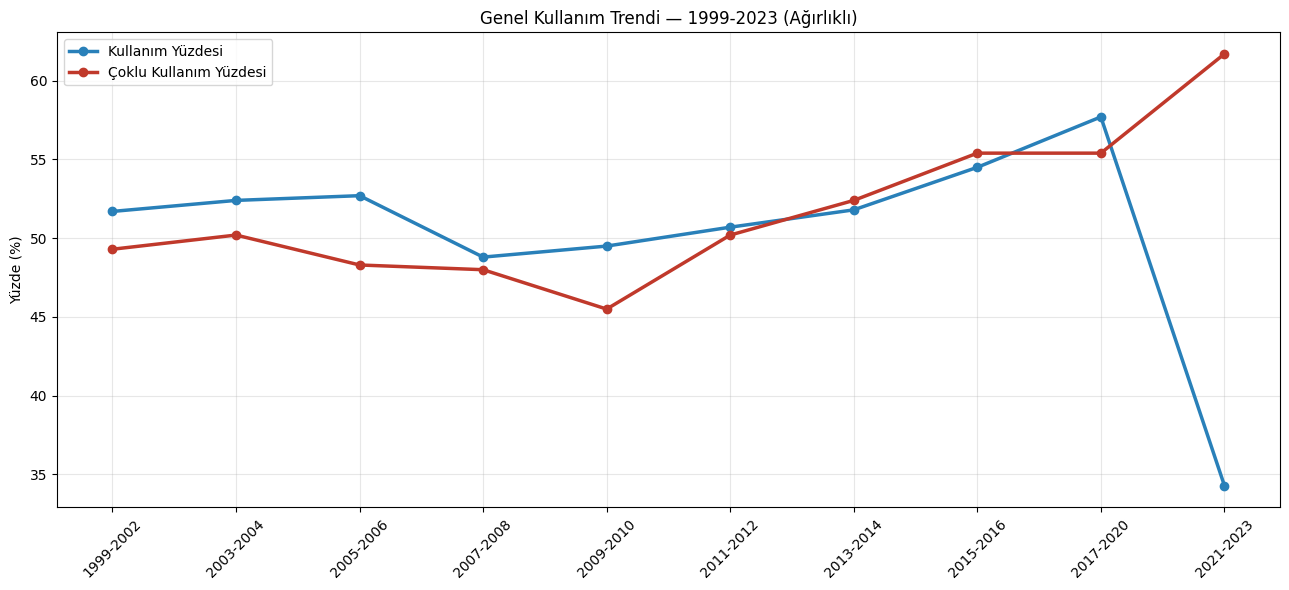

In [ ]:
# Overall usage trend, all ten cycle blocks (1999-2023)

from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt

client = bigquery.Client(project='dose-of-reality-506713')

CYCLE_ORDER = ['1999-2002', '2003-2004', '2005-2006', '2007-2008', '2009-2010',
               '2011-2012', '2013-2014', '2015-2016', '2017-2020', '2021-2023']

df = client.query("""
    SELECT cycle,
           kullanim_yuzdesi_agirlikli       AS usage_pct,
           coklu_kullanim_yuzdesi_agirlikli AS multi_use_pct
    FROM `dose-of-reality-506713.nhanes_dbt.mart_usage_trend_weighted`
""").to_dataframe()
df['cycle'] = pd.Categorical(df['cycle'], categories=CYCLE_ORDER, ordered=True)
df = df.sort_values('cycle')

print(df[['cycle', 'usage_pct', 'multi_use_pct']])

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(df['cycle'], df['usage_pct'], marker='o', label='Any supplement use', linewidth=2.5, color='#2980B9')
ax.plot(df['cycle'], df['multi_use_pct'], marker='o', label='2+ products, among users', linewidth=2.5, color='#C0392B')
ax.set_title('Overall supplement use, 1999-2023 (survey-weighted)')
ax.set_ylabel('Percent (%)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### A two-decade climb, then a break

| Cycle | Usage % | Multi-product use % |
|---|---|---|
| 1999–2002 | 53.7 | 47.6 |
| 2011–2012 | 50.7 | 50.2 |
| 2013–2014 | 51.8 | 52.4 |
| 2015–2016 | 54.5 | 55.4 |
| 2017–2020 | 57.7 | 55.4 |
| 2021–2023 | **34.3** | **61.7** |

Through 2017–2020, supplement use rises steadily. In 2021–2023 it collapses — **and multi-product use
jumps at the same moment**. Fewer people take supplements, but the ones who do take noticeably more.

### Two explanations, and the honest position

**1 — Survey-mode artefact.** The 2021–2023 supplement questionnaire was administered **by telephone**
because of COVID; earlier cycles were in person. Mode changes are well known to affect recall and
reporting.

**2 — Genuine pandemic behaviour change.** Two opposite behaviours plausibly coexisted: some people
disengaged (disrupted doctor visits, restricted shopping) while others intensified, reaching for
immune-associated products — vitamin D, vitamin C, zinc. That combination produces precisely the
observed pattern: overall rate falls as the casual middle drops out, while the remaining users skew
heavy.

**These two cannot be separated with this data**, and the notebook does not pretend otherwise. Both are
reported. [§24](#counterfactual) quantifies the total size of the break without attributing it to
either cause.

<a id="trend-overlap"></a>
## 15. Trend: ingredient overlap, 1999–2023

=== Çakışma Trendi - Tüm 10 Cycle (1999-2023) ===
ingredient_name  IRON  MAGNESIUM  NIACIN  VITAMIN A  VITAMIN D  ZINC
cycle                                                               
1999-2002         5.6       10.2     7.1        5.4       11.7   9.5
2003-2004         5.0        9.1     8.1        5.9       12.7   8.8
2005-2006         6.7        9.6     8.3        6.6       14.0   7.7
2007-2008         6.9       11.5     7.5        5.1       16.7   8.0
2009-2010         4.5        8.8     5.2        4.4       18.5   5.6
2011-2012         5.5       11.3     7.9        5.6       21.5   6.7
2013-2014         4.1       11.7     7.8        5.3       21.4   6.7
2015-2016         9.1       14.8     8.2        8.5       22.5   9.0
2017-2020         5.6       15.1     9.4        6.7       24.1   9.2
2021-2023        10.7       17.7     9.6        5.8       31.3  15.5


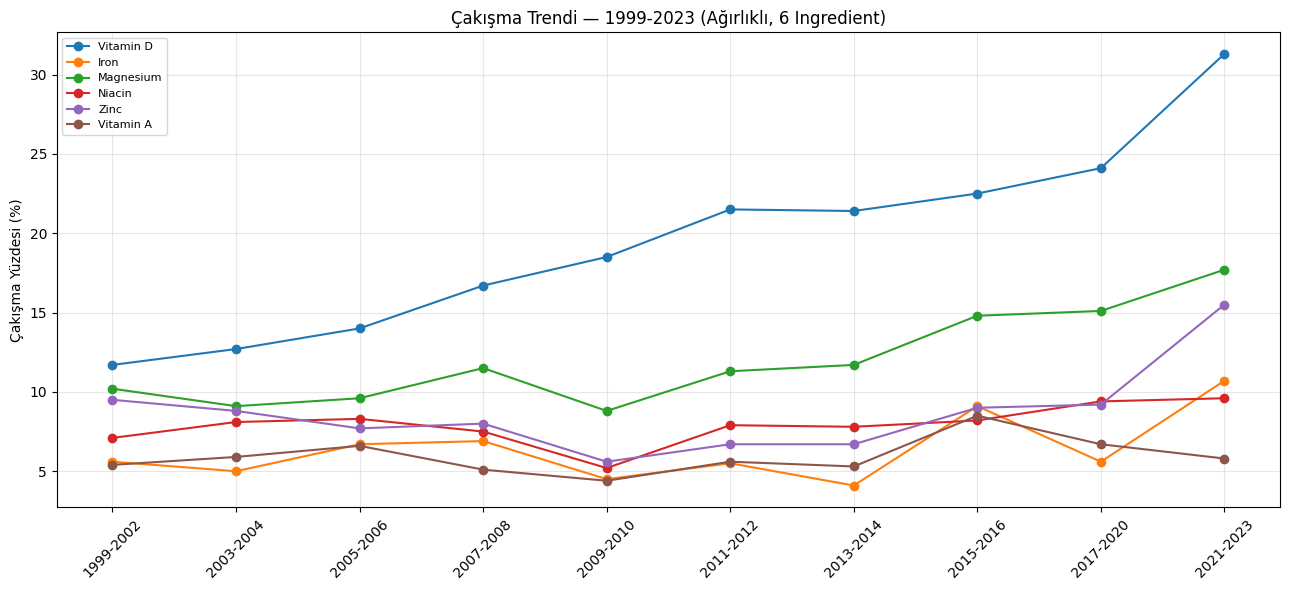

In [ ]:
# Ingredient overlap trend, all ten cycle blocks (1999-2023)

from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt

client = bigquery.Client(project='dose-of-reality-506713')

CYCLE_ORDER = ['1999-2002', '2003-2004', '2005-2006', '2007-2008', '2009-2010',
               '2011-2012', '2013-2014', '2015-2016', '2017-2020', '2021-2023']
INGREDIENTS = ['VITAMIN D', 'IRON', 'MAGNESIUM', 'NIACIN', 'ZINC', 'VITAMIN A']

query = """
SELECT cycle, ingredient_name, cakisma_yuzdesi_agirlikli AS overlap_pct
FROM `dose-of-reality-506713.nhanes_dbt.mart_ingredient_overlap_trend_weighted`
WHERE ingredient_name IN UNNEST(@ingredients)
"""
job_config = bigquery.QueryJobConfig(
    query_parameters=[bigquery.ArrayQueryParameter("ingredients", "STRING", INGREDIENTS)]
)
df = client.query(query, job_config=job_config).to_dataframe()

pivot = df.pivot(index='cycle', columns='ingredient_name', values='overlap_pct').reindex(CYCLE_ORDER)
print("=== Overlap trend, 1999-2023 ===")
print(pivot)

fig, ax = plt.subplots(figsize=(13, 6))
for ing in INGREDIENTS:
    ax.plot(pivot.index, pivot[ing], marker='o', label=ing.title())
ax.set_title('Ingredient overlap, 1999-2023 (survey-weighted, six ingredients)')
ax.set_ylabel('Overlap (%)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Is the 2009–2010 dip a real pattern or a data artefact?

Four of the six ingredients — iron, zinc, magnesium, vitamin A — share a dip around 2009–2010 and a
peak around 2015–2016. Before interpreting a shared wobble as behaviour, it is worth ruling out the
boring explanation: a drop in product-ID match rate in those cycles would depress every ingredient at
once and look exactly like this.

In [ ]:
# Is the 2009-2010 trough / 2015-2016 peak real, or a data artefact?
# A drop in product-id match rate would depress every ingredient at once - check for one

from google.cloud import bigquery
client = bigquery.Client(project='dose-of-reality-506713')

query = """
SELECT
    cycle,
    COUNT(*) as toplam_satir,
    COUNTIF(dspi_product_id IS NOT NULL) as eslesen,
    ROUND(COUNTIF(dspi_product_id IS NOT NULL) / COUNT(*) * 100, 1) as eslesme_yuzdesi
FROM `dose-of-reality-506713.nhanes_dbt.int_dsqids_all_cycles`
WHERE cycle IN ('2009-2010', '2015-2016', '2007-2008', '2011-2012', '2013-2014', '2017-2020')
GROUP BY cycle
ORDER BY cycle
"""
print(client.query(query).to_dataframe().to_string(index=False))

    cycle  toplam_satir  eslesen  eslesme_yuzdesi
2007-2008          8285     8178             98.7
2009-2010          8400     8297             98.8
2011-2012          8269     8156             98.6
2013-2014          9117     8966             98.3
2015-2016          9559     9393             98.3
2017-2020         16728    16728            100.0


### A shared cycle — and one ingredient that ignores it

Match rates across the neighbouring cycles are 98.3–98.8% (100% in 2017–2020) with no dip at
2009–2010. **The pattern is not an artefact.**

| Ingredient | 2009–2010 (trough) | 2015–2016 (peak) |
|---|---|---|
| Iron | 4.5 *(period low)* | 9.1 |
| Zinc | 5.6 *(period low)* | 9.0 |
| Magnesium | 8.8 *(period low)* | 14.8 |
| Vitamin A | 4.4 *(period low)* | 8.5 |

**Vitamin D is exempt.** It rises almost monotonically across the whole 24 years, 11.7% → 31.3%, with
no trough.

Two timing-consistent but unverified hypotheses for the shared wobble: the 2008–2009 financial crisis
suppressing discretionary spending around 2009–2010, and rising health/nutrition media attention around
2015–2016. Neither is testable with this data and both are labelled as speculation.

Vitamin D's immunity to it suggests its growth is a structural trend of its own — plausibly the steady
rise in vitamin D deficiency awareness — rather than something economically cyclical.

<a id="trend-ul"></a>
## 16. Trend: UL exceedance, 1999–2023

=== UL Aşım Trendi - Tüm 10 Cycle (1999-2023) ===
ingredient_name  IRON  MAGNESIUM  NIACIN  VITAMIN A  VITAMIN D  ZINC
cycle                                                               
1999-2002         7.2        6.2    20.1        6.2        0.0   3.1
2003-2004         6.5        5.8    18.6        4.9        0.0   3.4
2005-2006         4.7        4.7    19.1        5.3        0.1   3.3
2007-2008         7.2        5.4    16.8        4.2        0.7   3.7
2009-2010         8.9        4.1    15.3        3.1        3.0   3.2
2011-2012         8.3        5.0    18.3        3.7        6.8   3.6
2013-2014        11.6        8.0    19.3        4.1       13.0   3.5
2015-2016        14.1       11.7    16.4        3.0       16.0   3.3
2017-2020        18.4       13.6    16.8        3.7       18.5   4.1
2021-2023        17.1       13.9    11.7        1.9       27.5   9.4


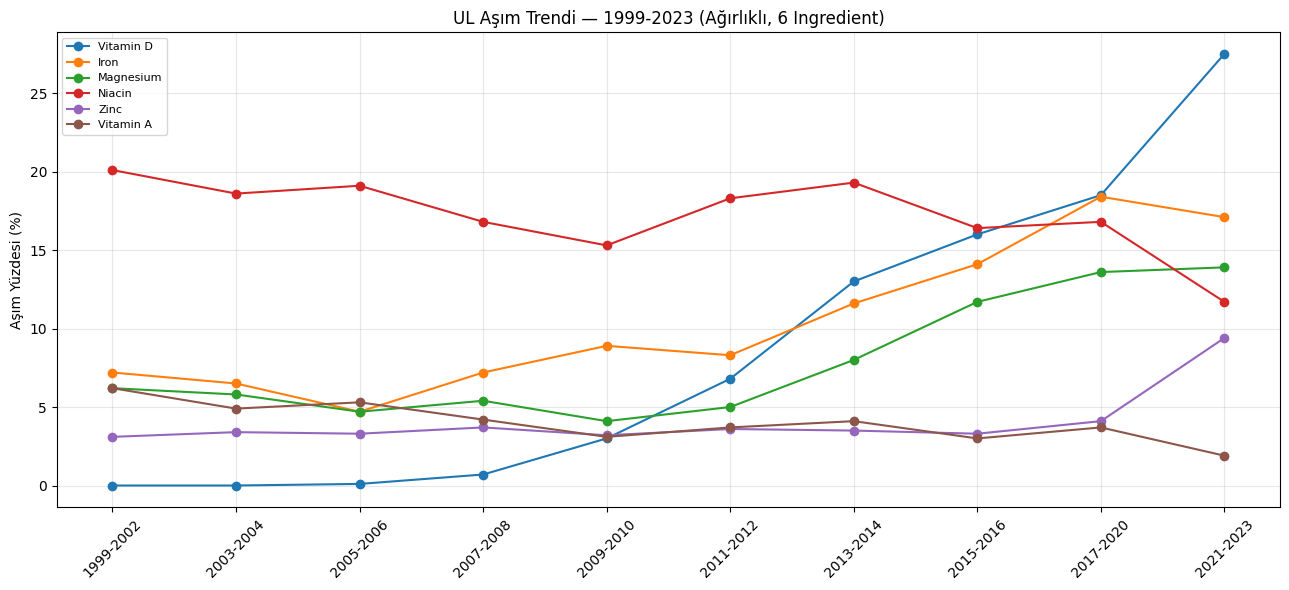

In [ ]:
# UL exceedance trend, all ten cycle blocks (1999-2023)

from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt

client = bigquery.Client(project='dose-of-reality-506713')

CYCLE_ORDER = ['1999-2002', '2003-2004', '2005-2006', '2007-2008', '2009-2010',
               '2011-2012', '2013-2014', '2015-2016', '2017-2020', '2021-2023']
INGREDIENTS = ['VITAMIN D', 'IRON', 'MAGNESIUM', 'NIACIN', 'ZINC', 'VITAMIN A']

query = """
SELECT cycle, ingredient_name, asim_yuzdesi_agirlikli AS exceedance_pct
FROM `dose-of-reality-506713.nhanes_dbt.mart_ul_comparison_trend_weighted`
WHERE ingredient_name IN UNNEST(@ingredients)
"""
job_config = bigquery.QueryJobConfig(
    query_parameters=[bigquery.ArrayQueryParameter("ingredients", "STRING", INGREDIENTS)]
)
df = client.query(query, job_config=job_config).to_dataframe()

pivot = df.pivot(index='cycle', columns='ingredient_name', values='exceedance_pct').reindex(CYCLE_ORDER)
print("=== UL exceedance trend, 1999-2023 ===")
print(pivot)

fig, ax = plt.subplots(figsize=(13, 6))
for ing in INGREDIENTS:
    ax.plot(pivot.index, pivot[ing], marker='o', label=ing.title())
ax.set_title('UL exceedance, 1999-2023 (survey-weighted, six ingredients)')
ax.set_ylabel('Exceedance (%)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Two ingredients, two completely different stories

| Cycle | Iron | Magnesium | Niacin | Vitamin A | Vitamin D | Zinc |
|---|---|---|---|---|---|---|
| 1999–2002 | 7.2 | 6.2 | 20.1 | 6.2 | **0.0** | 3.1 |
| 2003–2004 | 6.5 | 5.8 | 18.6 | 4.9 | **0.0** | 3.4 |
| 2005–2006 | 4.7 | 4.7 | 19.1 | 5.3 | 0.1 | 3.3 |
| 2007–2008 | 7.2 | 5.4 | 16.8 | 4.2 | 0.7 | 3.7 |
| 2009–2010 | 8.9 | 4.1 | 15.3 | 3.1 | 3.0 | 3.2 |
| 2011–2012 | 8.3 | 5.0 | 18.3 | 3.7 | 6.8 | 3.6 |
| 2013–2014 | 11.6 | 8.0 | 19.3 | 4.1 | 13.0 | 3.5 |
| 2015–2016 | 14.1 | 11.7 | 16.4 | 3.0 | 16.0 | 3.3 |
| 2017–2020 | 18.4 | 13.6 | 16.8 | 3.7 | 18.5 | 4.1 |
| 2021–2023 | 17.1 | 13.9 | **11.7** | 1.9 | **27.5** | **9.4** |

**Vitamin D — an existing acceleration, accelerating further.** Exceedance is effectively *zero*
(0.0–0.1%) from 1999 through 2006: vitamin D supplementation was not yet widespread and high-dose
products were not on shelves. From 2007–2008 (0.7%) it climbs continuously and increasingly steeply,
reaching 27.5%. The timing tracks the vitamin D deficiency awareness wave of the late 2000s. The
pandemic period sharpened a trend that was already well underway — it did not start one.

**Zinc — a behaviour that appeared from nothing.** Zinc sits flat in a 3.1–4.1% band for **more than
twenty years**, with no discernible trend. Then in the final cycle alone it jumps to 9.4%, roughly 2.5×
the entire preceding period. That is qualitatively different from vitamin D: not an acceleration but a
new behaviour, and the timing coincides with pandemic-era "immune support" messaging. Consistent
timing, not demonstrated causation.

**The others, briefly.** Iron and magnesium peak in 2017–2020 and flatten rather than genuinely fall.
Niacin and vitamin A show long, steady declines running for 24 years — unrelated to the pandemic and
predating it by two decades.

**This vitamin D / zinc contrast is the strongest narrative in the project.** Both look like "a pandemic
spike" on a chart. The mechanisms behind them have nothing in common.

<a id="source"></a>
## 17. Where exceedance comes from: overlap-driven vs single-product


=== VITAMIN D ===
    cycle  cakismali_asim_yuzdesi_agirlikli  tek_urun_asim_yuzdesi_agirlikli
1999-2002                               0.0                              0.0
2003-2004                               0.0                              0.0
2005-2006                               0.0                              0.1
2007-2008                               0.5                              0.2
2009-2010                               2.4                              0.6
2011-2012                               5.1                              1.7
2013-2014                              10.0                              3.0
2015-2016                              11.0                              5.0
2017-2020                              13.4                              5.1
2021-2023                              20.6                              6.9

=== IRON ===
    cycle  cakismali_asim_yuzdesi_agirlikli  tek_urun_asim_yuzdesi_agirlikli
1999-2002                               2.3

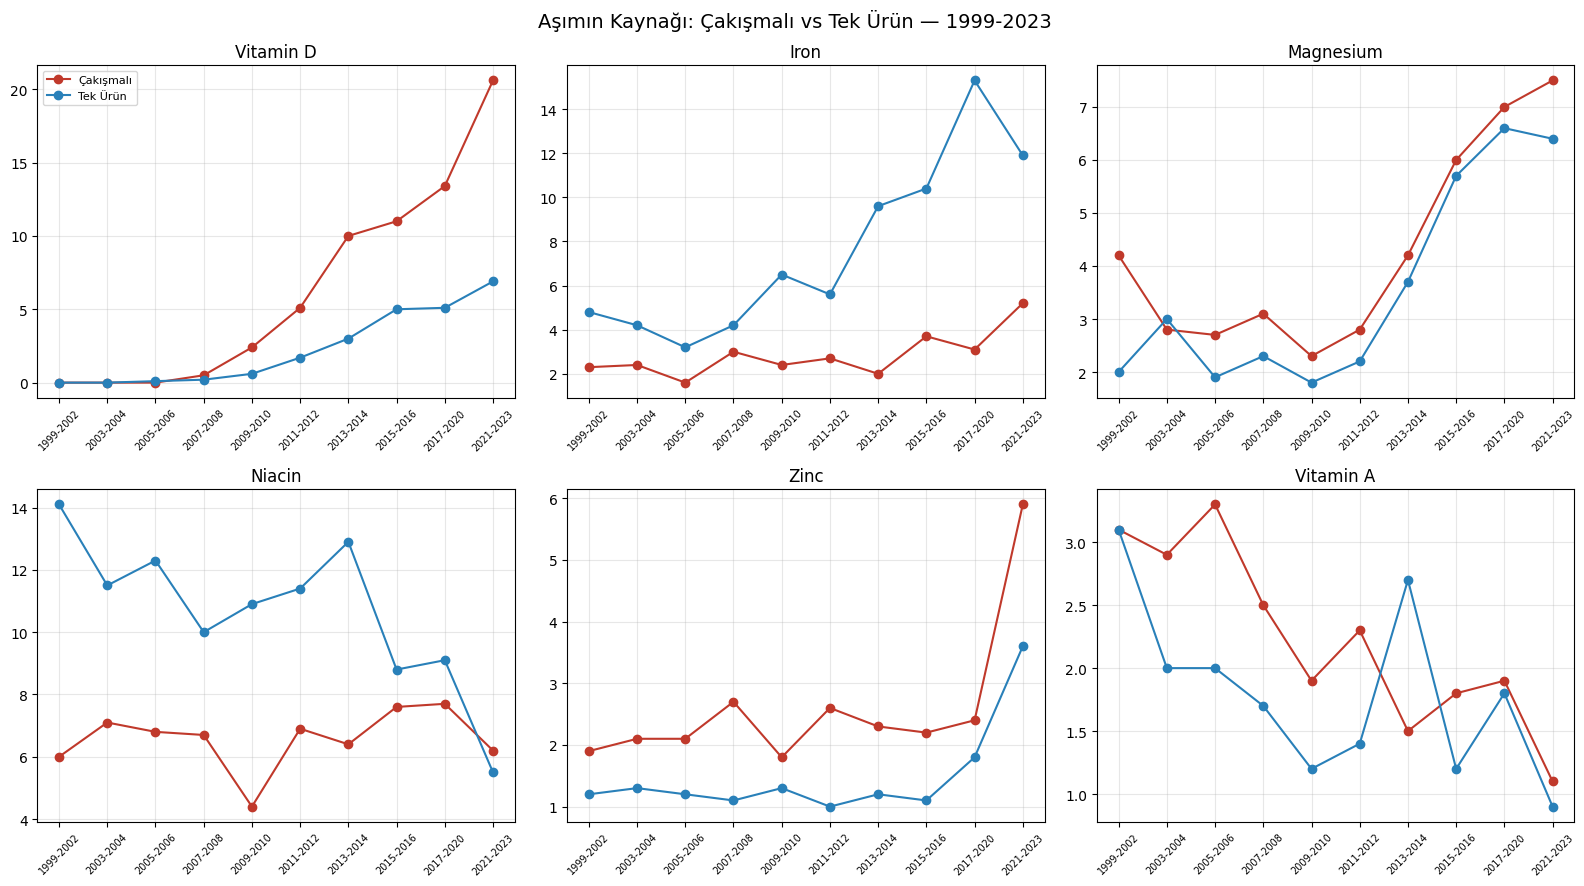

In [ ]:
# Source of exceedance: overlap-driven vs single-product, all ten cycle blocks

from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt

client = bigquery.Client(project='dose-of-reality-506713')

CYCLE_ORDER = ['1999-2002', '2003-2004', '2005-2006', '2007-2008', '2009-2010',
               '2011-2012', '2013-2014', '2015-2016', '2017-2020', '2021-2023']
INGREDIENTS = ['VITAMIN D', 'IRON', 'MAGNESIUM', 'NIACIN', 'ZINC', 'VITAMIN A']

df = client.query(f"""
    SELECT cycle, ingredient_name,
           cakismali_asim_yuzdesi_agirlikli AS overlap_driven_pct,
           tek_urun_asim_yuzdesi_agirlikli  AS single_product_pct
    FROM `dose-of-reality-506713.nhanes_dbt.mart_ul_source_breakdown_trend`
    WHERE ingredient_name IN UNNEST({INGREDIENTS})
""").to_dataframe()

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for idx, ing in enumerate(INGREDIENTS):
    sub = df[df['ingredient_name']==ing].copy()
    sub['cycle'] = pd.Categorical(sub['cycle'], categories=CYCLE_ORDER, ordered=True)
    sub = sub.sort_values('cycle')

    print(f"\n=== {ing} ===")
    print(sub[['cycle', 'overlap_driven_pct', 'single_product_pct']].to_string(index=False))

    ax = axes[idx]
    ax.plot(sub['cycle'], sub['overlap_driven_pct'], marker='o', label='Overlap-driven', color='#C0392B')
    ax.plot(sub['cycle'], sub['single_product_pct'], marker='o', label='Single product', color='#2980B9')
    ax.set_title(ing.title())
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.grid(True, alpha=0.3)
    if idx == 0:
        ax.legend(fontsize=8)

fig.suptitle('Source of exceedance: overlap-driven vs single-product, 1999-2023', fontsize=14)
plt.tight_layout()
plt.show()

### Six ingredients, six different risk mechanisms

Aggregate trends imply a single story. Split by *source* of exceedance, each ingredient tells a
different one — and the public-health implication differs accordingly.

**Vitamin D — purely overlap-driven growth**

| | 1999–2002 | 2011–2012 | 2017–2020 | 2021–2023 |
|---|---|---|---|---|
| Overlap-driven | 0.0 | 5.1 | 13.4 | **20.6** |
| Single-product | 0.0 | 1.7 | 5.1 | 6.9 |

Nearly all of it is people stacking products, and that component is accelerating (≈4× since 2011).

**Iron — a single-product peak and decline**

| | 2013–2014 | 2017–2020 | 2021–2023 |
|---|---|---|---|
| Single-product | 9.6 | **15.3** | 11.9 |
| Overlap-driven | 2.0 | 3.1 | 5.2 |

Iron's irregular headline trend is entirely the single-product component peaking and receding. The
overlap component stays small.

**Niacin — the 24-year decline is a single-product story**

| | 1999–2002 | 2013–2014 | 2021–2023 |
|---|---|---|---|
| Single-product | 14.1 | 12.9 | **5.5** |
| Overlap-driven | 6.0 | 6.4 | 6.2 |

The overlap component is essentially flat for 24 years; the entire decline is single-product. This is
what you would expect if typical product **formulations** got lower-dose over time, rather than people
changing their behaviour.

**Zinc — a two-front jump**

| | 2017–2020 | 2021–2023 |
|---|---|---|
| Overlap-driven | 2.4 | **5.9** |
| Single-product | 1.8 | **3.6** |

Both components roughly double at once — unlike vitamin D (overlap only) or iron (single-product only).

**Magnesium** grows on both fronts in parallel (2.0 → 7.5 and 2.0 → 6.4), with no asymmetry.
**Vitamin A** declines on both (3.1 → 1.1 and 3.1 → 0.9).

### Why this matters beyond the chart

"Overall exceedance rose" is not an actionable statement. The mechanism is:

- **Vitamin D** — the risk is stacking products. "Check for overlap" is the right message.
- **Iron, niacin** — the risk is the dose on one label. "Check for overlap" would miss it entirely.
- **Zinc** — both, simultaneously.

Public-health messaging has to be ingredient-specific, and this breakdown is what shows why.

<a id="part4"></a>
<a id="sex"></a>
# Part IV — Who is affected

Three demographic breakdowns, each following the same structure: overall usage → overlap → UL
exceedance → source of exceedance. All rates are survey-weighted using each cycle's own interview
weight.

## 18. Sex

=== Kişi Sayısı ===
gender     Female   Male
cycle                   
1999-2002   10790  10214
2003-2004    5152   4970
2005-2006    5268   5080
2007-2008    5053   5096
2009-2010    5312   5225
2011-2012    4900   4856
2013-2014    5172   5003
2015-2016    5079   4892
2017-2020    7839   7721
2021-2023    6358   5575

=== Kullanım Yüzdesi (Ağırlıklı) ===
gender     Female  Male
cycle                  
1999-2002    55.4  47.8
2003-2004    56.9  47.8
2005-2006    57.3  47.9
2007-2008    53.6  43.7
2009-2010    52.6  46.3
2011-2012    54.7  46.4
2013-2014    57.0  46.4
2015-2016    59.5  49.4
2017-2020    62.7  52.4
2021-2023    37.1  31.5


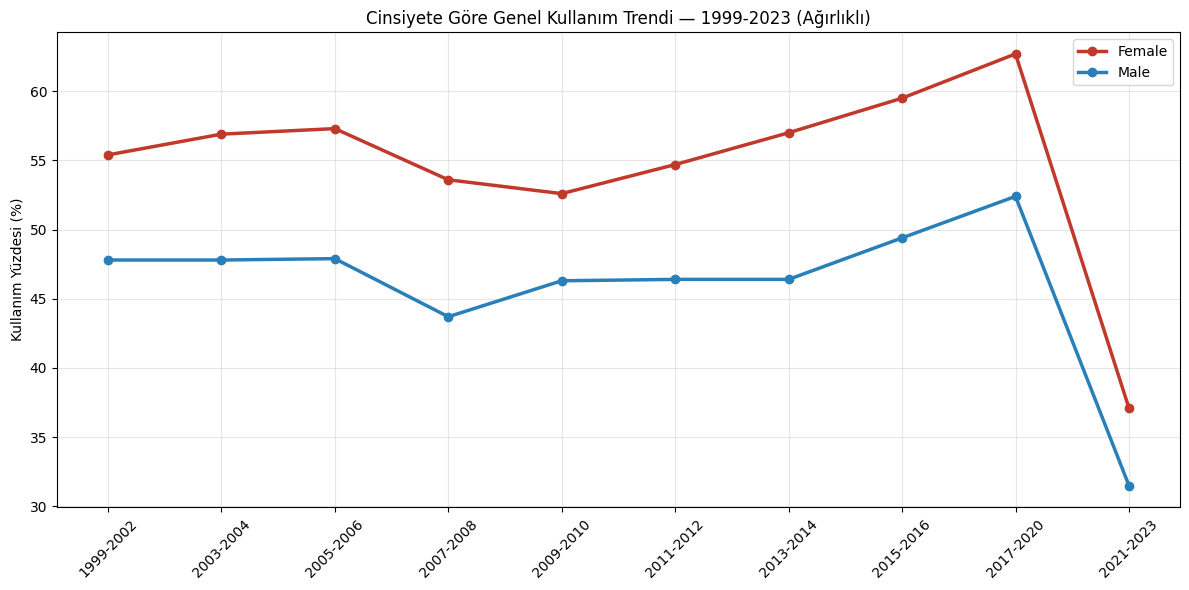

In [ ]:
# Overall usage trend by sex, all ten cycle blocks (1999-2023)

from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt

client = bigquery.Client(project='dose-of-reality-506713')
CYCLE_ORDER = ['1999-2002', '2003-2004', '2005-2006', '2007-2008', '2009-2010',
               '2011-2012', '2013-2014', '2015-2016', '2017-2020', '2021-2023']

query = """
with usage_per_person as (
    select
        d.seqn, d.cycle, d.gender, d.interview_weight,
        count(distinct i.raw_product_id) as n_products_used
    from `dose-of-reality-506713.nhanes_dbt.int_demo_all_cycles` as d
    left join `dose-of-reality-506713.nhanes_dbt.int_dsqids_all_cycles` as i
        on d.seqn = i.seqn and d.cycle = i.cycle
    group by d.seqn, d.cycle, d.gender, d.interview_weight
)
select
    cycle, gender,
    count(*) as n_kisi,
    round(sum(case when n_products_used > 0 then interview_weight else 0 end)
          / sum(interview_weight) * 100, 1) as kullanim_yuzdesi_agirlikli
from usage_per_person
group by cycle, gender
order by cycle, gender
"""

df = client.query(query).to_dataframe()
pivot = df.pivot(index='cycle', columns='gender', values='kullanim_yuzdesi_agirlikli').reindex(CYCLE_ORDER)
pivot_n = df.pivot(index='cycle', columns='gender', values='n_kisi').reindex(CYCLE_ORDER)

print("=== Person counts ===")
print(pivot_n)
print("\n=== Usage % (survey-weighted) ===")
print(pivot)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(pivot.index, pivot['Female'], marker='o', label='Female', color='#C0392B', linewidth=2.5)
ax.plot(pivot.index, pivot['Male'], marker='o', label='Male', color='#2980B9', linewidth=2.5)
ax.set_title('Supplement use by sex, 1999-2023 (survey-weighted)')
ax.set_ylabel('Usage (%)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

=== CAKISMA - Cinsiyet Kirilimli (6 Ingredient Ortalamasi) ===
gender     Female  Male
cycle                  
1999-2002     9.6   6.4
2003-2004     9.6   6.5
2005-2006    10.5   6.6
2007-2008    11.0   7.0
2009-2010     9.2   6.0
2011-2012    11.5   7.3
2013-2014    10.8   7.7
2015-2016    13.6   9.9
2017-2020    13.2   9.6
2021-2023    16.9  12.8

=== UL ASIMI - Cinsiyet Kirilimli (6 Ingredient Ortalamasi) ===
gender     Female  Male
cycle                  
1999-2002     7.8   6.2
2003-2004     6.8   6.2
2005-2006     6.5   5.7
2007-2008     7.2   5.2
2009-2010     6.7   5.6
2011-2012     8.2   6.6
2013-2014    10.6   8.9
2015-2016    11.5   9.7
2017-2020    13.6  10.8
2021-2023    15.0  11.7


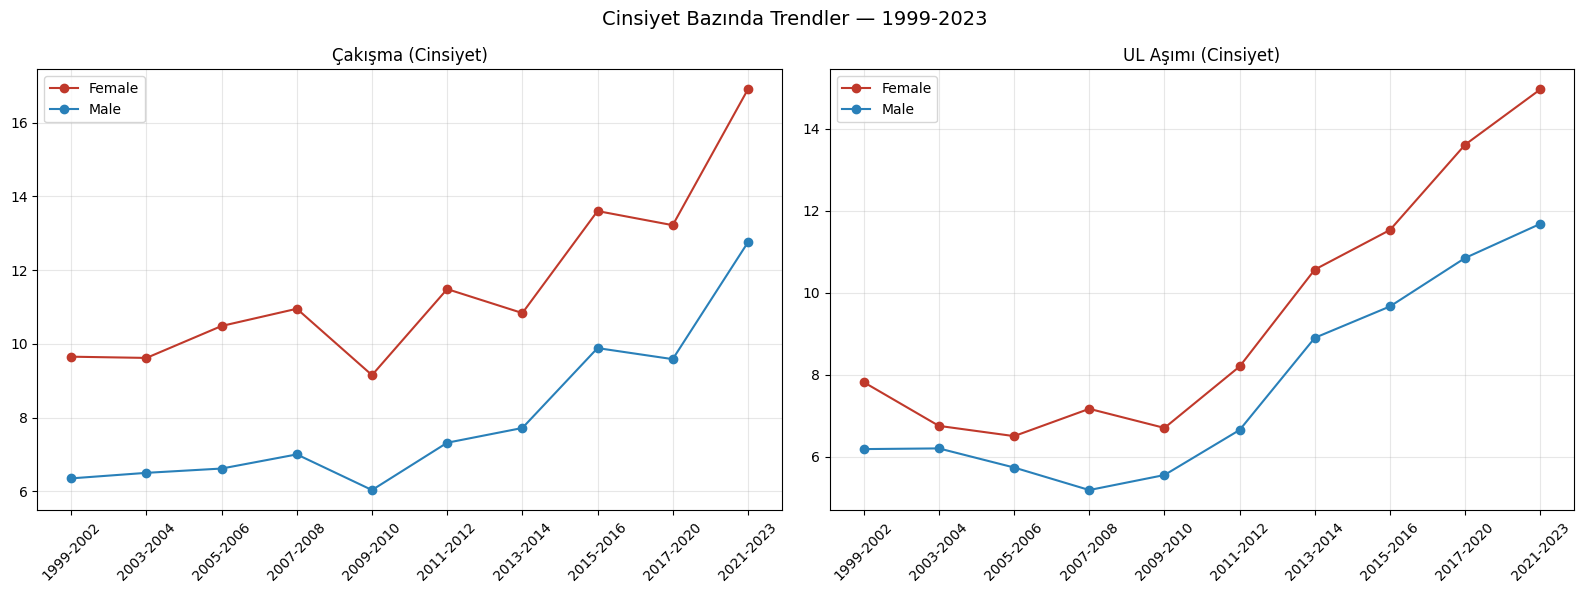

In [ ]:
# By sex: overlap and UL exceedance trends, all ten cycle blocks

from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt

client = bigquery.Client(project='dose-of-reality-506713')
CYCLE_ORDER = ['1999-2002', '2003-2004', '2005-2006', '2007-2008', '2009-2010',
               '2011-2012', '2013-2014', '2015-2016', '2017-2020', '2021-2023']
INGREDIENTS = ['VITAMIN D', 'IRON', 'MAGNESIUM', 'NIACIN', 'ZINC', 'VITAMIN A']

query_overlap = """
select
    cycle, gender, ingredient_name,
    count(*) as n_kisi,
    round(sum(case when has_overlap then interview_weight else 0 end)
          / sum(interview_weight) * 100, 1) as cakisma_yuzdesi
from (
    select
        i.cycle, i.seqn, i.ingredient_name, d.gender, d.interview_weight,
        count(distinct i.dspi_product_id) > 1 as has_overlap
    from `dose-of-reality-506713.nhanes_dbt.int_supplement_ingredients_all_cycles` i
    left join `dose-of-reality-506713.nhanes_dbt.int_demo_all_cycles` d
        on i.seqn = d.seqn and i.cycle = d.cycle
    where i.ingredient_name in unnest(@ingredients)
    group by i.cycle, i.seqn, i.ingredient_name, d.gender, d.interview_weight
)
group by cycle, gender, ingredient_name
"""

query_ul = """
with aggregated as (
    select
        u.seqn, u.cycle, u.ingredient_name, u.has_ul_defined,
        sum(case when u.unit_convertible then u.quantity_mcg else 0 end) as total_quantity_mcg,
        any_value(u.ul_value_mcg) as ul_value_mcg
    from `dose-of-reality-506713.nhanes_dbt.int_ingredients_with_ul_all_cycles` u
    where u.ingredient_name in unnest(@ingredients)
    group by u.seqn, u.cycle, u.ingredient_name, u.has_ul_defined
),
with_demo as (
    select a.*, d.gender, d.interview_weight
    from aggregated a
    left join `dose-of-reality-506713.nhanes_dbt.int_demo_all_cycles` d
        on a.seqn = d.seqn and a.cycle = d.cycle
)
select
    cycle, gender, ingredient_name,
    count(*) as n_kisi,
    round(sum(case when total_quantity_mcg > ul_value_mcg then interview_weight else 0 end)
          / sum(interview_weight) * 100, 1) as asim_yuzdesi
from with_demo
where has_ul_defined
group by cycle, gender, ingredient_name
"""

job_config = bigquery.QueryJobConfig(
    query_parameters=[bigquery.ArrayQueryParameter("ingredients", "STRING", INGREDIENTS)]
)
df_overlap = client.query(query_overlap, job_config=job_config).to_dataframe()
df_ul = client.query(query_ul, job_config=job_config).to_dataframe()

print("=== Overlap by sex (mean across the six ingredients) ===")
overlap_avg = df_overlap.groupby(['cycle', 'gender'])['cakisma_yuzdesi'].mean().reset_index()
pivot_overlap = overlap_avg.pivot(index='cycle', columns='gender', values='cakisma_yuzdesi').reindex(CYCLE_ORDER)
print(pivot_overlap.round(1))

print("\n=== UL exceedance by sex (mean across the six ingredients) ===")
ul_avg = df_ul.groupby(['cycle', 'gender'])['asim_yuzdesi'].mean().reset_index()
pivot_ul = ul_avg.pivot(index='cycle', columns='gender', values='asim_yuzdesi').reindex(CYCLE_ORDER)
print(pivot_ul.round(1))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].plot(pivot_overlap.index, pivot_overlap['Female'], marker='o', label='Female', color='#C0392B')
axes[0].plot(pivot_overlap.index, pivot_overlap['Male'], marker='o', label='Male', color='#2980B9')
axes[0].set_title('Overlap')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(pivot_ul.index, pivot_ul['Female'], marker='o', label='Female', color='#C0392B')
axes[1].plot(pivot_ul.index, pivot_ul['Male'], marker='o', label='Male', color='#2980B9')
axes[1].set_title('UL exceedance')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

fig.suptitle('Trends by sex, 1999-2023', fontsize=14)
plt.tight_layout()
plt.show()

          cakismali_asim      tek_urun_asim     
gender            Female Male        Female Male
cycle                                           
1999-2002            3.3  2.5           4.5  4.0
2003-2004            3.2  2.5           3.4  3.9
2005-2006            3.2  2.3           3.3  3.7
2007-2008            3.4  2.5           3.4  2.6
2009-2010            2.8  2.2           3.5  3.3
2011-2012            4.5  3.1           3.6  3.5
2013-2014            5.5  3.8           5.0  5.0
2015-2016            6.7  4.6           4.8  4.7
2017-2020            7.2  5.7           6.1  5.1
2021-2023            9.8  7.7           6.2  4.3


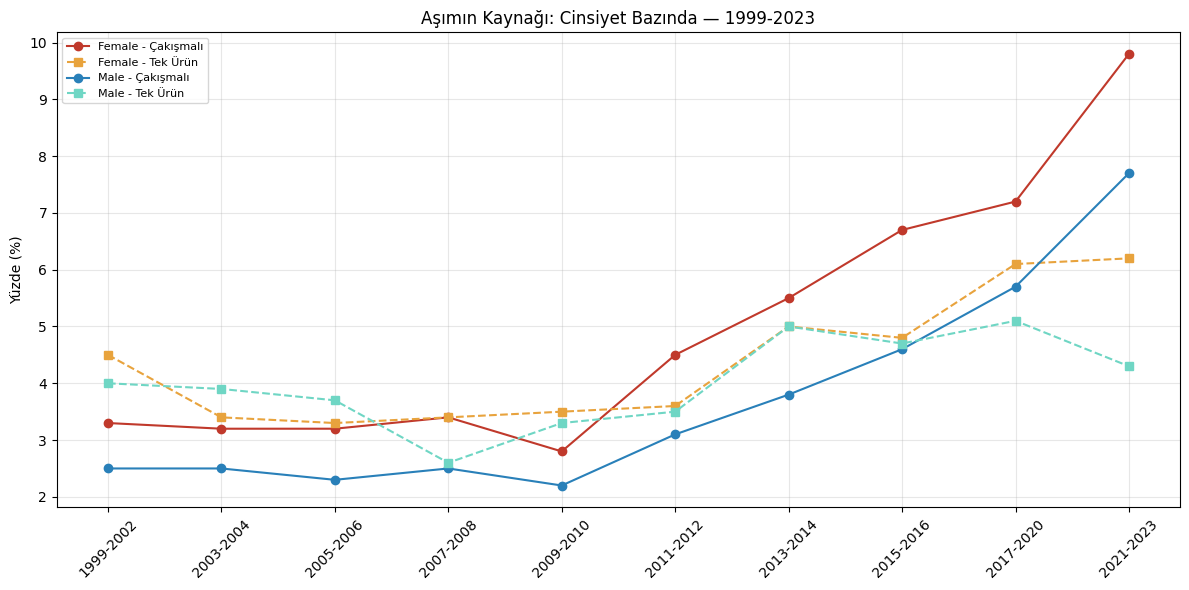

In [ ]:
# By sex: source of exceedance (overlap-driven vs single-product), all ten cycle blocks

from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt

client = bigquery.Client(project='dose-of-reality-506713')
CYCLE_ORDER = ['1999-2002', '2003-2004', '2005-2006', '2007-2008', '2009-2010',
               '2011-2012', '2013-2014', '2015-2016', '2017-2020', '2021-2023']
INGREDIENTS = ['VITAMIN D', 'IRON', 'MAGNESIUM', 'NIACIN', 'ZINC', 'VITAMIN A']

query = """
with overlap_flag as (
    select cycle, seqn, ingredient_name,
        count(distinct dspi_product_id) > 1 as has_overlap
    from `dose-of-reality-506713.nhanes_dbt.int_supplement_ingredients_all_cycles`
    where ingredient_name in unnest(@ingredients)
    group by cycle, seqn, ingredient_name
),
exceeds_flag as (
    select seqn, cycle, ingredient_name, has_ul_defined,
        sum(case when unit_convertible then quantity_mcg else 0 end) as total_quantity_mcg,
        any_value(ul_value_mcg) as ul_value_mcg
    from `dose-of-reality-506713.nhanes_dbt.int_ingredients_with_ul_all_cycles`
    where ingredient_name in unnest(@ingredients)
    group by seqn, cycle, ingredient_name, has_ul_defined
),
combined as (
    select
        o.cycle, o.seqn, o.ingredient_name, o.has_overlap,
        case when e.has_ul_defined and e.total_quantity_mcg > e.ul_value_mcg then true
             when e.has_ul_defined then false else null end as exceeds_ul,
        d.gender, d.interview_weight
    from overlap_flag o
    left join exceeds_flag e on o.cycle=e.cycle and o.seqn=e.seqn and o.ingredient_name=e.ingredient_name
    left join `dose-of-reality-506713.nhanes_dbt.int_demo_all_cycles` d
        on o.cycle=d.cycle and o.seqn=d.seqn
    where e.has_ul_defined
)
select
    cycle, gender,
    round(sum(case when has_overlap and exceeds_ul then interview_weight else 0 end)
          / sum(interview_weight) * 100, 1) as overlap_driven_pct,
    round(sum(case when not has_overlap and exceeds_ul then interview_weight else 0 end)
          / sum(interview_weight) * 100, 1) as single_product_pct
from combined
group by cycle, gender
"""

job_config = bigquery.QueryJobConfig(
    query_parameters=[bigquery.ArrayQueryParameter("ingredients", "STRING", INGREDIENTS)]
)
df = client.query(query, job_config=job_config).to_dataframe()
df['cycle'] = pd.Categorical(df['cycle'], categories=CYCLE_ORDER, ordered=True)
df = df.sort_values('cycle')

print(df.pivot(index='cycle', columns='gender', values=['overlap_driven_pct', 'single_product_pct']))

fig, ax = plt.subplots(figsize=(12, 6))
for gender, c1, c2 in [('Female', '#C0392B', '#E8A33D'), ('Male', '#2980B9', '#6FD6C4')]:
    sub = df[df['gender']==gender]
    ax.plot(sub['cycle'], sub['overlap_driven_pct'], marker='o', linestyle='-', label=f'{gender} - overlap-driven', color=c1)
    ax.plot(sub['cycle'], sub['single_product_pct'], marker='s', linestyle='--', label=f'{gender} - single product', color=c2)

ax.set_title('Source of exceedance by sex, 1999-2023')
ax.set_ylabel('Percent (%)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Findings: a stable behavioural gap, a widening risk gap

**Overall usage** — women higher in every cycle, by a structural 7.6–10.3 points that survives even the
2021–2023 break (5.6 points):

| Cycle | Female | Male | Gap |
|---|---|---|---|
| 1999–2002 | 55.4 | 47.8 | 7.6 |
| 2017–2020 | 62.7 | 52.4 | 10.3 |
| 2021–2023 | 37.1 | 31.5 | 5.6 |

**Overlap** — the gap is remarkably constant, 3.1–4.2 points across 24 years:

| Cycle | Female | Male | Gap |
|---|---|---|---|
| 1999–2002 | 9.6 | 6.4 | 3.2 |
| 2017–2020 | 13.2 | 9.6 | 3.6 |
| 2021–2023 | 16.9 | 12.8 | 4.1 |

**UL exceedance — this is where it changes.** Unlike overlap, the exceedance gap is small and noisy
through 2016, then opens systematically from 2017:

| Cycle | Female | Male | Gap |
|---|---|---|---|
| 1999–2002 | 7.8 | 6.2 | 1.6 |
| 2015–2016 | 11.5 | 9.7 | 1.8 |
| 2017–2020 | 13.6 | 10.8 | 2.8 |
| 2021–2023 | 15.0 | 11.7 | **3.3** |

**Source of the widening gap** — it is the overlap component:

| Cycle | Overlap (F) | Overlap (M) | Gap | Single (F) | Single (M) | Gap |
|---|---|---|---|---|---|---|
| 1999–2002 | 3.3 | 2.5 | 0.8 | 4.5 | 4.0 | 0.5 |
| 2011–2012 | 4.5 | 3.1 | 1.4 | 3.6 | 3.5 | 0.1 |
| 2017–2020 | 7.2 | 5.7 | 1.5 | 6.1 | 5.1 | 1.0 |
| 2021–2023 | **9.8** | **7.7** | **2.1** | 6.2 | 4.3 | 1.9 |

**Reading:** the *behavioural* sex difference (who takes supplements, who stacks them) has been stable
for 24 years. What changed recently is that this behaviour started translating into actual dose
exceedance — women's multi-product use is growing faster than men's, and it has now crossed into
measurable risk. The single-product component even declines for men in the last cycle.

**Per-ingredient, 2021–2023** — the aggregate hides real heterogeneity. Vitamin D shows the largest
overlap gap (34.9 F vs 26.4 M); magnesium's exceedance gap is driven by *single-product* use (8.9 F vs
3.3 M, ≈2.7×); iron shows essentially no sex gap at all; and zinc is the one reversal, with men
slightly higher (8.9 F vs 10.1 M). "Women are at higher risk" is too coarse a summary to be useful —
each ingredient needs its own read.

<a id="age"></a>
## 19. Age

=== Kişi Sayısı ===
age_group  0-17  18-34  35-49  50-64   65+
cycle                                     
1999-2002  9563   3916   2542   2128  2855
2003-2004  4502   1944   1166   1016  1494
2005-2006  4785   2097   1252   1025  1189
2007-2008  3921   1675   1479   1518  1556
2009-2010  4010   1860   1638   1506  1523
2011-2012  3892   1794   1366   1454  1250
2013-2014  4062   1826   1507   1474  1306
2015-2016  3979   1749   1418   1447  1378
2017-2020  5867   2579   2127   2576  2411
2021-2023  3780   1878   1592   2097  2586

=== Kullanım Yüzdesi (Ağırlıklı) ===
age_group  0-17  18-34  35-49  50-64   65+
cycle                                     
1999-2002  34.2   45.4   59.4   65.9  68.9
2003-2004  32.4   45.1   58.0   70.6  74.4
2005-2006  33.5   46.9   58.2   67.4  72.8
2007-2008  31.4   40.0   53.2   63.1  71.3
2009-2010  34.3   39.9   52.0   63.2  72.6
2011-2012  33.6   41.8   52.4   64.2  75.1
2013-2014  34.7   43.6   50.3   67.5  75.2
2015-2016  36.4   44.7   56.7   65.9  8

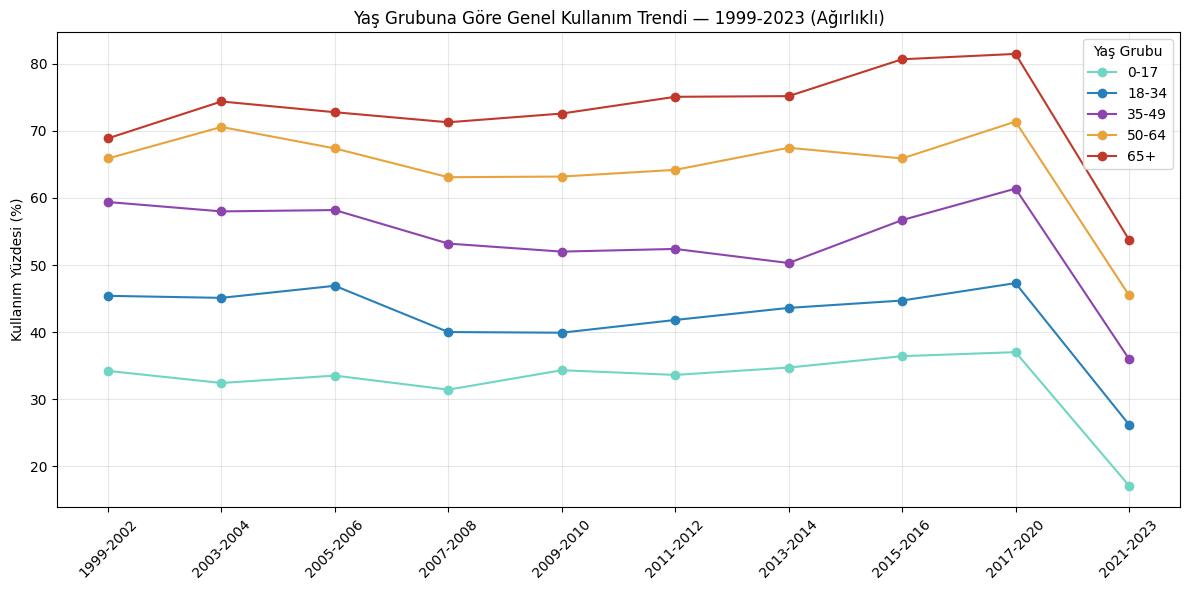

In [ ]:
# Overall usage trend by age group, all ten cycle blocks (1999-2023)

from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt

client = bigquery.Client(project='dose-of-reality-506713')
CYCLE_ORDER = ['1999-2002', '2003-2004', '2005-2006', '2007-2008', '2009-2010',
               '2011-2012', '2013-2014', '2015-2016', '2017-2020', '2021-2023']
AGE_ORDER = ['0-17', '18-34', '35-49', '50-64', '65+']

query = """
with usage_per_person as (
    select
        d.seqn, d.cycle,
        case
            when d.age_years < 18 then '0-17'
            when d.age_years < 35 then '18-34'
            when d.age_years < 50 then '35-49'
            when d.age_years < 65 then '50-64'
            else '65+'
        end as age_group,
        d.interview_weight,
        count(distinct i.raw_product_id) as n_products_used
    from `dose-of-reality-506713.nhanes_dbt.int_demo_all_cycles` as d
    left join `dose-of-reality-506713.nhanes_dbt.int_dsqids_all_cycles` as i
        on d.seqn = i.seqn and d.cycle = i.cycle
    group by d.seqn, d.cycle, age_group, d.interview_weight
)
select
    cycle, age_group,
    count(*) as n_kisi,
    round(sum(case when n_products_used > 0 then interview_weight else 0 end)
          / sum(interview_weight) * 100, 1) as kullanim_yuzdesi
from usage_per_person
group by cycle, age_group
"""

df = client.query(query).to_dataframe()
pivot = df.pivot(index='cycle', columns='age_group', values='kullanim_yuzdesi').reindex(CYCLE_ORDER)[AGE_ORDER]
pivot_n = df.pivot(index='cycle', columns='age_group', values='n_kisi').reindex(CYCLE_ORDER)[AGE_ORDER]

print("=== Person counts ===")
print(pivot_n)
print("\n=== Usage % (survey-weighted) ===")
print(pivot)

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#6FD6C4', '#2980B9', '#8E44AD', '#E8A33D', '#C0392B']
for age, color in zip(AGE_ORDER, colors):
    ax.plot(pivot.index, pivot[age], marker='o', label=age, color=color)
ax.set_title('Supplement use by age group, 1999-2023 (survey-weighted)')
ax.set_ylabel('Usage (%)')
ax.legend(title='Age group')
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

=== CAKISMA - Yas Grubu (6 Ingredient Ortalamasi) ===
age_group  0-17  18-34  35-49  50-64   65+
cycle                                     
1999-2002   1.8    6.2    9.7   12.4  10.2
2003-2004   3.7    6.5    9.0   10.3  10.8
2005-2006   3.8    7.1    9.2   11.0  12.4
2007-2008   2.8    9.2    7.9   12.2  13.4
2009-2010   2.6    5.5    6.3   10.6  12.6
2011-2012   2.4    7.0    8.7   12.8  15.7
2013-2014   3.3    7.1    7.6   12.0  14.2
2015-2016   6.0    8.4   11.8   14.5  15.7
2017-2020   3.4    8.3   11.1   13.8  16.0
2021-2023   8.3   10.4   13.1   15.4  20.5

=== UL ASIMI - Yas Grubu (6 Ingredient Ortalamasi) ===
age_group  0-17  18-34  35-49  50-64   65+
cycle                                     
1999-2002   1.6    7.4    8.6    9.0   8.0
2003-2004   1.8    6.6    7.5    7.3   8.6
2005-2006   0.8    6.7    6.0    6.8  10.1
2007-2008   1.2    6.7    6.1    6.7  10.7
2009-2010   1.0    5.5    5.5    8.0  10.4
2011-2012   1.7    6.2    7.3   10.2  11.2
2013-2014   3.0    7.1    9.4 

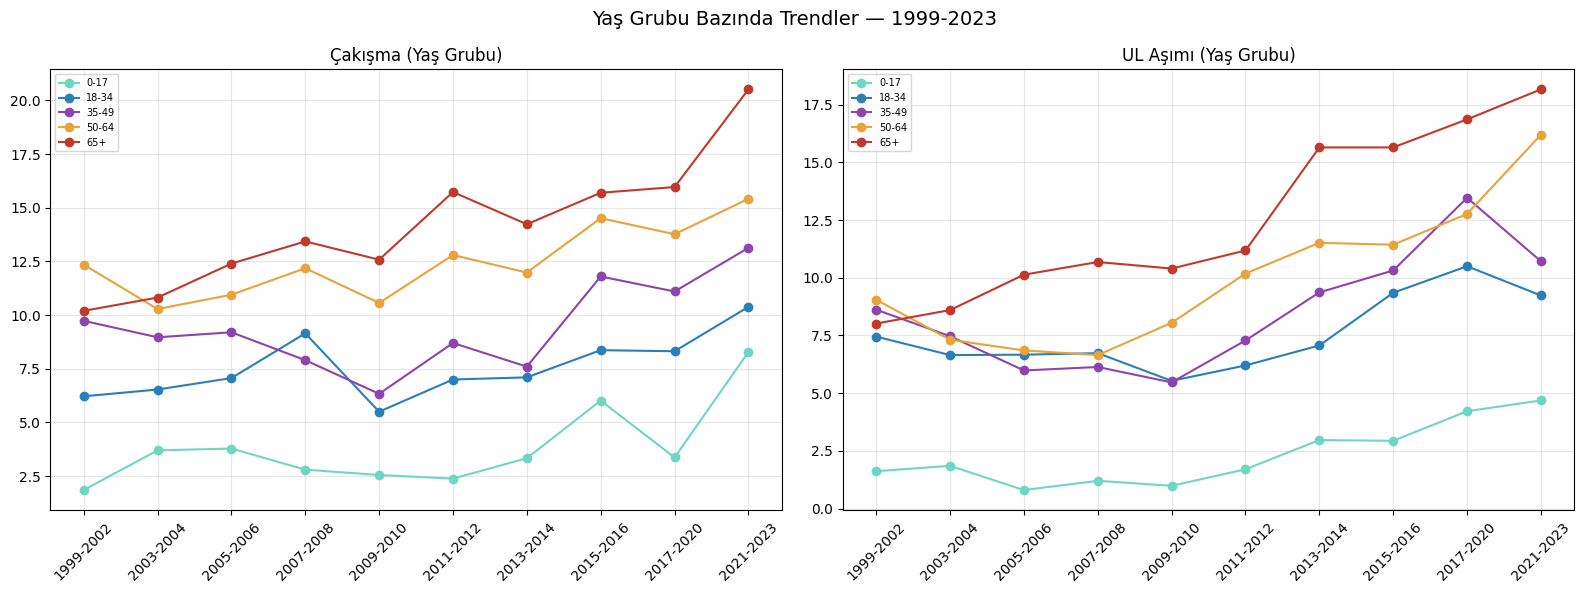

In [ ]:
# By age group: overlap and UL exceedance trends, all ten cycle blocks

from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt

client = bigquery.Client(project='dose-of-reality-506713')
CYCLE_ORDER = ['1999-2002', '2003-2004', '2005-2006', '2007-2008', '2009-2010',
               '2011-2012', '2013-2014', '2015-2016', '2017-2020', '2021-2023']
AGE_ORDER = ['0-17', '18-34', '35-49', '50-64', '65+']
INGREDIENTS = ['VITAMIN D', 'IRON', 'MAGNESIUM', 'NIACIN', 'ZINC', 'VITAMIN A']

AGE_CASE = "case when d.age_years < 18 then '0-17' when d.age_years < 35 then '18-34' when d.age_years < 50 then '35-49' when d.age_years < 65 then '50-64' else '65+' end"

query_overlap = f"""
select cycle, age_group, ingredient_name,
    round(sum(case when has_overlap then interview_weight else 0 end) / sum(interview_weight) * 100, 1) as cakisma_yuzdesi
from (
    select i.cycle, i.seqn, i.ingredient_name, {AGE_CASE} as age_group, d.interview_weight,
        count(distinct i.dspi_product_id) > 1 as has_overlap
    from `dose-of-reality-506713.nhanes_dbt.int_supplement_ingredients_all_cycles` i
    left join `dose-of-reality-506713.nhanes_dbt.int_demo_all_cycles` d on i.seqn=d.seqn and i.cycle=d.cycle
    where i.ingredient_name in unnest(@ingredients)
    group by i.cycle, i.seqn, i.ingredient_name, age_group, d.interview_weight
)
group by cycle, age_group, ingredient_name
"""

query_ul = f"""
with aggregated as (
    select u.seqn, u.cycle, u.ingredient_name, u.has_ul_defined,
        sum(case when u.unit_convertible then u.quantity_mcg else 0 end) as total_quantity_mcg,
        any_value(u.ul_value_mcg) as ul_value_mcg
    from `dose-of-reality-506713.nhanes_dbt.int_ingredients_with_ul_all_cycles` u
    where u.ingredient_name in unnest(@ingredients)
    group by u.seqn, u.cycle, u.ingredient_name, u.has_ul_defined
),
with_demo as (
    select a.*, {AGE_CASE} as age_group, d.interview_weight
    from aggregated a
    left join `dose-of-reality-506713.nhanes_dbt.int_demo_all_cycles` d on a.seqn=d.seqn and a.cycle=d.cycle
)
select cycle, age_group, ingredient_name,
    round(sum(case when total_quantity_mcg > ul_value_mcg then interview_weight else 0 end) / sum(interview_weight) * 100, 1) as asim_yuzdesi
from with_demo
where has_ul_defined
group by cycle, age_group, ingredient_name
"""

job_config = bigquery.QueryJobConfig(query_parameters=[bigquery.ArrayQueryParameter("ingredients", "STRING", INGREDIENTS)])
df_overlap = client.query(query_overlap, job_config=job_config).to_dataframe()
df_ul = client.query(query_ul, job_config=job_config).to_dataframe()

print("=== Overlap by age group (mean across the six ingredients) ===")
ov_avg = df_overlap.groupby(['cycle','age_group'])['cakisma_yuzdesi'].mean().reset_index()
pivot_ov = ov_avg.pivot(index='cycle', columns='age_group', values='cakisma_yuzdesi').reindex(CYCLE_ORDER)[AGE_ORDER]
print(pivot_ov.round(1))

print("\n=== UL exceedance by age group (mean across the six ingredients) ===")
ul_avg = df_ul.groupby(['cycle','age_group'])['asim_yuzdesi'].mean().reset_index()
pivot_ul = ul_avg.pivot(index='cycle', columns='age_group', values='asim_yuzdesi').reindex(CYCLE_ORDER)[AGE_ORDER]
print(pivot_ul.round(1))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = ['#6FD6C4', '#2980B9', '#8E44AD', '#E8A33D', '#C0392B']
for age, color in zip(AGE_ORDER, colors):
    axes[0].plot(pivot_ov.index, pivot_ov[age], marker='o', label=age, color=color)
    axes[1].plot(pivot_ul.index, pivot_ul[age], marker='o', label=age, color=color)
axes[0].set_title('Overlap')
axes[0].legend(fontsize=7)
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)
axes[1].set_title('UL exceedance')
axes[1].legend(fontsize=7)
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)
fig.suptitle('Trends by age group, 1999-2023', fontsize=14)
plt.tight_layout()
plt.show()

          cakismali_asim                         tek_urun_asim              \
age_group           0-17 18-34 35-49 50-64   65+          0-17 18-34 35-49   
cycle                                                                        
1999-2002            0.5   2.2   3.3   4.6   4.0           1.1   5.3   5.5   
2003-2004            1.0   2.3   3.7   3.0   4.0           0.8   4.4   3.8   
2005-2006            0.5   2.4   2.4   3.8   5.0           0.3   4.4   3.7   
2007-2008            0.4   3.4   2.7   3.8   4.8           0.7   3.2   3.3   
2009-2010            0.4   1.7   2.0   3.4   4.8           0.5   3.7   3.4   
2011-2012            0.6   2.5   3.0   6.0   6.5           0.6   3.8   4.0   
2013-2014            0.8   2.4   4.1   6.5   8.5           1.3   4.7   5.5   
2015-2016            1.0   3.9   5.6   6.2  10.0           1.1   5.3   4.9   
2017-2020            0.5   3.5   5.8   8.1  10.8           1.4   6.1   7.5   
2021-2023            2.0   5.0   7.0  10.0  13.4           1.8  

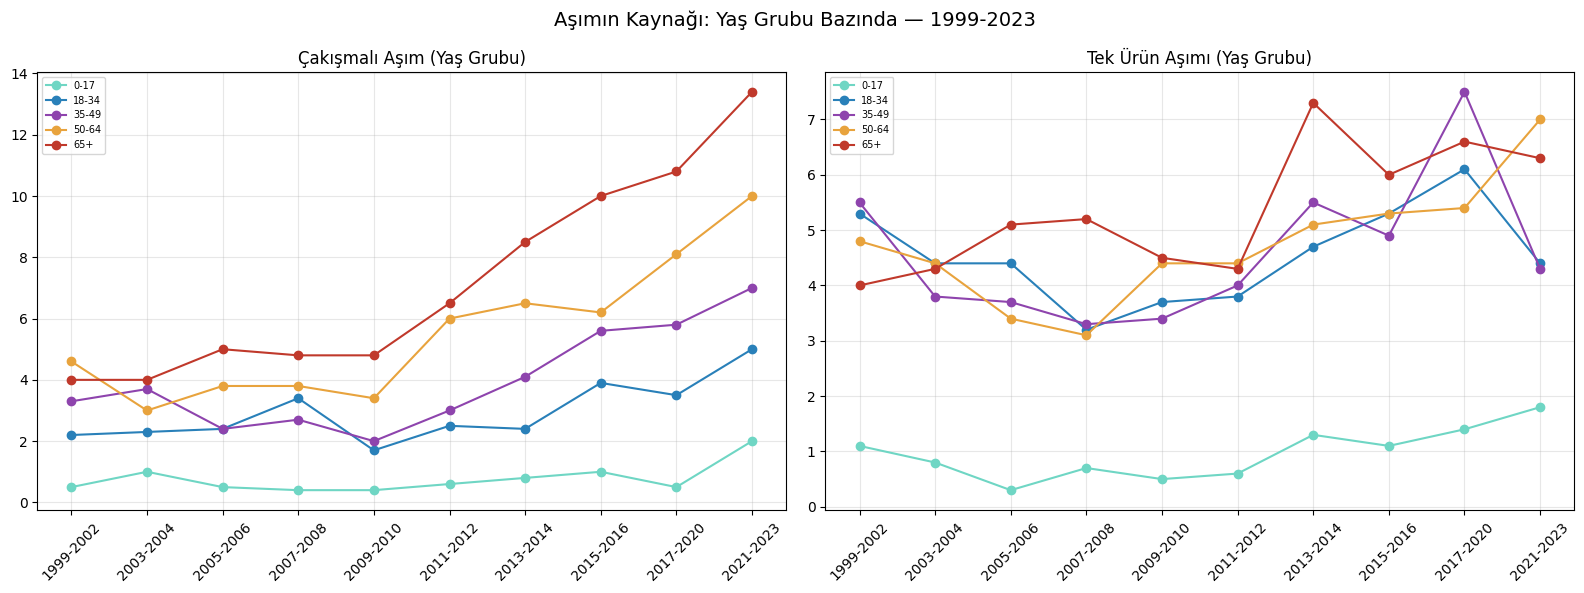

In [ ]:
# By age group: source of exceedance (overlap-driven vs single-product), all ten cycle blocks

from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt

client = bigquery.Client(project='dose-of-reality-506713')
CYCLE_ORDER = ['1999-2002', '2003-2004', '2005-2006', '2007-2008', '2009-2010',
               '2011-2012', '2013-2014', '2015-2016', '2017-2020', '2021-2023']
AGE_ORDER = ['0-17', '18-34', '35-49', '50-64', '65+']
INGREDIENTS = ['VITAMIN D', 'IRON', 'MAGNESIUM', 'NIACIN', 'ZINC', 'VITAMIN A']

AGE_CASE = "case when d.age_years < 18 then '0-17' when d.age_years < 35 then '18-34' when d.age_years < 50 then '35-49' when d.age_years < 65 then '50-64' else '65+' end"

query = f"""
with overlap_flag as (
    select cycle, seqn, ingredient_name,
        count(distinct dspi_product_id) > 1 as has_overlap
    from `dose-of-reality-506713.nhanes_dbt.int_supplement_ingredients_all_cycles`
    where ingredient_name in unnest(@ingredients)
    group by cycle, seqn, ingredient_name
),
exceeds_flag as (
    select seqn, cycle, ingredient_name, has_ul_defined,
        sum(case when unit_convertible then quantity_mcg else 0 end) as total_quantity_mcg,
        any_value(ul_value_mcg) as ul_value_mcg
    from `dose-of-reality-506713.nhanes_dbt.int_ingredients_with_ul_all_cycles`
    where ingredient_name in unnest(@ingredients)
    group by seqn, cycle, ingredient_name, has_ul_defined
),
combined as (
    select o.cycle, o.seqn, o.ingredient_name, o.has_overlap,
        case when e.has_ul_defined and e.total_quantity_mcg > e.ul_value_mcg then true
             when e.has_ul_defined then false else null end as exceeds_ul,
        {AGE_CASE} as age_group, d.interview_weight
    from overlap_flag o
    left join exceeds_flag e on o.cycle=e.cycle and o.seqn=e.seqn and o.ingredient_name=e.ingredient_name
    left join `dose-of-reality-506713.nhanes_dbt.int_demo_all_cycles` d on o.cycle=d.cycle and o.seqn=d.seqn
    where e.has_ul_defined
)
select cycle, age_group,
    round(sum(case when has_overlap and exceeds_ul then interview_weight else 0 end) / sum(interview_weight) * 100, 1) as overlap_driven_pct,
    round(sum(case when not has_overlap and exceeds_ul then interview_weight else 0 end) / sum(interview_weight) * 100, 1) as single_product_pct
from combined
group by cycle, age_group
"""

job_config = bigquery.QueryJobConfig(query_parameters=[bigquery.ArrayQueryParameter("ingredients", "STRING", INGREDIENTS)])
df = client.query(query, job_config=job_config).to_dataframe()
df['cycle'] = pd.Categorical(df['cycle'], categories=CYCLE_ORDER, ordered=True)
df = df.sort_values('cycle')

print(df.pivot(index='cycle', columns='age_group', values=['overlap_driven_pct','single_product_pct'])[
    [('overlap_driven_pct', a) for a in AGE_ORDER] + [('single_product_pct', a) for a in AGE_ORDER]
])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = ['#6FD6C4', '#2980B9', '#8E44AD', '#E8A33D', '#C0392B']
for age, color in zip(AGE_ORDER, colors):
    sub = df[df['age_group']==age]
    axes[0].plot(sub['cycle'], sub['overlap_driven_pct'], marker='o', label=age, color=color)
    axes[1].plot(sub['cycle'], sub['single_product_pct'], marker='o', label=age, color=color)
axes[0].set_title('Overlap-driven exceedance')
axes[0].legend(fontsize=7)
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)
axes[1].set_title('Single-product exceedance')
axes[1].legend(fontsize=7)
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)
fig.suptitle('Source of exceedance by age group, 1999-2023', fontsize=14)
plt.tight_layout()
plt.show()

### Findings: predictable for overlap, unpredictable for single-product dose

**Overall usage** rises monotonically with age in every cycle:

| Cycle | 0–17 | 18–34 | 35–49 | 50–64 | 65+ |
|---|---|---|---|---|---|
| 1999–2002 | 34.2 | 45.4 | 59.4 | 65.9 | 68.9 |
| 2017–2020 | 37.0 | 47.3 | 61.4 | 71.4 | 81.5 |
| 2021–2023 | 17.1 | 26.2 | 36.0 | 45.5 | 53.8 |

The 65+ group is the most resilient to the 2021–2023 break in relative terms (−34%, against −54% for
0–17) — consistent with older adults treating supplements as chronic health management rather than
discretionary.

**Overlap and exceedance** — the clean age gradient is more recent than it looks. In 1999–2002 the
ordering was not monotonic (50–64 exceeded 65+ on overlap, 12.4% vs 10.2%; 35–49 exceeded 65+ on
exceedance, 8.6% vs 8.0%). **The monotonic pattern only settles from around 2011–2012**, plausibly as
supplement products aimed at older adults proliferated. By 2021–2023 the ordering is unambiguous: 65+
leads on both (20.5% overlap, 18.2% exceedance).

**Source of exceedance — the interesting asymmetry.** The overlap component grows steadily and keeps
its age ordering (65+: 4.0 → 13.4, ≈3.3× over 24 years). The single-product component does not even
hold its ordering:

- 1999–2002: 65+ (4.0) **<** 50–64 (4.8)
- 2013–2014: 65+ (7.3) **>** 50–64 (5.1)
- 2021–2023: 65+ (6.3) **<** 50–64 (7.0)

**Reading:** multi-product behaviour follows a predictable age structure. Single-product dosing does
not — it fluctuates cycle to cycle without a stable age pattern. Practically, "watch for overlap"
messaging can be age-targeted; "check the dose on the label" has to go to everyone equally.

**Iron is the exception again.** Where every other ingredient peaks at 65+, iron peaks in the
**35–64 range** and then falls (overlap 13.5% at 35–49 vs 8.0% at 65+). That anomaly is worth its own
section.

<a id="iron-deep"></a>
## 20. Iron and vitamin D: a targeted sex × age deep dive

Iron's mid-life hump has an obvious candidate explanation: menstruation and perimenopause raise iron
requirements before roughly 50 and lower them after, so a hump peaking at 35–64 could be a female
physiological signal.

This is a **targeted spot-check on 2021–2023 only**, for these two ingredients — not part of the
systematic all-cycles architecture. Before interpreting anything, the cell sizes have to be checked.

In [ ]:
# Cell sizes for the same sex x age split -
# check raw (unweighted) person counts before interpreting anything

from google.cloud import bigquery
import pandas as pd

client = bigquery.Client(project='dose-of-reality-506713')
AGE_ORDER = ['0-17', '18-34', '35-49', '50-64', '65+']

query = """
with aggregated as (
    select
        u.seqn, u.ingredient_name, u.has_ul_defined,
        sum(case when u.unit_convertible then u.quantity_mcg else 0 end) as total_quantity_mcg,
        any_value(u.ul_value_mcg) as ul_value_mcg
    from `dose-of-reality-506713.nhanes_dbt.int_ingredients_with_ul_all_cycles` u
    where u.cycle = '2021-2023' and u.ingredient_name in ('IRON', 'VITAMIN D')
    group by u.seqn, u.ingredient_name, u.has_ul_defined
),

combined as (
    select
        a.seqn, a.ingredient_name,
        case
            when a.has_ul_defined and a.total_quantity_mcg > a.ul_value_mcg then true
            when a.has_ul_defined then false
            else null
        end as exceeds_ul,
        d.gender,
        case
            when d.age_years < 18 then '0-17'
            when d.age_years < 35 then '18-34'
            when d.age_years < 50 then '35-49'
            when d.age_years < 65 then '50-64'
            else '65+'
        end as age_group
    from aggregated a
    left join `dose-of-reality-506713.nhanes_dbt.int_demo_all_cycles` d
        on a.seqn = d.seqn and d.cycle = '2021-2023'
    where a.has_ul_defined
)

select
    ingredient_name,
    gender,
    age_group,
    count(*) as toplam_kisi_ham,
    countif(exceeds_ul) as asim_kisi_ham
from combined
group by ingredient_name, gender, age_group
order by ingredient_name, gender, age_group
"""

df = client.query(query).to_dataframe()

for ing in ['IRON', 'VITAMIN D']:
    print(f"\n=== {ing} - cell sizes (raw person counts) ===")
    sub = df[df['ingredient_name'] == ing]
    pivot_n = sub.pivot(index='age_group', columns='gender', values='toplam_kisi_ham').reindex(AGE_ORDER)
    pivot_exceeds = sub.pivot(index='age_group', columns='gender', values='asim_kisi_ham').reindex(AGE_ORDER)
    print("People in cell:")
    print(pivot_n)
    print("\nExceedance events:")
    print(pivot_exceeds)


=== IRON - Ornek Buyuklugu (Ham Kisi Sayisi) ===
Toplam kişi:
gender     Female  Male
age_group              
0-17           61    52
18-34         105    27
35-49         130    47
50-64         184    56
65+           255   136

Aşım yaşayan kişi:
gender     Female  Male
age_group              
0-17           10     3
18-34          18     0
35-49          18     4
50-64          32    16
65+            43    25

=== VITAMIN D - Ornek Buyuklugu (Ham Kisi Sayisi) ===
Toplam kişi:
gender     Female  Male
age_group              
0-17          222   269
18-34         196   100
35-49         248   135
50-64         477   260
65+           665   445

Aşım yaşayan kişi:
gender     Female  Male
age_group              
0-17           19    12
18-34          35    26
35-49          75    23
50-64         178    76
65+           256   133



=== IRON - UL Aşım Yüzdesi (Cinsiyet x Yaş) ===
gender     Female  Male
age_group              
0-17         14.0  10.1
18-34        23.0   0.0
35-49        14.5   8.3
50-64        19.3  32.0
65+          16.8  18.7


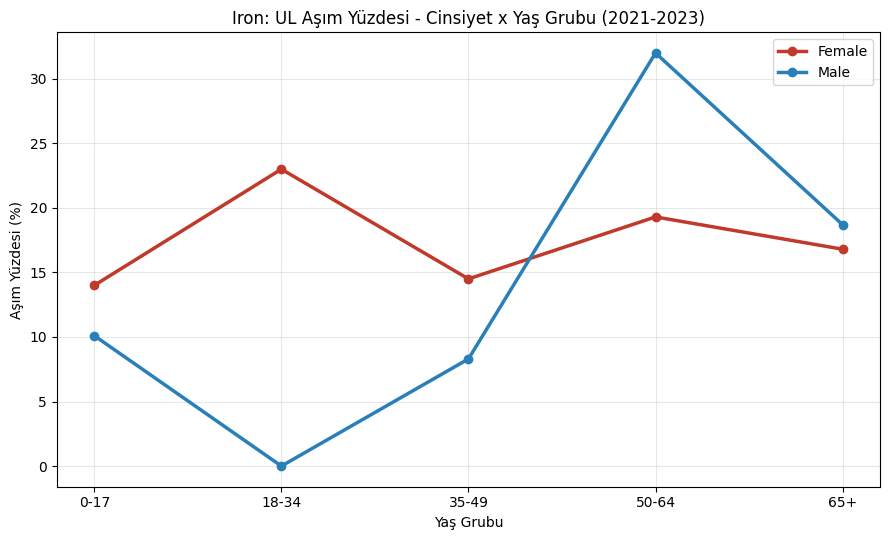


=== VITAMIN D - UL Aşım Yüzdesi (Cinsiyet x Yaş) ===
gender     Female  Male
age_group              
0-17         10.1   4.4
18-34        17.0  24.9
35-49        30.5  16.5
50-64        37.3  28.6
65+          39.2  29.5


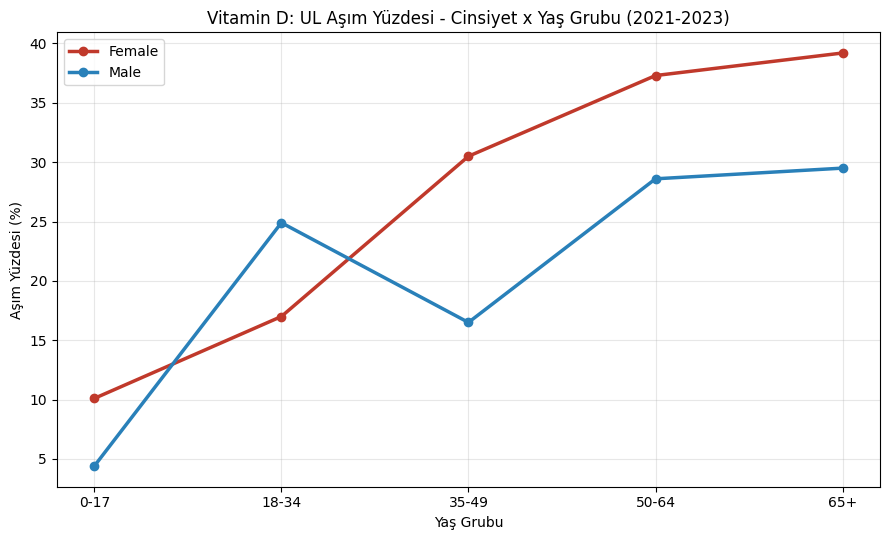

In [ ]:
# Iron and vitamin D: sex x age cross-analysis
# (Testing the menopause hypothesis: is the mid-life hump female-only?)

from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt

client = bigquery.Client(project='dose-of-reality-506713')
AGE_ORDER = ['0-17', '18-34', '35-49', '50-64', '65+']

query = """
with aggregated as (
    select
        u.seqn, u.ingredient_name, u.has_ul_defined,
        sum(case when u.unit_convertible then u.quantity_mcg else 0 end) as total_quantity_mcg,
        any_value(u.ul_value_mcg) as ul_value_mcg
    from `dose-of-reality-506713.nhanes_dbt.int_ingredients_with_ul_all_cycles` u
    where u.cycle = '2021-2023' and u.ingredient_name in ('IRON', 'VITAMIN D')
    group by u.seqn, u.ingredient_name, u.has_ul_defined
),

overlap_flag as (
    select
        seqn, ingredient_name,
        count(distinct dspi_product_id) > 1 as has_overlap
    from `dose-of-reality-506713.nhanes_dbt.int_supplement_ingredients_all_cycles`
    where cycle = '2021-2023' and ingredient_name in ('IRON', 'VITAMIN D')
    group by seqn, ingredient_name
),

combined as (
    select
        a.seqn, a.ingredient_name,
        case
            when a.has_ul_defined and a.total_quantity_mcg > a.ul_value_mcg then true
            when a.has_ul_defined then false
            else null
        end as exceeds_ul,
        o.has_overlap,
        d.gender,
        case
            when d.age_years < 18 then '0-17'
            when d.age_years < 35 then '18-34'
            when d.age_years < 50 then '35-49'
            when d.age_years < 65 then '50-64'
            else '65+'
        end as age_group,
        d.interview_weight
    from aggregated a
    left join overlap_flag o on a.seqn = o.seqn and a.ingredient_name = o.ingredient_name
    left join `dose-of-reality-506713.nhanes_dbt.int_demo_all_cycles` d
        on a.seqn = d.seqn and d.cycle = '2021-2023'
    where a.has_ul_defined
)

select
    ingredient_name,
    gender,
    age_group,
    round(sum(case when exceeds_ul then interview_weight else 0 end) / sum(interview_weight) * 100, 1) as asim_yuzdesi,
    round(sum(case when has_overlap then interview_weight else 0 end) / sum(interview_weight) * 100, 1) as cakisma_yuzdesi
from combined
group by ingredient_name, gender, age_group
"""

df = client.query(query).to_dataframe()

for ing in ['IRON', 'VITAMIN D']:
    print(f"\n=== {ing} - UL exceedance % by sex x age ===")
    sub = df[df['ingredient_name'] == ing]
    pivot = sub.pivot(index='age_group', columns='gender', values='asim_yuzdesi').reindex(AGE_ORDER)
    print(pivot)

    fig, ax = plt.subplots(figsize=(9, 5.5))
    ax.plot(AGE_ORDER, pivot['Female'], marker='o', label='Female', color='#C0392B', linewidth=2.5)
    ax.plot(AGE_ORDER, pivot['Male'], marker='o', label='Male', color='#2980B9', linewidth=2.5)
    ax.set_title(f'{ing.title()}: UL exceedance % by sex and age group (2021-2023)')
    ax.set_ylabel('Exceedance (%)')
    ax.set_xlabel('Age group')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

### Sample sizes first — one cell is not usable

Splitting by sex × age shrinks several cells hard. Iron / Male / 18–34 contains **27 people** with
**zero** exceedance events. That is not evidence the true rate is 0%; it means a rare event may simply
not have been observed in a sample that small. That cell is treated as unreliable and excluded from
interpretation.

### Findings, from adequately-powered cells only

**Vitamin D — hypothesis supported.** For women, exceedance jumps sharply from 18–34 (n = 196, 17.9%)
to 35–49 (n = 248, 30.2%); both cells are well powered. For men the same transition goes the *other*
way (26.0% → 17.0%). Movement in opposite directions by sex is what a female-specific physiological
driver would look like — plausibly increased vitamin D use around perimenopause for bone health.

**Iron — hypothesis not supported.** In the adequately-powered female cells (18–34: n = 105;
35–49: n = 130), exceedance *falls* at 35–49 (17.1% → 13.8%) — the **opposite** of the premenopausal
increase the hypothesis predicts. The apparent male hump traces back to the unreliable n = 27 cell.

**So the visible iron hump is not explained by menopause**, at least not in this cycle. It is a real
pattern in the aggregate data whose driver remains unidentified. [§23](#failed-test) attempts a formal
test of a related hypothesis, with an instructive result.

<a id="ethnicity"></a>
## 21. Race and ethnicity

Using `RIDRETH1`, the only race/ethnicity coding available across all ten cycles. As noted in
[§3](#codebook), this folds Non-Hispanic Asian into "Other Race" — a real limitation of the 24-year
view.

=== Kişi Sayısı ===
ethnicity_v1  Mexican American  Other Hispanic  Non-Hispanic White  \
cycle                                                                
1999-2002                 6169            1106                7973   
2003-2004                 2519             341                4133   
2005-2006                 2847             349                3928   
2007-2008                 2157            1201                4115   
2009-2010                 2384            1133                4420   
2011-2012                 1355            1076                2973   
2013-2014                 1730             960                3674   
2015-2016                 1921            1308                3066   
2017-2020                 1990            1544                5271   
2021-2023                 1117            1373                6217   

ethnicity_v1  Non-Hispanic Black  Other Race (incl. Multiracial)  
cycle                                                             
1999-

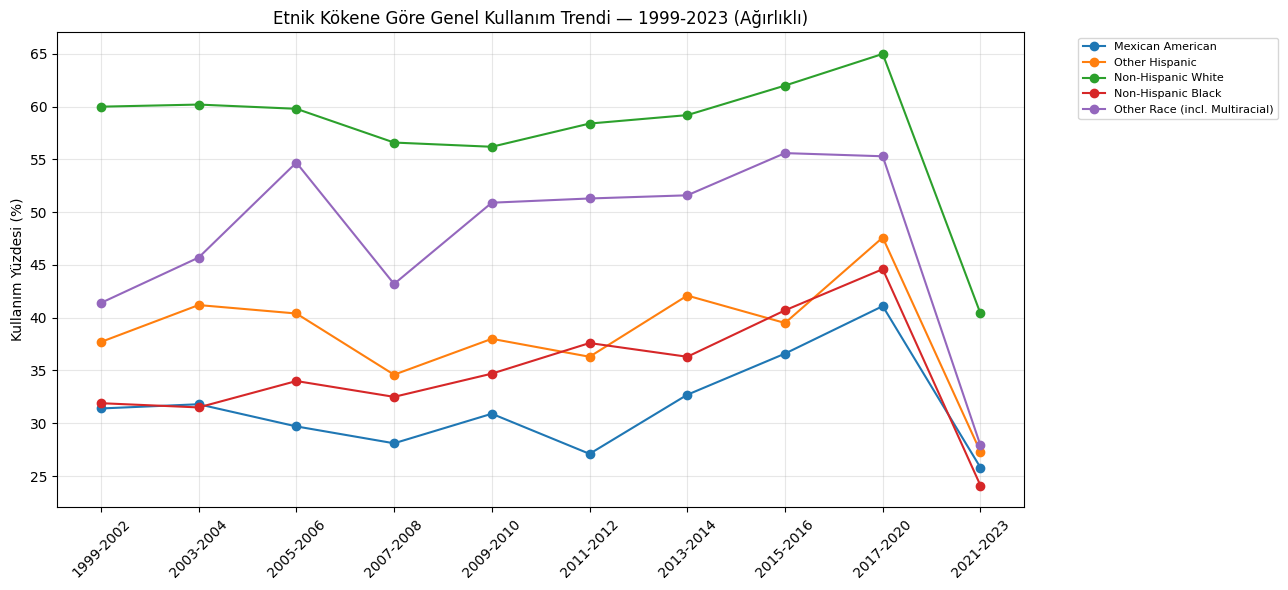

In [ ]:
# Overall usage trend by race/ethnicity, all ten cycle blocks (1999-2023)

from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt

client = bigquery.Client(project='dose-of-reality-506713')
CYCLE_ORDER = ['1999-2002', '2003-2004', '2005-2006', '2007-2008', '2009-2010',
               '2011-2012', '2013-2014', '2015-2016', '2017-2020', '2021-2023']
ETH_ORDER = ['Mexican American', 'Other Hispanic', 'Non-Hispanic White',
             'Non-Hispanic Black', 'Other Race (incl. Multiracial)']

query = """
with usage_per_person as (
    select
        d.seqn, d.cycle, d.ethnicity_v1, d.interview_weight,
        count(distinct i.raw_product_id) as n_products_used
    from `dose-of-reality-506713.nhanes_dbt.int_demo_all_cycles` as d
    left join `dose-of-reality-506713.nhanes_dbt.int_dsqids_all_cycles` as i
        on d.seqn = i.seqn and d.cycle = i.cycle
    group by d.seqn, d.cycle, d.ethnicity_v1, d.interview_weight
)
select
    cycle, ethnicity_v1,
    count(*) as n_kisi,
    round(sum(case when n_products_used > 0 then interview_weight else 0 end)
          / sum(interview_weight) * 100, 1) as kullanim_yuzdesi
from usage_per_person
group by cycle, ethnicity_v1
"""

df = client.query(query).to_dataframe()
pivot = df.pivot(index='cycle', columns='ethnicity_v1', values='kullanim_yuzdesi').reindex(CYCLE_ORDER)[ETH_ORDER]
pivot_n = df.pivot(index='cycle', columns='ethnicity_v1', values='n_kisi').reindex(CYCLE_ORDER)[ETH_ORDER]

print("=== Person counts ===")
print(pivot_n)
print("\n=== Usage % (survey-weighted) ===")
print(pivot)

fig, ax = plt.subplots(figsize=(13, 6))
for eth in ETH_ORDER:
    ax.plot(pivot.index, pivot[eth], marker='o', label=eth)
ax.set_title('Supplement use by race/ethnicity, 1999-2023 (survey-weighted)')
ax.set_ylabel('Usage (%)')
ax.legend(fontsize=8, bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

=== CAKISMA - Etnik Köken (6 Ingredient Ortalamasi) ===
ethnicity_v1  Mexican American  Other Hispanic  Non-Hispanic White  \
cycle                                                                
1999-2002                  5.5             6.1                 8.9   
2003-2004                  6.1             7.6                 8.9   
2005-2006                  4.8             7.0                 9.4   
2007-2008                  5.9             6.4                10.2   
2009-2010                  6.7             4.6                 8.5   
2011-2012                  7.4             8.1                10.7   
2013-2014                  5.6             9.4                10.0   
2015-2016                  8.2             9.4                13.4   
2017-2020                  9.7            10.7                12.4   
2021-2023                 15.6            10.0                15.7   

ethnicity_v1  Non-Hispanic Black  Other Race (incl. Multiracial)  
cycle                               

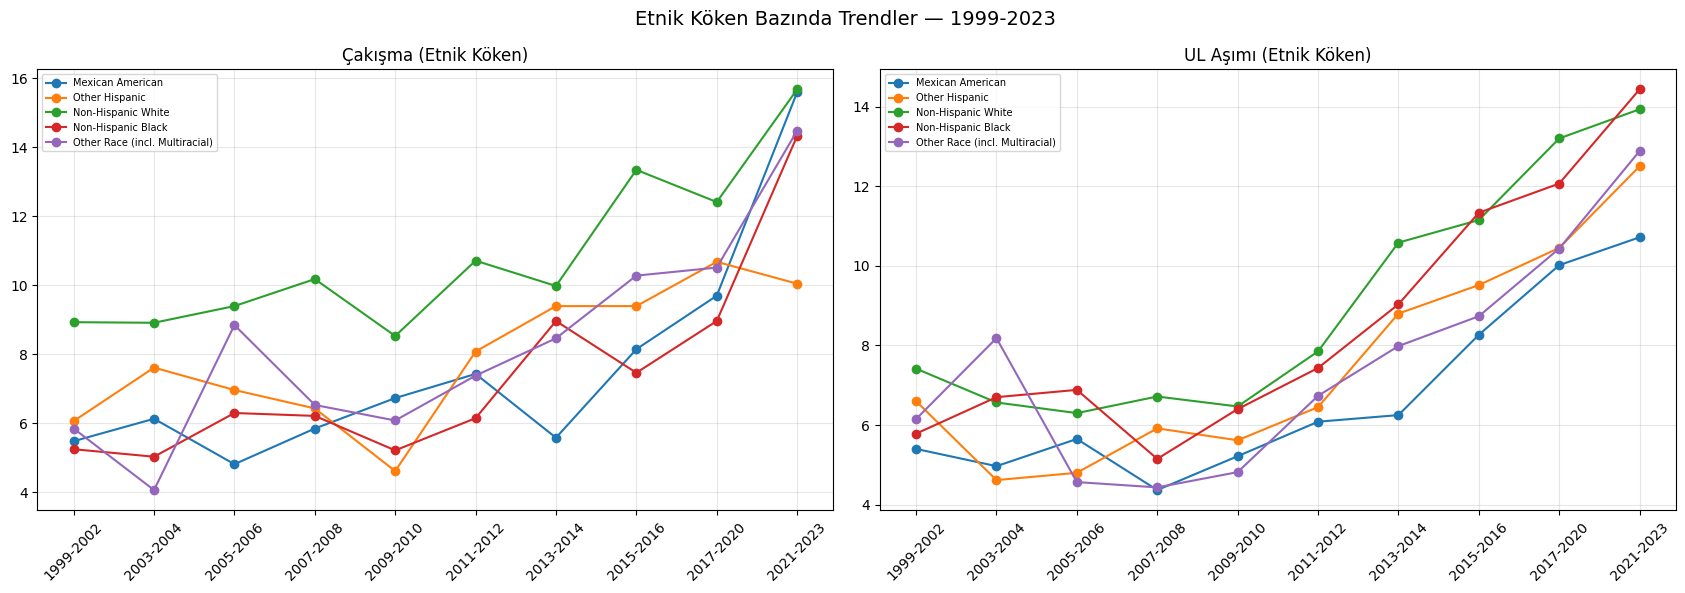

In [ ]:
# By race/ethnicity: overlap and UL exceedance trends, all ten cycle blocks

from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt

client = bigquery.Client(project='dose-of-reality-506713')
CYCLE_ORDER = ['1999-2002', '2003-2004', '2005-2006', '2007-2008', '2009-2010',
               '2011-2012', '2013-2014', '2015-2016', '2017-2020', '2021-2023']
ETH_ORDER = ['Mexican American', 'Other Hispanic', 'Non-Hispanic White',
             'Non-Hispanic Black', 'Other Race (incl. Multiracial)']
INGREDIENTS = ['VITAMIN D', 'IRON', 'MAGNESIUM', 'NIACIN', 'ZINC', 'VITAMIN A']

query_overlap = """
select cycle, ethnicity_v1, ingredient_name,
    round(sum(case when has_overlap then interview_weight else 0 end) / sum(interview_weight) * 100, 1) as cakisma_yuzdesi
from (
    select i.cycle, i.seqn, i.ingredient_name, d.ethnicity_v1, d.interview_weight,
        count(distinct i.dspi_product_id) > 1 as has_overlap
    from `dose-of-reality-506713.nhanes_dbt.int_supplement_ingredients_all_cycles` i
    left join `dose-of-reality-506713.nhanes_dbt.int_demo_all_cycles` d on i.seqn=d.seqn and i.cycle=d.cycle
    where i.ingredient_name in unnest(@ingredients)
    group by i.cycle, i.seqn, i.ingredient_name, d.ethnicity_v1, d.interview_weight
)
group by cycle, ethnicity_v1, ingredient_name
"""

query_ul = """
with aggregated as (
    select u.seqn, u.cycle, u.ingredient_name, u.has_ul_defined,
        sum(case when u.unit_convertible then u.quantity_mcg else 0 end) as total_quantity_mcg,
        any_value(u.ul_value_mcg) as ul_value_mcg
    from `dose-of-reality-506713.nhanes_dbt.int_ingredients_with_ul_all_cycles` u
    where u.ingredient_name in unnest(@ingredients)
    group by u.seqn, u.cycle, u.ingredient_name, u.has_ul_defined
),
with_demo as (
    select a.*, d.ethnicity_v1, d.interview_weight
    from aggregated a
    left join `dose-of-reality-506713.nhanes_dbt.int_demo_all_cycles` d on a.seqn=d.seqn and a.cycle=d.cycle
)
select cycle, ethnicity_v1, ingredient_name,
    round(sum(case when total_quantity_mcg > ul_value_mcg then interview_weight else 0 end) / sum(interview_weight) * 100, 1) as asim_yuzdesi
from with_demo
where has_ul_defined
group by cycle, ethnicity_v1, ingredient_name
"""

job_config = bigquery.QueryJobConfig(query_parameters=[bigquery.ArrayQueryParameter("ingredients", "STRING", INGREDIENTS)])
df_overlap = client.query(query_overlap, job_config=job_config).to_dataframe()
df_ul = client.query(query_ul, job_config=job_config).to_dataframe()

print("=== Overlap by race/ethnicity (mean across the six ingredients) ===")
ov_avg = df_overlap.groupby(['cycle','ethnicity_v1'])['cakisma_yuzdesi'].mean().reset_index()
pivot_ov = ov_avg.pivot(index='cycle', columns='ethnicity_v1', values='cakisma_yuzdesi').reindex(CYCLE_ORDER)[ETH_ORDER]
print(pivot_ov.round(1))

print("\n=== UL exceedance by race/ethnicity (mean across the six ingredients) ===")
ul_avg = df_ul.groupby(['cycle','ethnicity_v1'])['asim_yuzdesi'].mean().reset_index()
pivot_ul = ul_avg.pivot(index='cycle', columns='ethnicity_v1', values='asim_yuzdesi').reindex(CYCLE_ORDER)[ETH_ORDER]
print(pivot_ul.round(1))

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
for eth in ETH_ORDER:
    axes[0].plot(pivot_ov.index, pivot_ov[eth], marker='o', label=eth)
    axes[1].plot(pivot_ul.index, pivot_ul[eth], marker='o', label=eth)
axes[0].set_title('Overlap')
axes[0].legend(fontsize=7)
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)
axes[1].set_title('UL exceedance')
axes[1].legend(fontsize=7)
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)
fig.suptitle('Trends by race/ethnicity, 1999-2023', fontsize=14)
plt.tight_layout()
plt.show()

               cakismali_asim                                    \
ethnicity_v1 Mexican American Other Hispanic Non-Hispanic White   
cycle                                                             
1999-2002                 2.0            2.0                3.2   
2003-2004                 1.8            2.7                3.1   
2005-2006                 1.8            2.3                3.0   
2007-2008                 1.8            2.4                3.4   
2009-2010                 2.2            1.5                2.8   
2011-2012                 2.7            1.8                4.3   
2013-2014                 2.0            4.1                5.3   
2015-2016                 2.8            4.6                6.5   
2017-2020                 3.9            4.9                7.3   
2021-2023                 6.7            5.8                9.7   

                                                                \
ethnicity_v1 Non-Hispanic Black Other Race (incl. Multiracial)

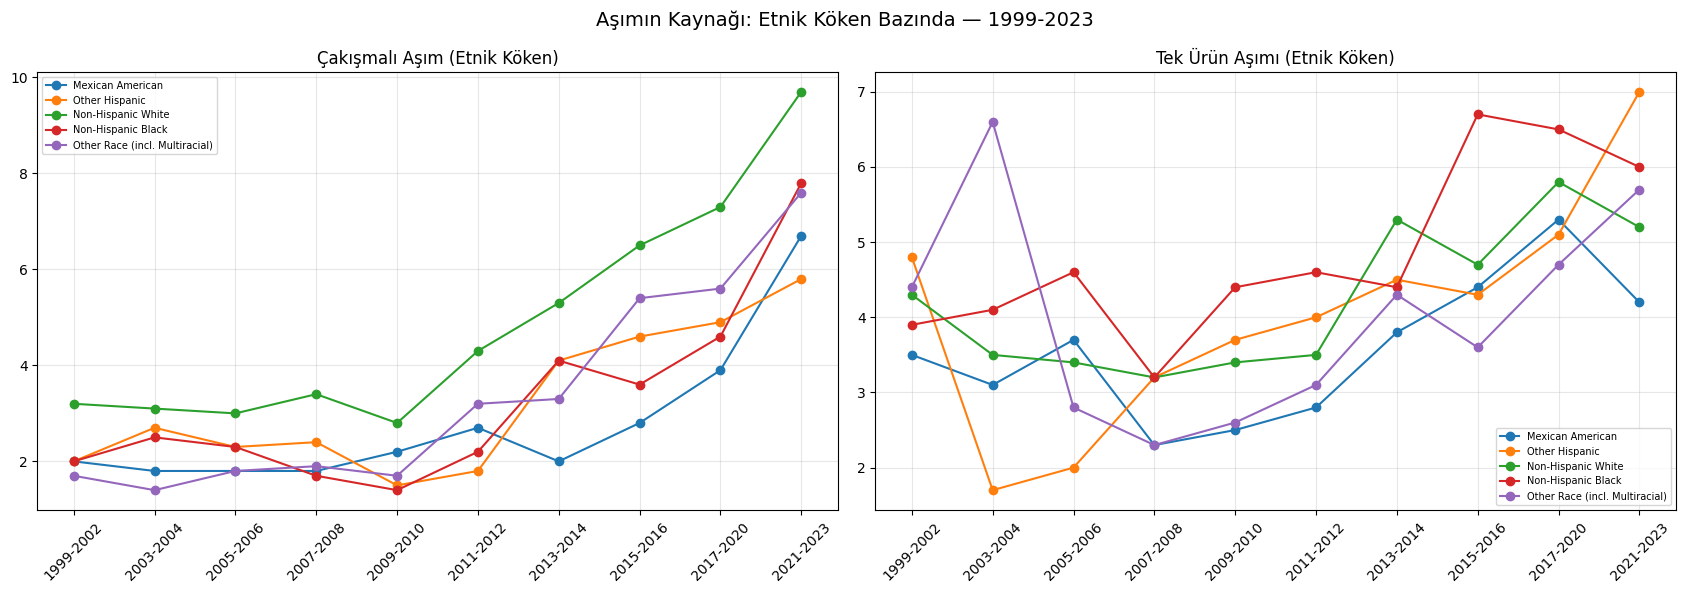

In [ ]:
# By race/ethnicity: source of exceedance (overlap-driven vs single-product), all ten cycle blocks

from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt

client = bigquery.Client(project='dose-of-reality-506713')
CYCLE_ORDER = ['1999-2002', '2003-2004', '2005-2006', '2007-2008', '2009-2010',
               '2011-2012', '2013-2014', '2015-2016', '2017-2020', '2021-2023']
ETH_ORDER = ['Mexican American', 'Other Hispanic', 'Non-Hispanic White',
             'Non-Hispanic Black', 'Other Race (incl. Multiracial)']
INGREDIENTS = ['VITAMIN D', 'IRON', 'MAGNESIUM', 'NIACIN', 'ZINC', 'VITAMIN A']

query = """
with overlap_flag as (
    select cycle, seqn, ingredient_name,
        count(distinct dspi_product_id) > 1 as has_overlap
    from `dose-of-reality-506713.nhanes_dbt.int_supplement_ingredients_all_cycles`
    where ingredient_name in unnest(@ingredients)
    group by cycle, seqn, ingredient_name
),
exceeds_flag as (
    select seqn, cycle, ingredient_name, has_ul_defined,
        sum(case when unit_convertible then quantity_mcg else 0 end) as total_quantity_mcg,
        any_value(ul_value_mcg) as ul_value_mcg
    from `dose-of-reality-506713.nhanes_dbt.int_ingredients_with_ul_all_cycles`
    where ingredient_name in unnest(@ingredients)
    group by seqn, cycle, ingredient_name, has_ul_defined
),
combined as (
    select o.cycle, o.seqn, o.ingredient_name, o.has_overlap,
        case when e.has_ul_defined and e.total_quantity_mcg > e.ul_value_mcg then true
             when e.has_ul_defined then false else null end as exceeds_ul,
        d.ethnicity_v1, d.interview_weight
    from overlap_flag o
    left join exceeds_flag e on o.cycle=e.cycle and o.seqn=e.seqn and o.ingredient_name=e.ingredient_name
    left join `dose-of-reality-506713.nhanes_dbt.int_demo_all_cycles` d on o.cycle=d.cycle and o.seqn=d.seqn
    where e.has_ul_defined
)
select cycle, ethnicity_v1,
    round(sum(case when has_overlap and exceeds_ul then interview_weight else 0 end) / sum(interview_weight) * 100, 1) as overlap_driven_pct,
    round(sum(case when not has_overlap and exceeds_ul then interview_weight else 0 end) / sum(interview_weight) * 100, 1) as single_product_pct
from combined
group by cycle, ethnicity_v1
"""

job_config = bigquery.QueryJobConfig(query_parameters=[bigquery.ArrayQueryParameter("ingredients", "STRING", INGREDIENTS)])
df = client.query(query, job_config=job_config).to_dataframe()
df['cycle'] = pd.Categorical(df['cycle'], categories=CYCLE_ORDER, ordered=True)
df = df.sort_values('cycle')

print(df.pivot(index='cycle', columns='ethnicity_v1', values=['overlap_driven_pct','single_product_pct'])[
    [('overlap_driven_pct', e) for e in ETH_ORDER] + [('single_product_pct', e) for e in ETH_ORDER]
])

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
for eth in ETH_ORDER:
    sub = df[df['ethnicity_v1']==eth]
    axes[0].plot(sub['cycle'], sub['overlap_driven_pct'], marker='o', label=eth)
    axes[1].plot(sub['cycle'], sub['single_product_pct'], marker='o', label=eth)
axes[0].set_title('Overlap-driven exceedance')
axes[0].legend(fontsize=7)
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)
axes[1].set_title('Single-product exceedance')
axes[1].legend(fontsize=7)
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)
fig.suptitle('Source of exceedance by race/ethnicity, 1999-2023', fontsize=14)
plt.tight_layout()
plt.show()

### Findings: the one demographic factor that is not stable over time

**Overall usage:**

| Cycle | Mexican American | Other Hispanic | NH White | NH Black | Other Race |
|---|---|---|---|---|---|
| 1999–2002 | 31.4 | 37.7 | 60.0 | 31.9 | 41.4 |
| 2017–2020 | 41.1 | 47.6 | 65.0 | 44.6 | 55.3 |
| 2021–2023 | 25.8 | 27.3 | 40.4 | 24.1 | 27.9 |

The early period is less ordered — in 2005–2006 "Other Race" (54.7%) came close to Non-Hispanic White
(59.8%). From 2011 the hierarchy stabilises with Non-Hispanic White consistently highest.

**Overlap:** Non-Hispanic White leads clearly and consistently (8.9 → 15.7), and the gap holds for
24 years.

**UL exceedance: the groups converge, then the ordering flips.**

| Cycle | NH White | NH Black |
|---|---|---|
| 1999–2002 | 7.4 | 5.8 |
| 2015–2016 | 11.2 | 11.3 |
| 2021–2023 | 13.9 | **14.4** |

**Source of the flip.** On the overlap component Non-Hispanic White is still clearly ahead
(9.7 vs 7.8), but on the **single-product** component Non-Hispanic Black overtakes (6.0 vs 5.2). The
single-product component is where the reversal comes from — and it is generally the noisier of the two
across all groups (Other Race, for instance, swings from 6.6% in 2003–2004 to 2.8% in 2005–2006).

**Reading:** unlike sex and age, which are structurally stable across 24 years, the race/ethnicity
effect is **dynamic**. Non-Hispanic Black respondents were consistently *below* Non-Hispanic White on
exceedance until 2015–2016 and are now above. A single-cycle analysis would report this as a fixed
characteristic of the population; the 24-year view shows it is a recent development that should keep
being monitored.

**Per-ingredient, the direction reverses.** In 2021–2023 iron exceedance among Non-Hispanic Black
respondents is **28.2%**, against 15–18% for every other group. But on magnesium, niacin and zinc it is
Non-Hispanic White that runs highest (zinc: 7.1% vs 3.6%). There is no single answer to "which group is
most at risk" — it depends entirely on the ingredient.

### Context for the iron finding: consistency with known anaemia prevalence

The iron result is not an isolated curiosity. On the **same NHANES 2021–2023 cycle**, CDC's own
published brief reports:

> "Among females, the prevalence of anemia in Black females (31.4%) was highest compared with Asian
> (15.9%), Hispanic (15.0%), and White (8.3%) females."
> — [CDC NCHS Data Brief No. 519, December 2024](https://www.cdc.gov/nchs/data/databriefs/db519.pdf)

Higher anaemia prevalence and higher iron-supplement exceedance in the same population, in the same
survey cycle, point in the same direction.

**Contributing factors suggested in the literature** (none established as a single cause):

1. **Heavy menstrual bleeding.** A study of premenopausal African-American women found 19% iron
   deficiency and 12% iron deficiency anaemia, linked to heavy menstrual bleeding — with higher uterine
   fibroid prevalence a known factor in this population. ([PMC4983800](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC4983800/))
2. **Socioeconomic factors.** Anaemia prevalence falls as income rises; structural inequities in
   nutrition and healthcare access plausibly contribute. (CDC NCHS Data Brief No. 519)
3. **Genuine scientific uncertainty.** The literature is explicit: *"specific causes of racial/ethnic
   disparities in anemia are not known."* ([PLOS One / PMC5112924](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5112924/))

**How this is framed in the project:** elevated iron exceedance among Non-Hispanic Black respondents
**coincides with a documented anaemia prevalence disparity**. This data cannot establish causation, and
no causal claim is made. A consistent overlap between two independent sources is reported as exactly
that.

**A note on cell size.** Within iron, the Non-Hispanic Black overlap-driven exceedance cell contains
n = 9 events out of 91. The *direction* is robust; the exact percentage should be read cautiously.

<a id="part5"></a>
<a id="stats"></a>
# Part V — Testing and quantifying

## 22. Design-based significance testing

Every difference reported in Part IV is a difference between weighted point estimates. Whether those
differences are distinguishable from sampling noise is a separate question — and answering it for
NHANES requires more than a standard chi-square.

### Why a naive test would be wrong

NHANES is stratified and clustered. Respondents within a PSU are correlated, so the effective sample
size is smaller than the row count. A test that ignores the design underestimates variance and returns
p-values that look **more** significant than they are.

The tests below use the [`svy`](https://svylab.com/docs/svy) package, which implements design-based
estimation (weights + strata + PSU) and is validated against R's `survey` package to six decimal
places.

**Two-group comparisons** (sex) use a design-based two-sample t-test. **Multi-group comparisons**
(age, race/ethnicity) use a design-based Kruskal-Wallis rank test, since `ttest()` handles two groups
only.

### The degrees-of-freedom tell

Single-cycle tests come back with **df = 14**, which looks alarmingly low. It is correct: the
2021–2023 design has 15 strata and 30 PSUs, and for a stratified + clustered design
df = n_PSU − n_strata − 1 = 14. That low df is the design being taken seriously. A test that ignored
it would report a much higher df and artificially stronger significance. Results that stay significant
under the conservative method are that much more trustworthy.

### First: a single cycle (2021–2023)

Sex, using a design-based two-sample t-test on person-level indicators.

In [ ]:
# Test 1 - effect of sex on overlap and UL exceedance
# Design-based two-sample t-test (weights + strata + PSU), 2021-2023 only

from google.cloud import bigquery
import pandas as pd
import svy

client = bigquery.Client(project='dose-of-reality-506713')

query = """
with joined as (
    select
        o.seqn,
        o.has_overlap,
        u.exceeds_ul,
        d.gender,
        d.interview_weight,
        d.survey_stratum,
        d.survey_psu
    from `dose-of-reality-506713.nhanes_dbt.mart_ingredient_overlap` o
    left join `dose-of-reality-506713.nhanes_dbt.mart_ul_comparison` u
        on o.seqn = u.seqn and o.ingredient_name = u.ingredient_name
    left join `dose-of-reality-506713.nhanes_dbt.stg_demo_l` d
        on o.seqn = d.seqn
),

person_level as (
    select
        seqn,
        any_value(gender) as gender,
        any_value(interview_weight) as interview_weight,
        any_value(survey_stratum) as survey_stratum,
        any_value(survey_psu) as survey_psu,
        logical_or(has_overlap) as any_overlap,
        logical_or(coalesce(exceeds_ul, false)) as any_exceeds
    from joined
    group by seqn
)

select * from person_level
"""

df = client.query(query).to_dataframe()

# Encode as 0/1
df['any_overlap'] = df['any_overlap'].astype(int)
df['any_exceeds'] = df['any_exceeds'].astype(int)

print("People:", len(df))
print(df.groupby('gender')[['any_overlap', 'any_exceeds']].mean())

# svy is Polars-based - convert the pandas frame
import polars as pl
df_pl = pl.from_pandas(df)

# Declare the survey design
design = svy.Design(
    stratum='survey_stratum',
    psu='survey_psu',
    wgt='interview_weight'
)
sample = svy.Sample(data=df_pl, design=design)
print("\n", sample)

# Sex x overlap
print("\n=== Sex x overlap rate ===")
test1 = sample.categorical.ttest(y='any_overlap', group='gender')
print(test1)

# Sex x UL exceedance
print("\n=== Sex x UL exceedance rate ===")
test2 = sample.categorical.ttest(y='any_exceeds', group='gender')
print(test2)

Toplam kişi: 3835
        any_overlap  any_exceeds
gender                          
Female     0.446847     0.387838
Male       0.351084     0.278638

 

╭─────────────── Sample ────────────────╮
│ Survey Data                           │
│   Rows     : 3835                     │
│   Columns  : 10                       │
│   Strata   : 15                       │
│   PSUs     : 30                       │
│                                       │
│ Survey Design                         │
│   Row index          svy_row_index    │
│   Stratum            survey_stratum   │
│   PSU                survey_psu       │
│   SSU                None             │
│   Weight             interview_weight │
│   With replacement   False            │
│   Prob               None             │
│   Hit                None             │
│   MOS                None             │
│   Population size    None             │
│   Replicate weights  None             │
╰───────────────────────────────────────╯



=== Test: Cinsiyete Gore Cakisma Orani ===


╭────────────────── T-Test: Two-sample (unpaired) ──────────────────╮
│ Y = 'any_overlap'                                                 │
│ Groups: gender = ['Female' vs 'Male']                             │
│                                                                   │
│                                                                   │
│  Group    Level    Estimate   Std Err       CV    Lower    Upper  │
│  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  │
│  gender   Female     0.4420    0.0125   0.0282   0.4153   0.4687  │
│  gender   Male       0.3428    0.0132   0.0385   0.3145   0.3711  │
│                                                                   │
│                                                                   │
│ Test statistic                                                    │
│                                                                   │
│     diff         t        df   p_value                            │
│  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━                            │
│  -0.0991   -6.2769   14.0000   <0.0001                            │
│                                                                   │
╰───────────────────────────────────────────────────────────────────╯



=== Test: Cinsiyete Gore UL Asim Orani ===


╭────────────────── T-Test: Two-sample (unpaired) ──────────────────╮
│ Y = 'any_exceeds'                                                 │
│ Groups: gender = ['Female' vs 'Male']                             │
│                                                                   │
│                                                                   │
│  Group    Level    Estimate   Std Err       CV    Lower    Upper  │
│  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  │
│  gender   Female     0.3810    0.0108   0.0283   0.3579   0.4041  │
│  gender   Male       0.2741    0.0169   0.0615   0.2379   0.3102  │
│                                                                   │
│                                                                   │
│ Test statistic                                                    │
│                                                                   │
│     diff         t        df   p_value                            │
│  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━                            │
│  -0.1069   -6.6522   14.0000   <0.0001                            │
│                                                                   │
╰───────────────────────────────────────────────────────────────────╯

Age, using a design-based Kruskal-Wallis rank test across five groups. The same
procedure was run for race/ethnicity; all results are tabulated below.

In [ ]:
# Test 2 - effect of age group on overlap and UL exceedance
# Five groups, so a design-based Kruskal-Wallis rank test rather than a t-test

from google.cloud import bigquery
import pandas as pd
import svy
import polars as pl

client = bigquery.Client(project='dose-of-reality-506713')

query = """
with joined as (
    select
        o.seqn,
        o.has_overlap,
        u.exceeds_ul,
        d.age_years,
        d.interview_weight,
        d.survey_stratum,
        d.survey_psu
    from `dose-of-reality-506713.nhanes_dbt.mart_ingredient_overlap` o
    left join `dose-of-reality-506713.nhanes_dbt.mart_ul_comparison` u
        on o.seqn = u.seqn and o.ingredient_name = u.ingredient_name
    left join `dose-of-reality-506713.nhanes_dbt.stg_demo_l` d
        on o.seqn = d.seqn
),

person_level as (
    select
        seqn,
        any_value(age_years) as age_years,
        any_value(interview_weight) as interview_weight,
        any_value(survey_stratum) as survey_stratum,
        any_value(survey_psu) as survey_psu,
        logical_or(has_overlap) as any_overlap,
        logical_or(coalesce(exceeds_ul, false)) as any_exceeds
    from joined
    group by seqn
)

select * from person_level
"""

df = client.query(query).to_dataframe()

df['age_group'] = pd.cut(
    df['age_years'],
    bins=[-1, 17, 34, 49, 64, 150],
    labels=['0-17', '18-34', '35-49', '50-64', '65+']
).astype(str)

df['any_overlap'] = df['any_overlap'].astype(int)
df['any_exceeds'] = df['any_exceeds'].astype(int)

print(df.groupby('age_group')[['any_overlap', 'any_exceeds']].mean())

df_pl = pl.from_pandas(df)

design = svy.Design(stratum='survey_stratum', psu='survey_psu', wgt='interview_weight')
sample = svy.Sample(data=df_pl, design=design)

print("\n=== Age group x overlap (Kruskal-Wallis) ===")
test1 = sample.categorical.ranktest('any_overlap', group='age_group', method='kruskal-wallis', drop_nulls=True)
print(test1)

print("\n=== Age group x UL exceedance (Kruskal-Wallis) ===")
test2 = sample.categorical.ranktest('any_exceeds', group='age_group', method='kruskal-wallis', drop_nulls=True)
print(test2)

           any_overlap  any_exceeds
age_group                          
0-17          0.172819     0.075503
18-34         0.284768     0.231788
35-49         0.376404     0.286517
50-64         0.435115     0.416576
65+           0.544569     0.468914

=== Test: Yas Grubuna Gore Cakisma (Kruskal-Wallis) ===


╭── Rank Test: K-sample (Kruskal-Wallis) ───╮
│ Y = 'any_overlap'                         │
│ Groups: age_group (5 levels)              │
│                                           │
│                                           │
│  Estimate   Std Err   CV   Lower   Upper  │
│  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  │
│                                           │
│                                           │
│ Test statistic                            │
│                                           │
│  df      Chisq          F   p_value       │
│  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━       │
│   4   436.3913   109.0978   <0.0001       │
│                                           │
╰───────────────────────────────────────────╯



=== Test: Yas Grubuna Gore UL Asimi (Kruskal-Wallis) ===


╭── Rank Test: K-sample (Kruskal-Wallis) ───╮
│ Y = 'any_exceeds'                         │
│ Groups: age_group (5 levels)              │
│                                           │
│                                           │
│  Estimate   Std Err   CV   Lower   Upper  │
│  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  │
│                                           │
│                                           │
│ Test statistic                            │
│                                           │
│  df      Chisq         F   p_value        │
│  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━        │
│   4   374.7324   93.6831   <0.0001        │
│                                           │
╰───────────────────────────────────────────╯

### Then: all ten cycles (1999–2023)

Extending the tests across cycles requires one adjustment. `survey_stratum` and `survey_psu` codes are
only unique **within** a cycle — stratum 1 in 2011–2012 has nothing to do with stratum 1 in 2021–2023.
Concatenating the cycle label onto both makes them globally unique, so the design is described
correctly rather than collapsing unrelated clusters together. The pooled `combined_interview_weight`
from [§13](#weights) is the correct weight here, because this *is* a single pooled estimate.

In [ ]:
# Significance tests across all ten cycle blocks (1999-2023)
# Sex, age group and race/ethnicity vs overall overlap / exceedance

from google.cloud import bigquery
import pandas as pd
import svy
import polars as pl

client = bigquery.Client(project='dose-of-reality-506713')

query = """
with overlap_flag as (
    select cycle, seqn, ingredient_name,
        count(distinct dspi_product_id) > 1 as has_overlap
    from `dose-of-reality-506713.nhanes_dbt.int_supplement_ingredients_all_cycles`
    group by cycle, seqn, ingredient_name
),
exceeds_flag as (
    select seqn, cycle, ingredient_name, has_ul_defined,
        sum(case when unit_convertible then quantity_mcg else 0 end) as total_quantity_mcg,
        any_value(ul_value_mcg) as ul_value_mcg
    from `dose-of-reality-506713.nhanes_dbt.int_ingredients_with_ul_all_cycles`
    group by seqn, cycle, ingredient_name, has_ul_defined
),
person_ingredient as (
    select
        o.cycle, o.seqn, o.has_overlap,
        case when e.has_ul_defined and e.total_quantity_mcg > e.ul_value_mcg then true
             when e.has_ul_defined then false else null end as exceeds_ul
    from overlap_flag o
    left join exceeds_flag e on o.cycle=e.cycle and o.seqn=e.seqn and o.ingredient_name=e.ingredient_name
    where e.has_ul_defined
),
person_level as (
    select
        cycle, seqn,
        logical_or(has_overlap) as any_overlap,
        logical_or(coalesce(exceeds_ul, false)) as any_exceeds
    from person_ingredient
    group by cycle, seqn
)

select
    p.cycle, p.seqn, p.any_overlap, p.any_exceeds,
    d.gender,
    case
        when d.age_years < 18 then '0-17' when d.age_years < 35 then '18-34'
        when d.age_years < 50 then '35-49' when d.age_years < 65 then '50-64'
        else '65+'
    end as age_group,
    d.ethnicity_v1,
    d.combined_interview_weight,
    d.survey_stratum,
    d.survey_psu
from person_level p
left join `dose-of-reality-506713.nhanes_dbt.int_demo_all_cycles` d
    on p.cycle = d.cycle and p.seqn = d.seqn
"""

df = client.query(query).to_dataframe()

# Strata/PSU codes are only unique WITHIN a cycle - prefix with the cycle to globalise them
df['combined_stratum'] = df['cycle'] + '_' + df['survey_stratum'].astype(str)
df['combined_psu'] = df['cycle'] + '_' + df['survey_psu'].astype(str)

df['any_overlap'] = df['any_overlap'].astype(int)
df['any_exceeds'] = df['any_exceeds'].astype(int)

print("Person-cycle rows:", len(df))
print("Unique strata:    ", df['combined_stratum'].nunique())
print("Unique PSUs:      ", df['combined_psu'].nunique())

df_pl = pl.from_pandas(df)
design = svy.Design(stratum='combined_stratum', psu='combined_psu', wgt='combined_interview_weight')
sample = svy.Sample(data=df_pl, design=design)
print("\n", sample)

print("\n=== Sex x overlap (24 years) ===")
print(sample.categorical.ttest(y='any_overlap', group='gender'))

print("\n=== Sex x UL exceedance (24 years) ===")
print(sample.categorical.ttest(y='any_exceeds', group='gender'))

print("\n=== Age group x overlap (24 years) ===")
print(sample.categorical.ranktest('any_overlap', group='age_group', method='kruskal-wallis', drop_nulls=True))

print("\n=== Age group x UL exceedance (24 years) ===")
print(sample.categorical.ranktest('any_exceeds', group='age_group', method='kruskal-wallis', drop_nulls=True))

print("\n=== Race/ethnicity x overlap (24 years) ===")
print(sample.categorical.ranktest('any_overlap', group='ethnicity_v1', method='kruskal-wallis', drop_nulls=True))

print("\n=== Race/ethnicity x UL exceedance (24 years) ===")
print(sample.categorical.ranktest('any_exceeds', group='ethnicity_v1', method='kruskal-wallis', drop_nulls=True))

Toplam kişi-cycle satırı: 46388
Benzersiz strata sayısı: 172
Benzersiz PSU sayısı: 24

 

╭──────────────────── Sample ────────────────────╮
│ Survey Data                                    │
│   Rows     : 46388                             │
│   Columns  : 15                                │
│   Strata   : 172                               │
│   PSUs     : 350                               │
│                                                │
│ Survey Design                                  │
│   Row index          svy_row_index             │
│   Stratum            combined_stratum          │
│   PSU                combined_psu              │
│   SSU                None                      │
│   Weight             combined_interview_weight │
│   With replacement   False                     │
│   Prob               None                      │
│   Hit                None                      │
│   MOS                None                      │
│   Population size    None                      │
│   Replicate weights  None                      │
╰────────────────────────────────────────────────╯



=== TEST: Cinsiyet x Çakışma (24 yıl) ===


╭────────────────── T-Test: Two-sample (unpaired) ──────────────────╮
│ Y = 'any_overlap'                                                 │
│ Groups: gender = ['Female' vs 'Male']                             │
│                                                                   │
│                                                                   │
│  Group    Level    Estimate   Std Err       CV    Lower    Upper  │
│  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  │
│  gender   Female     0.3798    0.0048   0.0126   0.3704   0.3892  │
│  gender   Male       0.2985    0.0053   0.0178   0.2880   0.3090  │
│                                                                   │
│                                                                   │
│ Test statistic                                                    │
│                                                                   │
│     diff          t         df   p_value                          │
│  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━                          │
│  -0.0813   -13.7633   177.0000   <0.0001                          │
│                                                                   │
╰───────────────────────────────────────────────────────────────────╯



=== TEST: Cinsiyet x UL Aşımı (24 yıl) ===


...

╭── Rank Test: K-sample (Kruskal-Wallis) ───╮
│ Y = 'any_exceeds'                         │
│ Groups: age_group (5 levels)              │
│                                           │
│                                           │
│  Estimate   Std Err   CV   Lower   Upper  │
│  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  │
│                                           │
│                                           │
│ Test statistic                            │
│                                           │
│  df       Chisq          F   p_value      │
│  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━      │
│   4   2126.4658   531.6165   <0.0001      │
│                                           │
╰───────────────────────────────────────────╯



=== TEST: Etnik Köken x Çakışma (24 yıl) ===


╭── Rank Test: K-sample (Kruskal-Wallis) ───╮
│ Y = 'any_overlap'                         │
│ Groups: ethnicity_v1 (5 levels)           │
│                                           │
│                                           │
│  Estimate   Std Err   CV   Lower   Upper  │
│  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  │
│                                           │
│                                           │
│ Test statistic                            │
│                                           │
│  df      Chisq          F   p_value       │
│  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━       │
│   4   457.4642   114.3660   <0.0001       │
│                                           │
╰───────────────────────────────────────────╯



=== TEST: Etnik Köken x UL Aşımı (24 yıl) ===


╭── Rank Test: K-sample (Kruskal-Wallis) ───╮
│ Y = 'any_exceeds'                         │
│ Groups: ethnicity_v1 (5 levels)           │
│                                           │
│                                           │
│  Estimate   Std Err   CV   Lower   Upper  │
│  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  │
│                                           │
│                                           │
│ Test statistic                            │
│                                           │
│  df     Chisq         F   p_value         │
│  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━         │
│   4   50.7520   12.6880   <0.0001         │
│                                           │
╰───────────────────────────────────────────╯

### A new question the earlier phases never asked

[§10](#exceedance) established that most exceedance is overlap-driven. But *most* is not a statistical
claim. The precise question is: **among people who exceed a UL, is the share whose exceedance involves
overlap different from 50/50?** That is a one-sample test against a null of 0.5.

In [ ]:
# Test - among people who exceed a UL, is the overlap-driven share
# significantly different from 50%? (24-year pooled sample)

from google.cloud import bigquery
import pandas as pd
import svy
import polars as pl

client = bigquery.Client(project='dose-of-reality-506713')

query = """
with overlap_flag as (
    select cycle, seqn, ingredient_name,
        count(distinct dspi_product_id) > 1 as has_overlap
    from `dose-of-reality-506713.nhanes_dbt.int_supplement_ingredients_all_cycles`
    group by cycle, seqn, ingredient_name
),
exceeds_flag as (
    select seqn, cycle, ingredient_name, has_ul_defined,
        sum(case when unit_convertible then quantity_mcg else 0 end) as total_quantity_mcg,
        any_value(ul_value_mcg) as ul_value_mcg
    from `dose-of-reality-506713.nhanes_dbt.int_ingredients_with_ul_all_cycles`
    group by seqn, cycle, ingredient_name, has_ul_defined
),
person_ingredient as (
    select
        o.cycle, o.seqn, o.has_overlap,
        case when e.has_ul_defined and e.total_quantity_mcg > e.ul_value_mcg then true
             when e.has_ul_defined then false else null end as exceeds_ul
    from overlap_flag o
    left join exceeds_flag e on o.cycle=e.cycle and o.seqn=e.seqn and o.ingredient_name=e.ingredient_name
    where e.has_ul_defined
),
person_level as (
    select
        cycle, seqn,
        logical_or(has_overlap) as any_overlap,
        logical_or(coalesce(exceeds_ul, false)) as any_exceeds
    from person_ingredient
    group by cycle, seqn
)
select
    p.cycle, p.seqn, p.any_overlap, p.any_exceeds,
    d.combined_interview_weight, d.survey_stratum, d.survey_psu
from person_level p
left join `dose-of-reality-506713.nhanes_dbt.int_demo_all_cycles` d
    on p.cycle = d.cycle and p.seqn = d.seqn
"""

df = client.query(query).to_dataframe()
df['combined_stratum'] = df['cycle'] + '_' + df['survey_stratum'].astype(str)
df['combined_psu'] = df['cycle'] + '_' + df['survey_psu'].astype(str)
df['any_overlap'] = df['any_overlap'].astype(int)

# Restrict to people who exceed a UL
df_exceeders = df[df['any_exceeds'] == True].copy()
print("Person-cycle rows exceeding a UL:", len(df_exceeders))
print("...of which overlap-driven (raw):  ", df_exceeders['any_overlap'].mean())

df_pl = pl.from_pandas(df_exceeders)
design = svy.Design(stratum='combined_stratum', psu='combined_psu', wgt='combined_interview_weight')
sample = svy.Sample(data=df_pl, design=design)

print("\n=== One-sample test: overlap share among exceeders vs 50% ===")
result = sample.categorical.ttest(y='any_overlap', mean_h0=0.5)
print(result)

Aşım yaşayan toplam kişi-cycle satırı: 9999
Bunların çakışmalı olma oranı (ham): 0.6062606260626062

=== TEST: Aşım Yaşayanlarda Çakışma Oranı vs %50 (24 yıl) ===


╭────────────── T-Test: One-sample ───────────────╮
│ Y = 'any_overlap'                               │
│ H₀: μ = 0.5000                                  │
│                                                 │
│                                                 │
│  Estimate   Std Err       CV    Lower    Upper  │
│  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  │
│    0.6419    0.0066   0.0103   0.6288   0.6550  │
│                                                 │
│                                                 │
│ Test statistic                                  │
│                                                 │
│    diff         t         df   p_value          │
│  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━          │
│  0.1419   21.3663   177.0000   <0.0001          │
│                                                 │
╰─────────────────────────────────────────────────╯

### Results

**Sample:** 46,388 person-cycle rows · 172 unique strata · 350 unique PSUs · **df = 177**
(against df = 14 for a single cycle — pooling ten cycles substantially increases statistical power
without loosening the design-based method).

| Factor | Metric | Test | Statistic (24-yr) | p | Single-cycle statistic |
|---|---|---|---|---|---|
| Sex | Overlap | design t-test | t = −13.76 | **< 0.0001** | t = −6.28 |
| Sex | UL exceedance | design t-test | t = −9.25 | **< 0.0001** | t = −6.65 |
| Age group | Overlap | Kruskal-Wallis | F = 584.79 | **< 0.0001** | F = 109.10 |
| Age group | UL exceedance | Kruskal-Wallis | F = 531.62 | **< 0.0001** | F = 93.68 |
| Race/ethnicity | Overlap | Kruskal-Wallis | F = 114.37 | **< 0.0001** | F = 16.35 |
| Race/ethnicity | UL exceedance | Kruskal-Wallis | F = 12.69 | **< 0.0001** | F = 5.50 *(p = 0.011)* |
| **Overlap share among exceeders vs 50%** | — | one-sample t-test | **t = 21.37** | **< 0.0001** | not tested |

### Reading the results

**All effects confirmed, and strengthened by pooling.** The single-cycle findings hold; the larger
sample sharpens them.

**Race/ethnicity was the weak signal, and pooling resolved it.** On a single cycle, race/ethnicity ×
exceedance was the only marginal result (F = 5.50, p = 0.011). Across 24 years it is unambiguous
(F = 12.69, p < 0.0001).

*Why it was weak in the first place:* [§21](#ethnicity) showed the race/ethnicity effect **reverses
direction by ingredient** — Non-Hispanic Black highest on iron, Non-Hispanic White highest on
magnesium, niacin and zinc. Pooled across all ingredients, those opposing effects partially cancel. The
aggregate test understates an effect that is strong but directionally inconsistent.

**Age is the strongest factor throughout**, by a wide margin, in both the single-cycle and pooled tests.

**The headline test: 64.2% of exceedance involves overlap**, against a 50/50 null — t = 21.37, the
largest statistic anywhere in this project. The pattern visible in every chart since [§10](#exceedance)
is systematic, not incidental. This is the strongest single confirmation of the project's founding
hypothesis.

*Caveat, stated rather than buried:* these are seven tests reported without a multiple-comparison
correction. Given that six of the seven return p < 0.0001, no reasonable correction would change the
conclusions — but the disclosure belongs here.

<a id="failed-test"></a>
## 23. A test that failed, and why that is worth showing

[§20](#iron-deep) and [§21](#ethnicity) produced a specific, testable hypothesis: iron exceedance among
Non-Hispanic Black women aged 35–49 — where an anaemia-prevalence disparity and a menstrual/perimenopausal
iron-requirement effect would both apply — should be elevated relative to everyone else.

Rather than splitting the data three ways into tiny cells, the three factors are collapsed into a single
indicator variable and tested with a design-based logistic regression:
`exceeds_ul ~ targeted_group` (binomial family, logit link).

In [ ]:
# Focused hypothesis test: is iron exceedance in the Non-Hispanic Black / female / 35-49
# group different from everyone else?
# (the menstrual / perimenopausal hypothesis, operationalised as one indicator variable)

from google.cloud import bigquery
import pandas as pd
import svy
import polars as pl

client = bigquery.Client(project='dose-of-reality-506713')

query = """
with aggregated as (
    select
        u.seqn, u.has_ul_defined,
        sum(case when u.unit_convertible then u.quantity_mcg else 0 end) as total_quantity_mcg,
        any_value(u.ul_value_mcg) as ul_value_mcg
    from `dose-of-reality-506713.nhanes_dbt.int_ingredients_with_ul_all_cycles` u
    where u.cycle = '2021-2023' and u.ingredient_name = 'IRON'
    group by u.seqn, u.has_ul_defined
)

select
    a.seqn,
    case when a.total_quantity_mcg > a.ul_value_mcg then 1 else 0 end as exceeds_ul,
    d.gender,
    d.ethnicity_v1,
    d.interview_weight,
    d.survey_stratum,
    d.survey_psu,
    case
        when d.age_years < 18 then '0-17'
        when d.age_years < 35 then '18-34'
        when d.age_years < 50 then '35-49'
        when d.age_years < 65 then '50-64'
        else '65+'
    end as age_group
from aggregated a
left join `dose-of-reality-506713.nhanes_dbt.int_demo_all_cycles` d
    on a.seqn = d.seqn and d.cycle = '2021-2023'
where a.has_ul_defined
"""

df = client.query(query).to_dataframe()

# The targeted group
df['targeted_group'] = (
    (df['ethnicity_v1'] == 'Non-Hispanic Black') &
    (df['gender'] == 'Female') &
    (df['age_group'] == '35-49')
).astype(int)

print("People taking iron:", len(df))
print("People in the targeted group:", df['targeted_group'].sum())
print("\nTargeted group vs everyone else - raw exceedance rate:")
print(df.groupby('targeted_group')['exceeds_ul'].agg(['mean', 'count']))

df_pl = pl.from_pandas(df)

design = svy.Design(stratum='survey_stratum', psu='survey_psu', wgt='interview_weight')
sample = svy.Sample(data=df_pl, design=design)

print("\n=== Design-based logistic regression: exceeds_ul ~ targeted_group ===")
model = sample.glm.fit(
    y='exceeds_ul',
    x=['targeted_group'],
    family='binomial'
)
print(model)

Toplam kişi (Iron kullananlar): 1053
Hedeflenen grupta kişi sayısı: 15

Hedeflenen grup vs geri kalanlar - ham aşım oranı:
                    mean  count
targeted_group                 
0               0.157996   1038
1               0.333333     15

=== Lojistik Regresyon: Iron Asimi ~ Hedeflenen Grup ===


╭────────────────────────────── GLM: Binomial (logit) ──────────────────────────────╮
│ Modeling: exceeds_ul                                                              │
│                                                                                   │
│ Observations      1053  AIC           965.0169                                    │
│ DF Residuals        14  BIC                  -                                    │
│ Deviance      958.8373  Scale           1.0000                                    │
│ R-squared      0.00502  R-sq (adj)     0.00408                                    │
│                         Iterations           3                                    │
│ F-stat (adj)   1.76796  Prob (F-adj)    0.2049                                    │
│                                                                                   │
│                                                                                   │
│  Term                Coef.   Std.Err.           t    P>|t|     [0.025     0.975]  │
│  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  │
│  _intercept_      -1.60442    0.09001   -17.82509   <0.001   -1.79747   -1.41137  │
│  targeted_group    1.16327    0.87487     1.32965   0.2049   -0.71314    3.03968  │
│                                                                                   │
╰───────────────────────────────────────────────────────────────────────────────────╯

### Result: not statistically significant

| Group | Exceedance rate (raw) | n |
|---|---|---|
| Targeted group | 33.3% | **15** |
| Everyone else | 15.8% | 1,038 |

| Term | Coefficient | Std. error | t | p | 95% CI |
|---|---|---|---|---|---|
| `targeted_group` | 1.163 | 0.875 | 1.330 | **0.2049** | [−0.713, 3.040] |

**p = 0.2049 — well above any conventional threshold.** The coefficient points in the hypothesised
direction, but the confidence interval is wide and includes zero.

### "No effect detected" is not "no effect"

This result does **not** disprove the hypothesis. The targeted group contains **15 people**. At that
size the test has almost no statistical power: a real effect could exist and still be undetectable.
The raw gap looks large (33.3% vs 15.8%) and is nonetheless indistinguishable from noise.

Reporting this as a finding would have been easy — 33.3% versus 15.8% reads well. Reporting it as
significant would have been wrong. The same discipline appears twice elsewhere in this project: the
n = 27 iron cell in [§20](#iron-deep), and the small-cell handling in the dashboard mart, where 29% of
rows have n < 20 and are **flagged rather than hidden**, so a dashboard user can see how much weight a
cell can bear.

**Where this hypothesis could go:** pooling multiple cycles to grow this specific subgroup would give
it enough power for a fair test. That is beyond the current scope, and is logged as future work in
[§27](#next).

<a id="counterfactual"></a>
## 24. Counterfactual: sizing the pandemic effect

### Why forecasting was deliberately not done

The original plan included a forecasting phase. It was **dropped**, for a reason worth stating: the
final cycle — the one a forecast would weight most heavily — is the anomalous one, and its anomaly is
of unresolved origin (survey mode change, real behaviour change, or both). Fitting a forecast on five
points where the last is a known outlier would project a spurious "trend reversal" into the future.

### The better question

Invert it. Instead of predicting forward from an anomaly, use the pandemic period as a **test point**:

1. Fit a simple linear trend on the **nine pre-pandemic blocks only** (1999–2020), with cycle midpoint as x.
2. Predict what 2021–2023 would have been had the trend simply continued.
3. Compare against what was actually observed.
4. Report the gap as the **quantified size of the break**.

This is a standard counterfactual design. Nothing is forecast into the unknown; the anomaly becomes the
thing being measured rather than the thing corrupting the model.

In [ ]:
# Counterfactual analysis:
# fit the 1999-2020 (pre-pandemic) trend, predict what 2021-2023
# would have been, and compare against what was observed

from google.cloud import bigquery
import pandas as pd
import numpy as np

client = bigquery.Client(project='dose-of-reality-506713')

# Midpoint year of each cycle block - the x axis for the regression
CYCLE_MIDPOINT = {
    '1999-2002': 2000.5,
    '2003-2004': 2003.5,
    '2005-2006': 2005.5,
    '2007-2008': 2007.5,
    '2009-2010': 2009.5,
    '2011-2012': 2011.5,
    '2013-2014': 2013.5,
    '2015-2016': 2015.5,
    '2017-2020': 2018.5,
    '2021-2023': 2022.0,
}

# --- Overall usage trend (10 blocks) ---
df_usage = client.query("""
    SELECT cycle, kullanim_yuzdesi_agirlikli AS usage_pct
    FROM `dose-of-reality-506713.nhanes_dbt.mart_usage_trend_weighted`
""").to_dataframe()
df_usage['year'] = df_usage['cycle'].map(CYCLE_MIDPOINT)
df_usage = df_usage.sort_values('year')

print("=== Overall usage trend, ten cycle blocks ===")
print(df_usage[['cycle', 'year', 'usage_pct']].to_string(index=False))

# Simple linear regression on the pre-pandemic blocks only
pre_pandemic = df_usage[df_usage['cycle'] != '2021-2023']
coef = np.polyfit(pre_pandemic['year'], pre_pandemic['usage_pct'], deg=1)
predicted_2022 = np.polyval(coef, 2022.0)

observed_2022 = df_usage[df_usage['cycle']=='2021-2023']['usage_pct'].values[0]

print(f"\nPre-pandemic trend: y = {coef[0]:.3f} * year + {coef[1]:.1f}")
print(f"2021-2023 PREDICTED (had the trend continued): {predicted_2022:.1f}%")
print(f"2021-2023 OBSERVED:                            {observed_2022:.1f}%")
print(f"GAP (observed - predicted):                    {observed_2022 - predicted_2022:.1f} pts")

=== Genel Kullanim Trendi (10 Cycle) ===
    cycle    yil  kullanim_yuzdesi_agirlikli
1999-2002 2000.5                        51.7
2003-2004 2003.5                        52.4
2005-2006 2005.5                        52.7
2007-2008 2007.5                        48.8
2009-2010 2009.5                        49.5
2011-2012 2011.5                        50.7
2013-2014 2013.5                        51.8
2015-2016 2015.5                        54.5
2017-2020 2018.5                        57.7
2021-2023 2022.0                        34.3

Pandemi-oncesi trend formulu: y = 0.244 * yil + -437.7
2021-2023 icin TAHMIN (trend devam etseydi): 55.2%
2021-2023 icin GERCEK deger: 34.3%
FARK (gercek - tahmin): -20.9 puan


=== KARSI-OLGUSAL ANALIZ: CAKISMA ===
ingredient  tahmin  gercek  fark
 VITAMIN D    27.7    31.3   3.6
      IRON     6.4    10.7   4.3
 MAGNESIUM    15.3    17.7   2.4
    NIACIN     8.6     9.6   1.0
      ZINC     7.5    15.5   8.0
 VITAMIN A     7.0     5.8  -1.2

=== KARSI-OLGUSAL ANALIZ: UL ASIMI ===
ingredient  tahmin  gercek  fark
 VITAMIN D    21.3    27.5   6.2
      IRON    17.7    17.1  -0.6
 MAGNESIUM    12.4    13.9   1.5
    NIACIN    16.1    11.7  -4.4
      ZINC     3.9     9.4   5.5
 VITAMIN A     2.4     1.9  -0.5


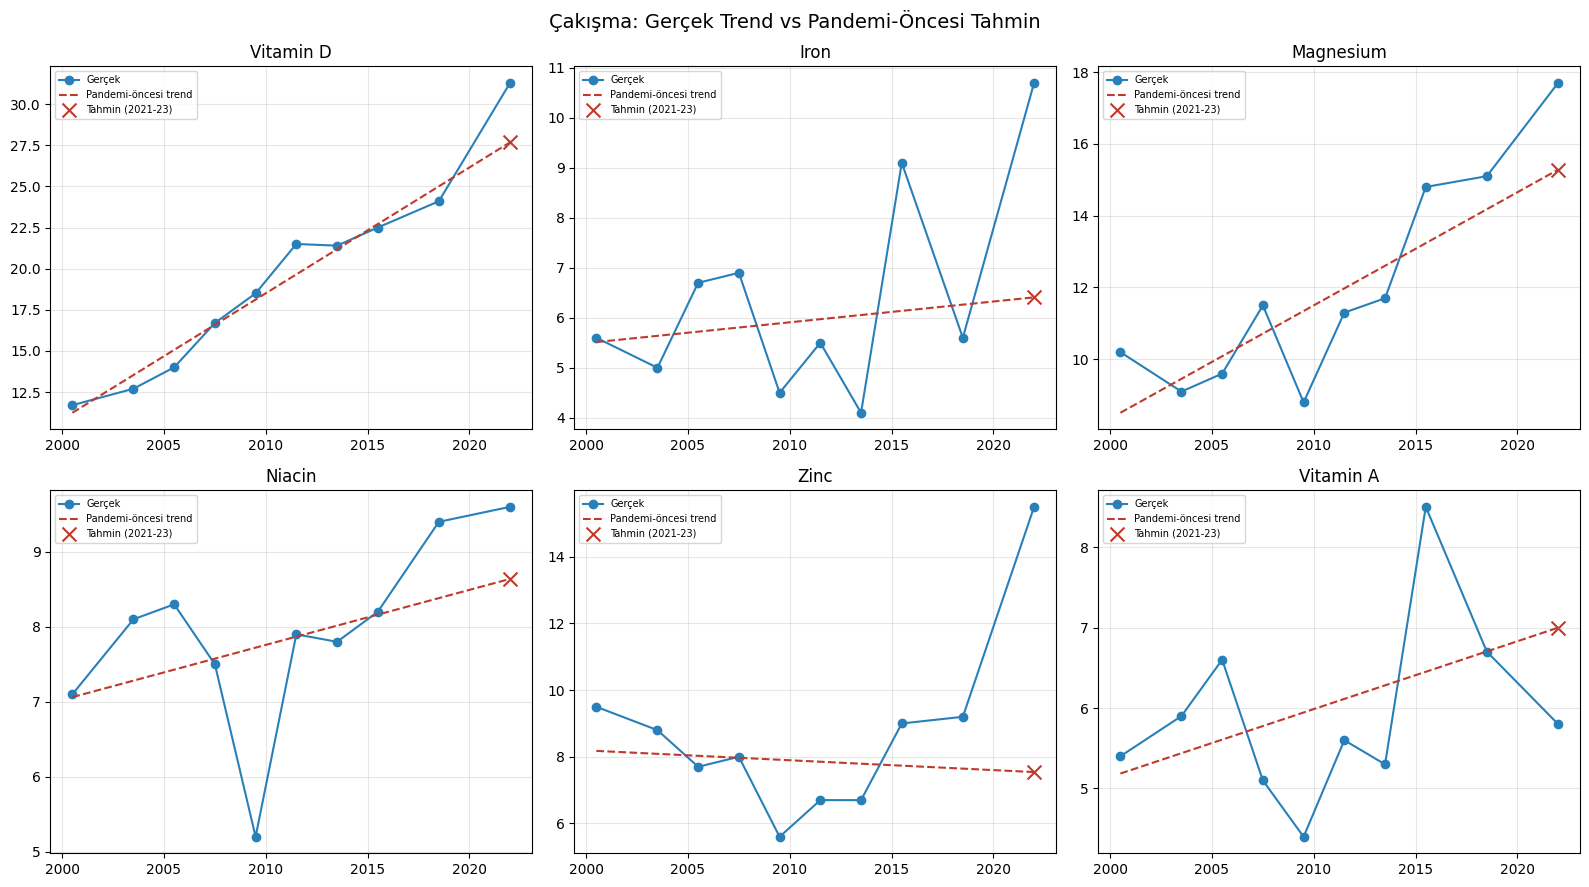

In [ ]:
# Counterfactual analysis for the six focus ingredients: overlap AND UL exceedance
# (pre-pandemic trend -> 2021-2023 prediction -> comparison with the observed value)

from google.cloud import bigquery
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

client = bigquery.Client(project='dose-of-reality-506713')

CYCLE_MIDPOINT = {
    '1999-2002': 2000.5, '2003-2004': 2003.5, '2005-2006': 2005.5,
    '2007-2008': 2007.5, '2009-2010': 2009.5, '2011-2012': 2011.5,
    '2013-2014': 2013.5, '2015-2016': 2015.5, '2017-2020': 2018.5,
    '2021-2023': 2022.0,
}
CYCLE_ORDER = list(CYCLE_MIDPOINT.keys())
INGREDIENTS = ['VITAMIN D', 'IRON', 'MAGNESIUM', 'NIACIN', 'ZINC', 'VITAMIN A']

def counterfactual(df, value_col, ingredient=None):
    d = df.copy()
    if ingredient:
        d = d[d['ingredient_name'] == ingredient]
    d['year'] = d['cycle'].map(CYCLE_MIDPOINT)
    d = d.dropna(subset=[value_col]).sort_values('year')
    pre = d[d['cycle'] != '2021-2023']
    if len(pre) < 3:
        return None
    coef = np.polyfit(pre['year'], pre[value_col], deg=1)
    predicted = np.polyval(coef, 2022.0)
    observed_row = d[d['cycle']=='2021-2023']
    if len(observed_row) == 0:
        return None
    observed = observed_row[value_col].values[0]
    return {'predicted': round(predicted, 1), 'observed': round(observed, 1), 'gap': round(observed - predicted, 1)}

# --- Overlap data ---
df_overlap = client.query(f"""
    SELECT cycle, ingredient_name, cakisma_yuzdesi_agirlikli AS overlap_pct
    FROM `dose-of-reality-506713.nhanes_dbt.mart_ingredient_overlap_trend_weighted`
    WHERE ingredient_name IN UNNEST({INGREDIENTS})
""").to_dataframe()

# --- UL exceedance data ---
df_ul = client.query(f"""
    SELECT cycle, ingredient_name, asim_yuzdesi_agirlikli AS exceedance_pct
    FROM `dose-of-reality-506713.nhanes_dbt.mart_ul_comparison_trend_weighted`
    WHERE ingredient_name IN UNNEST({INGREDIENTS})
""").to_dataframe()

print("=== COUNTERFACTUAL: INGREDIENT OVERLAP ===")
results_overlap = []
for ing in INGREDIENTS:
    r = counterfactual(df_overlap, 'overlap_pct', ing)
    if r:
        r['ingredient'] = ing
        results_overlap.append(r)
df_result_overlap = pd.DataFrame(results_overlap)[['ingredient', 'predicted', 'observed', 'gap']]
print(df_result_overlap.to_string(index=False))

print("\n=== COUNTERFACTUAL: UL EXCEEDANCE ===")
results_ul = []
for ing in INGREDIENTS:
    r = counterfactual(df_ul, 'exceedance_pct', ing)
    if r:
        r['ingredient'] = ing
        results_ul.append(r)
df_result_ul = pd.DataFrame(results_ul)[['ingredient', 'predicted', 'observed', 'gap']]
print(df_result_ul.to_string(index=False))

# --- Per ingredient: observed trend, fitted pre-pandemic line, predicted point ---
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for idx, ing in enumerate(INGREDIENTS):
    d = df_overlap[df_overlap['ingredient_name']==ing].copy()
    d['year'] = d['cycle'].map(CYCLE_MIDPOINT)
    d = d.dropna(subset=['overlap_pct']).sort_values('year')
    pre = d[d['cycle'] != '2021-2023']

    ax = axes[idx]
    ax.plot(d['year'], d['overlap_pct'], marker='o', label='Observed', color='#2980B9')

    if len(pre) >= 3:
        coef = np.polyfit(pre['year'], pre['overlap_pct'], deg=1)
        year_grid = np.linspace(pre['year'].min(), 2022, 50)
        ax.plot(year_grid, np.polyval(coef, year_grid), '--', color='#C0392B', label='Pre-pandemic trend')
        ax.scatter([2022], [np.polyval(coef, 2022)], color='#C0392B', marker='x', s=100, label='Predicted 2021-23')

    ax.set_title(ing.title())
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

fig.suptitle('Ingredient overlap: observed trend vs pre-pandemic prediction', fontsize=14)
plt.tight_layout()
plt.show()

### Results

**Overall usage**

| | Predicted (trend continues) | Actual | Gap |
|---|---|---|---|
| Usage rate | 55.2% | 34.3% | **−20.9 pts** |

Actual usage came in **38% below** the trend prediction — the largest single break in the dataset.

**Ingredient overlap**

| Ingredient | Predicted | Actual | Gap |
|---|---|---|---|
| **Zinc** | 7.5 | 15.5 | **+8.0** |
| Iron | 6.4 | 10.7 | +4.3 |
| Vitamin D | 27.7 | 31.3 | +3.6 |
| Magnesium | 15.3 | 17.7 | +2.4 |
| Niacin | 8.6 | 9.6 | +1.0 |
| Vitamin A | 7.0 | 5.8 | −1.2 |

Overlap ran **above** trend in five of six ingredients — the opposite direction to overall usage. Zinc
came in at nearly double its prediction. This is the "fewer users, heavier users" pattern from
[§14](#trend-usage), now quantified.

**UL exceedance**

| Ingredient | Predicted | Actual | Gap |
|---|---|---|---|
| **Vitamin D** | 21.3 | 27.5 | **+6.2** |
| Zinc | 3.9 | 9.4 | **+5.5** |
| Magnesium | 12.4 | 13.9 | +1.5 |
| Iron | 17.7 | 17.1 | −0.6 |
| **Niacin** | 16.1 | 11.7 | **−4.4** |
| Vitamin A | 2.4 | 1.9 | −0.5 |

### Synthesis

**Vitamin D and zinc are the pandemic pair.** Both run well above trend on *both* metrics, in the same
direction. Whatever happened in 2021–2023, these two absorbed most of it.

**Iron separates overlap from exceedance.** Multi-product iron use ran well above trend (+4.3) but
**exceedance did not follow** (−0.6, essentially exactly on trend). A plausible reading: the additional
products were lower-dose, so more stacking did not translate into more people crossing the limit. This
is a clean illustration that overlap and exceedance are genuinely different quantities.

**Niacin is the one large negative, and it is not a pandemic effect.** Exceedance came in 4.4 points
below prediction while overlap stayed on trend. This reflects niacin's own long-run decline, running
since 2013–2014 ([§16](#trend-ul)) and driven by falling single-product doses ([§17](#source)). A
straight line fitted over 1999–2020 cannot capture a mid-series bend, so it over-predicts the endpoint.
This should not be read as "the pandemic reduced niacin exceedance."

### Method limitation

The model is **ordinary least squares on nine points**. It flattens the genuine 1999–2010 wobble
([§15](#trend-overlap)) into a single slope, which costs accuracy for any ingredient with an internal
trend break — niacin most obviously. Predictions are also reported as point estimates without
prediction intervals, which would properly convey their uncertainty. A piecewise or segmented
regression, with intervals, is the natural improvement and is logged in [§27](#next).

<a id="part6"></a>
<a id="phases"></a>
# Part VI — Closing

## 25. How the scope evolved

The project was built in three deliberate passes rather than attempting all ten cycles at once. Each
pass validated the previous one's findings *and* produced results the previous one could not have.

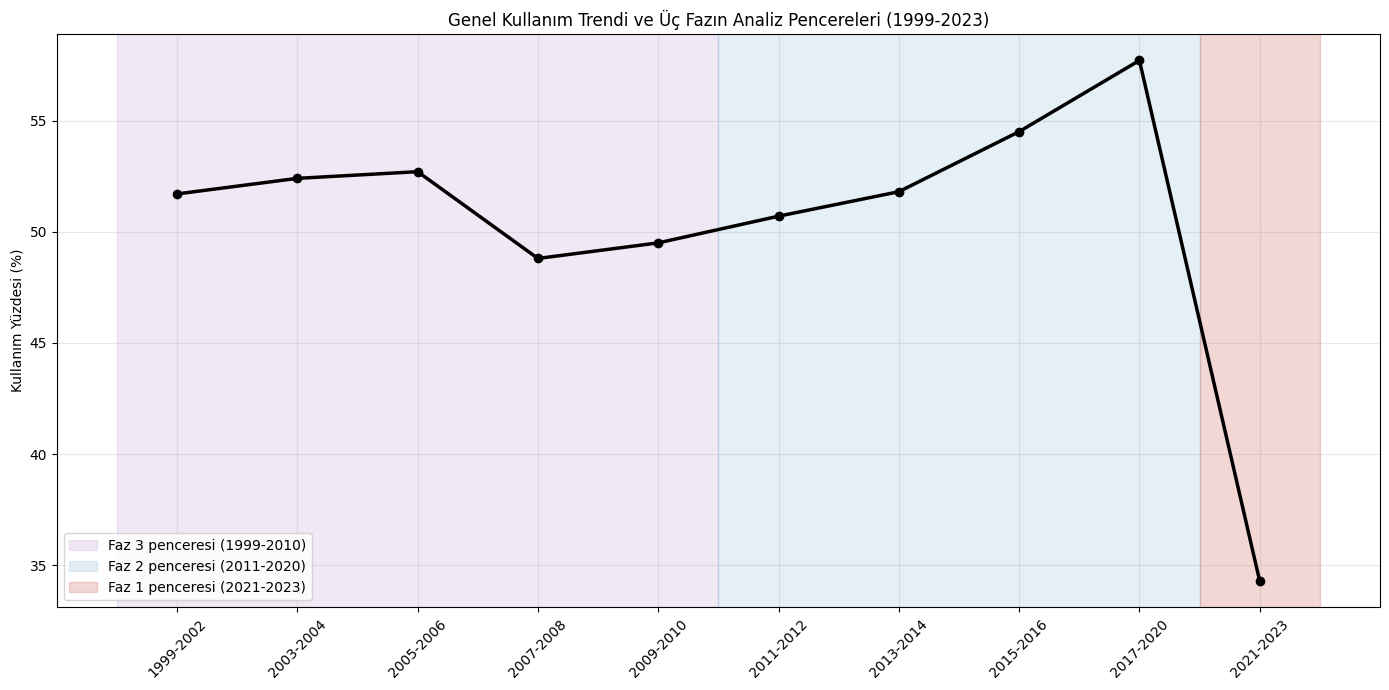

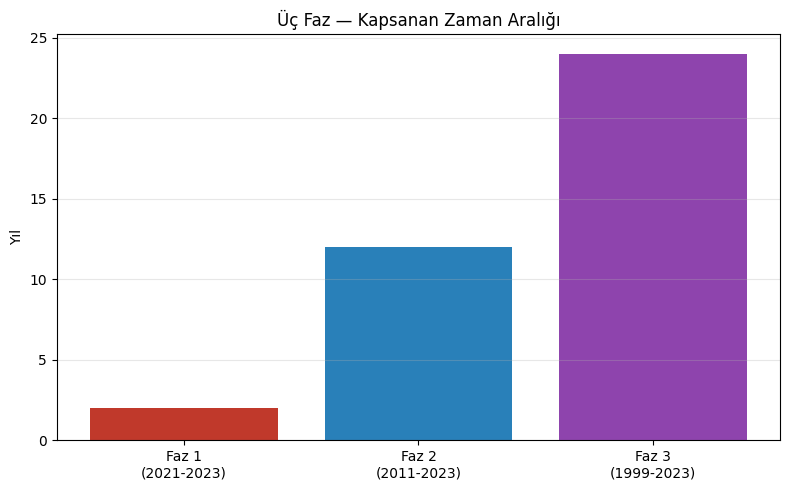

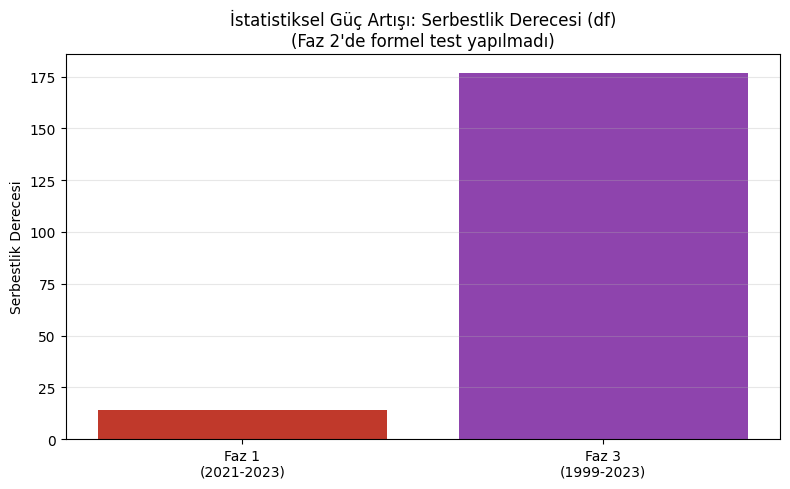

In [ ]:
# How the analysis window widened across three phases

from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

client = bigquery.Client(project='dose-of-reality-506713')
CYCLE_ORDER = ['1999-2002', '2003-2004', '2005-2006', '2007-2008', '2009-2010',
               '2011-2012', '2013-2014', '2015-2016', '2017-2020', '2021-2023']

# ============================================================
# CHART 1: usage trend with the three analysis windows shaded
# ============================================================
df = client.query("""
    SELECT cycle, kullanim_yuzdesi_agirlikli AS usage_pct
    FROM `dose-of-reality-506713.nhanes_dbt.mart_usage_trend_weighted`
""").to_dataframe()
df['cycle'] = pd.Categorical(df['cycle'], categories=CYCLE_ORDER, ordered=True)
df = df.sort_values('cycle').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 7))

# Shade each phase's analysis window
ax.axvspan(-0.5, 4.5, alpha=0.12, color='#8E44AD', label='Phase 3 window (1999-2010)')
ax.axvspan(4.5, 8.5, alpha=0.12, color='#2980B9', label='Phase 2 window (2011-2020)')
ax.axvspan(8.5, 9.5, alpha=0.20, color='#C0392B', label='Phase 1 window (2021-2023)')

ax.plot(df['cycle'], df['usage_pct'], marker='o', linewidth=2.5, color='black', zorder=5)

ax.set_title('Overall usage trend, with the three analysis windows')
ax.set_ylabel('Usage (%)')
ax.legend(loc='lower left')
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ============================================================
# CHART 2: years covered by each phase
# ============================================================
fig, ax = plt.subplots(figsize=(8, 5))
phases = ['Phase 1\n(2021-2023)', 'Phase 2\n(2011-2023)', 'Phase 3\n(1999-2023)']
years_covered = [2, 12, 24]
ax.bar(phases, years_covered, color=['#C0392B', '#2980B9', '#8E44AD'])
ax.set_title('Years of data covered, by phase')
ax.set_ylabel('Years')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# ============================================================
# CHART 3: gain in statistical power (degrees of freedom)
# ============================================================
fig, ax = plt.subplots(figsize=(8, 5))
phases_df = ['Phase 1\n(2021-2023)', 'Phase 3\n(1999-2023)']
df_values = [14, 177]
ax.bar(phases_df, df_values, color=['#C0392B', '#8E44AD'])
ax.set_title('Statistical power: degrees of freedom\n(no formal tests were run in Phase 2)')
ax.set_ylabel('Degrees of freedom')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### What each phase added

| | Phase 1 | Phase 2 | Phase 3 |
|---|---|---|---|
| **Coverage** | 2021–2023 (1 cycle) | 2011–2023 (5 cycles, 12 yrs) | 1999–2023 (10 blocks, 24 yrs) |
| **Sample** | 3,835 people | ~40,000 | 46,388 person-cycles |
| **Statistical df** | 14 | — | **177** |
| **Main contribution** | Method established | Trends + weighting discipline | Full history + counterfactual |

**Phase 1 → Phase 2**

*Confirmed:* the six-ingredient scope (2% threshold); the headline overlap (40.7% → 39.8% weighted) and
exceedance (34.2% → 33.3%) figures.

*New, and impossible to learn from one cycle:*
- The **product-ID discontinuity** (`DSDSUPID` vs `DSDPID`), and its resolution via the `DSPI` crosswalk (97% match).
- The **NHANES weighting requirement** — which turned out to matter enormously for prevalence metrics (25–29 point differences) and barely at all for conditional ones.
- The **2021–2023 break** itself: usage collapsing while multi-product use jumped.

**Phase 2 → Phase 3**

*Confirmed:* the six-ingredient scope across all 24 years (plus the discovery that niacin dominated the
pre-2011 period); all three demographic effects, at far higher statistical power; correct integration of
the 1999–2002 `WTINT4YR` block.

*New, and visible only in a 24-year window:*
- The **counterfactual estimate** of the pandemic break (predicted 55.2%, actual 34.3%, −20.9 points).
- **Vitamin D and zinc have different mechanisms** — an acceleration from a 1999–2006 baseline of zero versus a flat line that jumps only in the final cycle.
- **Niacin and vitamin A's independent long-run decline**, predating the pandemic by two decades and traceable to single-product dose.
- The **2009–2010 trough / 2015–2016 peak** shared across four ingredients, verified not to be a data artefact.
- **Race/ethnicity is a dynamic factor**, not a static one — the Non-Hispanic Black / Non-Hispanic White exceedance ordering reversed within the window.
- The **sex gap in exceedance opening after 2017**, traced to the overlap component.
- A **new statistical question** (is 64.2% different from 50%?) that neither earlier phase had thought to ask.

### Why incremental was the right call

Each expansion returned more than confirmation. Phase 2 surfaced a methodological requirement — survey
weighting — that a single cycle could not have revealed. Phase 3 surfaced mechanisms that no shorter
window contains. Had the project stopped at one cycle, neither the size of the pandemic effect nor the
fact that vitamin D and zinc tell entirely different stories would exist in it at all.

<a id="limitations"></a>
## 26. Limitations

Stated plainly, roughly in order of how much they constrain the conclusions.

**1 — ULs are applied at adult values to all ages.** The reference table covers ages 19–70. Children,
adolescents and adults 71+ have different, generally lower ULs. Exceedance for the **0–17 group is
therefore understated**, and every age-stratified result should be read with that in mind. This is the
single highest-value fix available.

**2 — One serving per day is assumed.** `DSII.quantity` is a per-serving label amount; the analysis
compares the sum of per-serving amounts against a daily UL. Anyone taking more than one serving of a
product per day has their intake understated. NHANES records use frequency, but not consistently enough
across ten cycles to build a comparable daily-dose estimate.

**3 — The 2021–2023 break cannot be decomposed.** The supplement questionnaire moved to telephone
administration that cycle. How much of the break is survey-mode artefact and how much is real behaviour
change is **not separable with this data**. The counterfactual in [§24](#counterfactual) measures the
total break; it does not attribute it.

**4 — Non-Hispanic Asian respondents are not separately visible.** `RIDRETH3` breaks them out but only
exists from 2011; `RIDRETH1`, used for cross-cycle comparability, folds them into "Other Race." A
single-cycle analysis could report on this group; the 24-year analysis cannot.

**5 — Botanicals and amino acids are out of scope.** No standardised, population-applicable UL system
exists for them. This is a documented exclusion, not a gap — but it does mean that ~18,000 ingredient
rows carry no safety assessment here at all.

**6 — Ingredients with "ND" ULs cannot be assessed.** Vitamin B-12, biotin, thiamin, riboflavin,
pantothenic acid and the carotenoids are among the most frequently *overlapped* ingredients, and none
of them can appear in the exceedance analysis, because the reference authority has not set a ceiling.
Overlap is measured for them; exceedance is undefined.

**7 — Blend sub-components (`DSBI`) are not decomposed.** Where a product declares a proprietary blend,
`DSII` records the blend and `DSBI` holds its components. This analysis uses `DSII` only, so ingredient
amounts inside blends are not attributed. Direction of the resulting bias is toward *understating*
intake.

**8 — Unconvertible units are excluded from totals.** Amounts labelled in `% DV`, kcal, mL, DU, HUT or
LU cannot be converted to mass and are held out of the sum. The count is reported per person-ingredient
(`n_unconvertible_rows`) so the coverage is visible, but excluded rows still mean some intake is
uncounted.

**9 — Product-ID match rates are 92–98%, not 100%.** A small share of reported products cannot be
matched to the reference database in any cycle, and their ingredients are absent from the analysis.

**10 — Statistical caveats.** Seven tests are reported without multiple-comparison correction (six at
p < 0.0001, so conclusions are unaffected). The design-based Kruskal-Wallis is applied to binary
outcomes, where a Rao-Scott chi-square would be the more conventional choice. Counterfactual
predictions are point estimates without prediction intervals.

**11 — This is descriptive, not causal.** Every mechanism suggested here — pandemic behaviour, product
reformulation, awareness waves, perimenopause — is a hypothesis consistent with the timing. None is
tested, and none is claimed.

<a id="next"></a>
## 27. What I would do next

Ordered by value relative to effort.

**1 — Age-specific UL table.** Extend `stg_ul_reference` from one adult row per ingredient to
`(ingredient, age_band)`, and join on age band rather than ingredient alone. This directly fixes
limitation 1 and would materially change the 0–17 results. Highest-value change available.

**2 — Rerun the failed hypothesis with pooled cycles.** The Non-Hispanic Black / female / 35–49 iron
test failed on n = 15 ([§23](#failed-test)). Pooling several cycles would grow that subgroup enough to
give the hypothesis a fair test — the analysis already has the pooled-weight machinery to do it
correctly.

**3 — Segmented regression for the counterfactual.** Replace OLS-on-nine-points with a piecewise model
that can accommodate the 2013–2014 niacin bend, and report prediction intervals rather than point
estimates.

**4 — Decompose blends via `DSBI`.** The table is already staged as `stg_dsbi` and unused. Attributing
blend sub-components would tighten intake estimates and quantify how much limitation 7 costs.

**5 — dbt tests and documentation.** The pipeline has no `schema.yml`. Adding `unique` /
`not_null` / `accepted_values` tests and column descriptions would catch a repeat of the duplication
bug automatically instead of relying on someone noticing an implausible result.

**6 — Rao-Scott chi-square for binary outcomes**, alongside the current rank tests, for methodological
convention.

**7 — Sensitivity analysis on the mode change.** Rerun the key trends excluding 2021–2023 entirely, and
report how much of each conclusion depends on the one cycle whose comparability is uncertain.

---

## Closing

The project started from a personal question — *if I take several supplements, am I doubling up on
anything?* — and it turned out to be answerable at national scale from public data.

The answer is yes, for about **four in ten** supplement users, and for about **one in three** it pushes
past a documented safety ceiling. But the more useful finding is the one that only appeared after
splitting exceedance by its source: **vitamin D risk comes from stacking products, iron risk comes from
a single label.** Advice that addresses only the first would miss the second entirely.

---

**Data:** [NHANES, CDC](https://wwwn.cdc.gov/nchs/nhanes/) · **ULs:** IOM/NAS Dietary Reference Intakes
([2000](https://www.ncbi.nlm.nih.gov/books/NBK222881/), [2003](https://www.ncbi.nlm.nih.gov/books/NBK208874/))
**Code:** [github.com/didemmrsln/dose-of-reality](https://github.com/didemmrsln/dose-of-reality)

*Not medical advice. Descriptive population-level analysis of public survey data.*